In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:

x_num = pd.read_csv('/kaggle/input/work-package-2/x_flattened.csv')
x_num = x_num['meter']
y_num = pd.read_csv('/kaggle/input/work-package-2/y_flattened.csv',index_col = 'Unnamed: 0')
x_num = np.array(x_num)
y_num = np.array(y_num)
x_train = x_num[:2*-8760].reshape(4015,24,1)
y_train = y_num[:2*-8760].reshape(4015,24,2)
x_val = x_num[2*-8760:-8760].reshape(365,24,1)
y_val = y_num[2*-8760:-8760].reshape(365,24,2)
x_test = x_num[-8760:].reshape(365,24,1)
y_test = y_num[-8760:].reshape(365,24,2)

In [39]:
# --- Import libraries ---
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Bidirectional

# --- Build BiLSTM model ---
def build_bilstm_model(input_shape=(24,1)):
    inputs = Input(shape=input_shape)
    x = Bidirectional(LSTM(64, return_sequences=True))(inputs)
    x = Bidirectional(LSTM(32))(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(2, activation='linear')(x)
    return Model(inputs, outputs)

model_bilstm = build_bilstm_model(input_shape=(24, 1))
model_bilstm.compile(optimizer='adam', loss='mse', metrics=['mae'])

# --- Force build if needed (only if model was not trained yet) ---
model_bilstm.build(input_shape=(None, 24, 1))

# --- Predictions ---
# Assuming you already have gbrt, model_cnn_bilstm, model_bilstm_att trained
pred_gbrt = gbrt.predict(x_test.reshape(365, 24)) 
pred_gbrt = pred_gbrt.reshape((-1, 24, 2))





# --- Metrics functions ---
def mean_absolute_error(y_true, y_pred):
    y_true = np.ravel(y_true)
    y_pred = np.ravel(y_pred)
    return np.mean(np.abs(y_true - y_pred))

def relative_error_total(y_true, y_pred):
    y_true = np.ravel(y_true)
    y_pred = np.ravel(y_pred)
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

def r_squared(y_true, y_pred):
    y_true = np.ravel(y_true)
    y_pred = np.ravel(y_pred)
    ss_total = np.sum((y_true - np.mean(y_true)) ** 2)
    ss_residual = np.sum((y_true - y_pred) ** 2)
    return 1 - (ss_residual / ss_total)

# --- Evaluate all models ---
models_predictions = {
    "GBRT": pred_gbrt,
    "CNN-BiLSTM": pred_cnn_bilstm,
    
    "BiLSTM+Attention": pred_bilstm_att
}

results = []

for model_name, pred in models_predictions.items():
    mae = mean_absolute_error(y_test, pred)
    ret = relative_error_total(y_test, pred)
    r2 = r_squared(y_test, pred)
    results.append([model_name, mae, ret, r2])

# --- Results table ---
results_df = pd.DataFrame(results, columns=["Model", "MAE (Wh)", "RET", "R²"])
print(results_df)


              Model    MAE (Wh)       RET        R²
0              GBRT   79.159030  0.037554  0.986518
1        CNN-BiLSTM  210.681120  0.099950  0.972953
2  BiLSTM+Attention  123.861116  0.058761  0.991982


In [41]:
import numpy as np
import matplotlib.pyplot as plt
import calendar

# Your predictions (all shaped: [365, 24, 2])
models = {
    "GBRT": pred_gbrt,
    "CNN_BiLSTM": pred_cnn_bilstm,
    "BiLSTM_Attention": pred_bilstm_att,
    
}

# Ground truth
y_true = y_test  # shape: (365, 24, 2)

# Month indexing helper (non-leap year)
days_in_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
month_indices = np.repeat(np.arange(12), days_in_month)

# R² function
def r_squared(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    ss_total = np.sum((y_true - np.mean(y_true)) ** 2)
    ss_res = np.sum((y_true - y_pred) ** 2)
    return 1 - (ss_res / ss_total) if ss_total != 0 else 0.0

# Dictionaries to store results
monthly_mae = {name: [] for name in models}
monthly_r2 = {name: [] for name in models}

# Calculate monthly MAE and R²
for month in range(12):
    mask = month_indices == month
    y_m = y_true[mask]  # shape: (days_in_month, 24, 2)
    for name, pred in models.items():
        p_m = pred[mask]
        y_flat = y_m.reshape(-1)
        p_flat = p_m.reshape(-1)
        monthly_mae[name].append(np.mean(np.abs(y_flat - p_flat)))
        monthly_r2[name].append(r_squared(y_flat, p_flat))

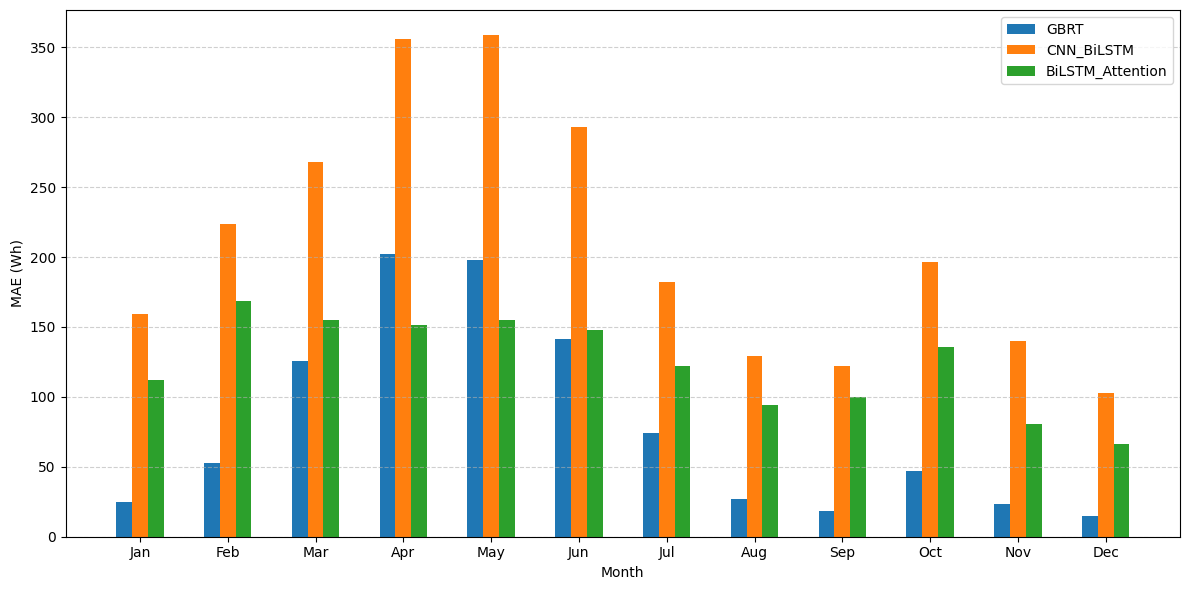

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import calendar

labels = [calendar.month_abbr[i + 1] for i in range(12)]
x = np.arange(len(labels))
width = 0.18
models = list(monthly_mae.keys())

# Create single plot for MAE
fig, ax = plt.subplots(figsize=(12, 6))

# --- Plot MAE ---
for i, model in enumerate(models):
    ax.bar(x + i * width, monthly_mae[model], width, label=model)

ax.set_ylabel('MAE (Wh)')
ax.set_xlabel('Month')
ax.set_xticks(x + width * (len(models)-1)/2)
ax.set_xticklabels(labels)
ax.grid(True, axis='y', linestyle='--', alpha=0.6)

# --- Legend inside the plot (top-right corner) ---
ax.legend(loc='upper right', frameon=True)

# Adjust layout and save
plt.tight_layout()
plt.savefig('compar1.pdf')



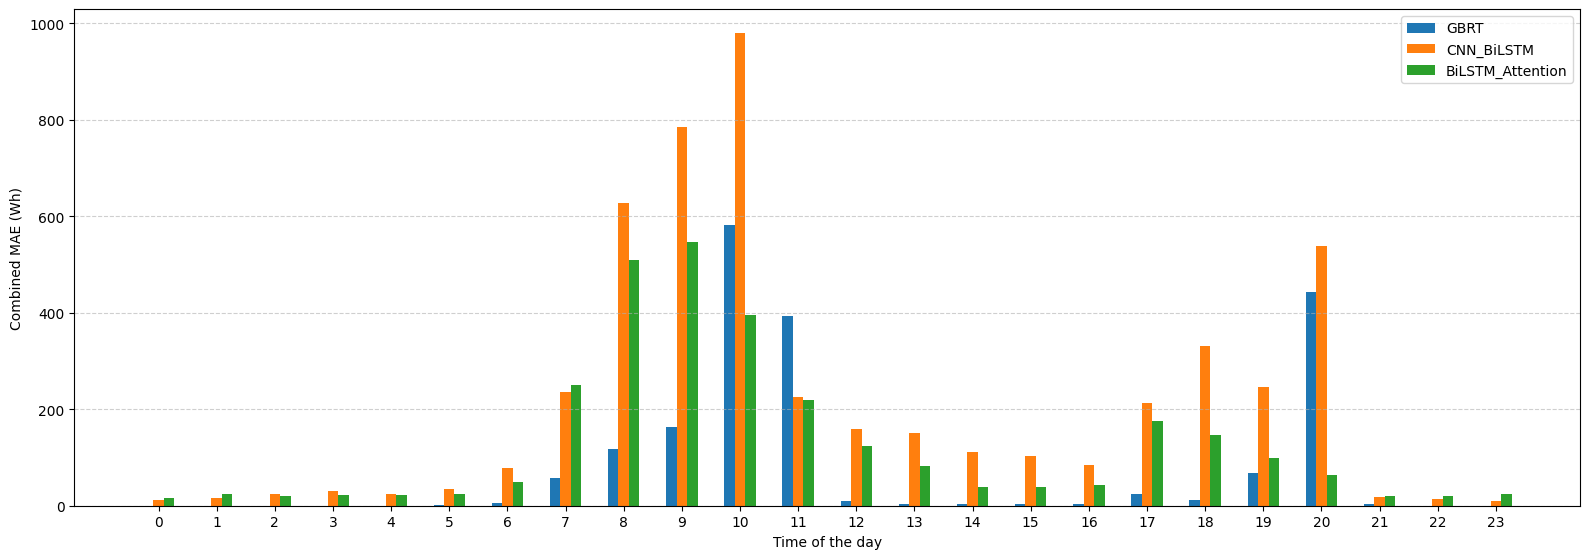

In [46]:
# Make sure predictions are all shaped: (365, 24, 2)
def ensure_3d(pred):
    if pred.ndim == 2 and pred.shape[1] == 48:
        return pred.reshape((-1, 24, 2))
    return pred

# Reshape if needed
pred_gbrt = ensure_3d(pred_gbrt)


# Store model predictions
models = {
    "GBRT": pred_gbrt,
    "CNN_BiLSTM": pred_cnn_bilstm,
    "BiLSTM_Attention": pred_bilstm_att,
    
}

# Initialize results
hourly_mae_combined = {name: [] for name in models}

# Compute combined MAE for each hour
for hour in range(24):
    y_h = y_test[:, hour, :]  # (365, 2)
    for name, pred in models.items():
        p_h = pred[:, hour, :]  # (365, 2)
        error = np.abs(y_h - p_h)
        mae = np.mean(error)  # average over 365 * 2
        hourly_mae_combined[name].append(mae)
import matplotlib.pyplot as plt
import numpy as np

labels = [str(h) for h in range(24)]  # Hours 0 to 23
x = np.arange(len(labels))
width = 0.18
model_names = list(hourly_mae_combined.keys())

fig, ax = plt.subplots(figsize=(16, 6))

# Plot each model's bars
for i, model in enumerate(model_names):
    ax.bar(x + i * width, hourly_mae_combined[model], width, label=model)

# Formatting
ax.set_ylabel('Combined MAE (Wh)')
ax.set_xlabel('Time of the day')

ax.set_xticks(x + width * (len(model_names) - 1) / 2)
ax.set_xticklabels(labels)
ax.grid(True, axis='y', linestyle='--', alpha=0.6)
ax.legend(loc='upper right', frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('hourly1.pdf')


# BILSTM_CNN

In [29]:
pred_cnn_bilstm = model_cnn_bilstm.predict(x_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step


In [38]:
pred_cnn_bilstm.shape

(365, 24, 2)

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, Bidirectional, LSTM, Dense, Dropout, LayerNormalization

# Build CNN + BiLSTM model
def build_cnn_bilstm_model(input_shape=(24, 1)):
    inputs = Input(shape=input_shape)

    # CNN block
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(x)

    # BiLSTM block
    x = Bidirectional(LSTM(64, return_sequences=True))(x)

    x = LayerNormalization()(x)

    # Dense layers
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(2, activation='linear')(x)  # Predict Grid Import and PV Generation

    model = Model(inputs, outputs)
    return model

# Instantiate and compile
model_cnn_bilstm = build_cnn_bilstm_model()
model_cnn_bilstm.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Model Summary
model_cnn_bilstm.summary()

# Example Callbacks
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)

# Example Training
history = model_cnn_bilstm.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=60,
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 24, 1)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ (None, 24, 64)              │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 24, 64)              │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 24, 128)             │          66,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer_normalization                  │ (None, 24, 128)             │             256 │
│ (LayerNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 24, 128)             │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 24, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 24, 2)               │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 95,682 (373.76 KB)

 Trainable params: 95,682 (373.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - loss: 5833969.5000 - mae: 1559.0475 - val_loss: 9874651.0000 - val_mae: 1909.4600 - learning_rate: 0.0010
Epoch 2/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 4619725.5000 - mae: 1385.4353 - val_loss: 6384458.5000 - val_mae: 1415.5939 - learning_rate: 0.0010
Epoch 3/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 2264453.7500 - mae: 863.8467 - val_loss: 3439611.0000 - val_mae: 792.0772 - learning_rate: 0.0010
Epoch 4/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 976717.7500 - mae: 454.8507 - val_loss: 2135677.2500 - val_mae: 597.3951 - learning_rate: 0.0010
Epoch 5/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 528565.0625 - mae: 334.2671 - val_loss: 1322948.8750 - val_mae: 453.6772 - learning_rate: 0.0010
Epoch 6/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 316196.1562 - mae: 271.1003 - val_loss: 1042644.8750 - val_mae: 436.5492 - learning_rate: 0.0010
Epoch 7/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 23

In [6]:
pred_cnn_bilstm = model_cnn_bilstm.predict(x_test)

def mean_absolute_error(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.mean(np.abs(y_test - pred))

def relative_error_total(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.sum(np.abs(y_test - pred)) / np.sum(np.abs(y_test))

def r_squared(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
    ss_residual = np.sum((y_test - pred) ** 2)
    return 1 - (ss_residual / ss_total)
mae = mean_absolute_error(y_test, pred_cnn_bilstm)
ret = relative_error_total(y_test, pred_cnn_bilstm)
r2 = r_squared(y_test, pred_cnn_bilstm)

print(f"MAE: {mae:.2f} Wh")
print(f"Relative Error in Total: {ret:.4f}")
print(f"R²: {r2:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
MAE: 222.83 Wh
Relative Error in Total: 0.1057
R²: 0.9746


# BILSTM

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Bidirectional

# Build the BiLSTM model
def build_bilstm_model(input_shape=(24, 1)):
    inputs = Input(shape=input_shape)

    # --- BiLSTM Layer ---
    x = Bidirectional(LSTM(64, return_sequences=True))(inputs)
    x = Dropout(0.2)(x)

    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    x = Dropout(0.2)(x)

    # --- Fully Connected Layers ---
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(2, activation='linear')(x)  # Predict (PV, Grid)

    return Model(inputs, outputs)

# Create and compile the model
model_bilstm = build_bilstm_model()
model_bilstm.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Show the model architecture
model_bilstm.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 24, 1)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 24, 128)             │          33,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 24, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 24, 128)             │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 24, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 24, 128)             │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 24, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 24, 2)               │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 149,378 (583.51 KB)

 Trainable params: 149,378 (583.51 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
pred_bilstm1 = model_bilstm.predict(x_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [37]:
y_test.shape

(365, 24, 2)

In [6]:
history_bilstm = model_bilstm.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=60, batch_size=32)

Epoch 1/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - loss: 5853441.5000 - mae: 1559.9087 - val_loss: 9844356.0000 - val_mae: 1925.7922
Epoch 2/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 4715804.0000 - mae: 1421.2325 - val_loss: 7285826.5000 - val_mae: 1544.5745
Epoch 3/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 2972986.5000 - mae: 1022.6808 - val_loss: 4829737.5000 - val_mae: 1049.8934
Epoch 4/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 1586063.1250 - mae: 609.7790 - val_loss: 3501753.7500 - val_mae: 781.1000
Epoch 5/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 1046019.0000 - mae: 452.4830 - val_loss: 2514540.2500 - val_mae: 584.2492
Epoch 6/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 682742.1250 - mae: 350.1409 - val_loss: 1770769.0000 - val_mae: 472.2349
Epoch 7/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 445775.8125 - mae: 294.0067 - val_loss: 1258876.8750 - val_mae: 398.6802
Epoch 8/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/st

# BILSTM Attention

In [24]:
pred_bilstm_att = model_bilstm_att.predict(x_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


In [23]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, Dropout, Attention, LayerNormalization, Multiply
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Build BiLSTM + Attention model
def build_bilstm_attention_model(input_shape=(24, 1)):
    inputs = Input(shape=input_shape)

    # BiLSTM layer
    x = Bidirectional(LSTM(64, return_sequences=True))(inputs)

    # Simple Attention
    attention = Attention()([x, x])
    x = Multiply()([x, attention])  # Combine attention output

    x = LayerNormalization()(x)

    # Dense layers after attention
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(2, activation='linear')(x)  # Predict Grid Import and PV Generation

    model = Model(inputs, outputs)
    return model

# Instantiate and compile
model_bilstm_att = build_bilstm_attention_model()
model_bilstm_att.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)

# Model Summary
model_bilstm_att.summary()

# Now fitting the model
history = model_bilstm_att.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=60,
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8             │ (None, 24, 1)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional_11          │ (None, 24, 128)        │         33,792 │ input_layer_8[0][0]    │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attention_4 (Attention)   │ (None, 24, 128)        │              0 │ bidirectional_11[0][0… │
│                           │                        │                │ bidirectional_11[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply_2 (Multiply)     │ (None, 24, 128)        │              0 │ bidirectional_11[0][0… │
│                           │                        │                │ attention_4[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_5     │ (None, 24, 128)        │            256 │ multiply_2[0][0]       │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_16 (Dense)          │ (None, 24, 128)        │         16,512 │ layer_normalization_5… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_12 (Dropout)      │ (None, 24, 128)        │              0 │ dense_16[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_17 (Dense)          │ (None, 24, 2)          │            258 │ dropout_12[0][0]       │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 50,818 (198.51 KB)

 Trainable params: 50,818 (198.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - loss: 5779076.5000 - mae: 1549.7283 - val_loss: 9646944.0000 - val_mae: 1867.2178 - learning_rate: 0.0010
Epoch 2/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 4447293.5000 - mae: 1323.9265 - val_loss: 5890725.0000 - val_mae: 1283.6355 - learning_rate: 0.0010
Epoch 3/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 1968102.3750 - mae: 757.6251 - val_loss: 3373534.2500 - val_mae: 798.8713 - learning_rate: 0.0010
Epoch 4/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 1004913.2500 - mae: 464.9686 - val_loss: 2036074.7500 - val_mae: 550.4179 - learning_rate: 0.0010
Epoch 5/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 541782.3750 - mae: 327.3322 - val_loss: 1601178.1250 - val_mae: 513.1604 - learning_rate: 0.0010
Epoch 6/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 397626.0000 - mae: 299.6179 - val_loss: 1127120.8750 - val_mae: 461.9966 - learning_rate: 0.0010
Epoch 7/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 2

In [5]:
pred_hybrid = model.predict(x_test)

def mean_absolute_error(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.mean(np.abs(y_test - pred))

def relative_error_total(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.sum(np.abs(y_test - pred)) / np.sum(np.abs(y_test))

def r_squared(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
    ss_residual = np.sum((y_test - pred) ** 2)
    return 1 - (ss_residual / ss_total)
mae = mean_absolute_error(y_test, pred_hybrid)
ret = relative_error_total(y_test, pred_hybrid)
r2 = r_squared(y_test, pred_hybrid)

print(f"MAE: {mae:.2f} Wh")
print(f"Relative Error in Total: {ret:.4f}")
print(f"R²: {r2:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
MAE: 161.78 Wh
Relative Error in Total: 0.0768
R²: 0.9865


In [4]:
history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=50, batch_size=32)

Epoch 1/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 5885297.0000 - mae: 1561.0192 - val_loss: 11182354.0000 - val_mae: 2034.8608
Epoch 2/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 5117549.0000 - mae: 1451.3607 - val_loss: 8478923.0000 - val_mae: 1704.9551
Epoch 3/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 3131555.7500 - mae: 1071.4042 - val_loss: 4933126.0000 - val_mae: 1075.6128
Epoch 4/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 1386358.8750 - mae: 571.7374 - val_loss: 2957276.0000 - val_mae: 732.6728
Epoch 5/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 684666.7500 - mae: 375.9371 - val_loss: 1742699.5000 - val_mae: 515.2565
Epoch 6/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 332948.4688 - mae: 245.2639 - val_loss: 1037595.4375 - val_mae: 369.9136
Epoch 7/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 302728.5312 - mae: 293.9215 - val_loss: 712635.3750 - val_mae: 323.2411
Epoch 8/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step

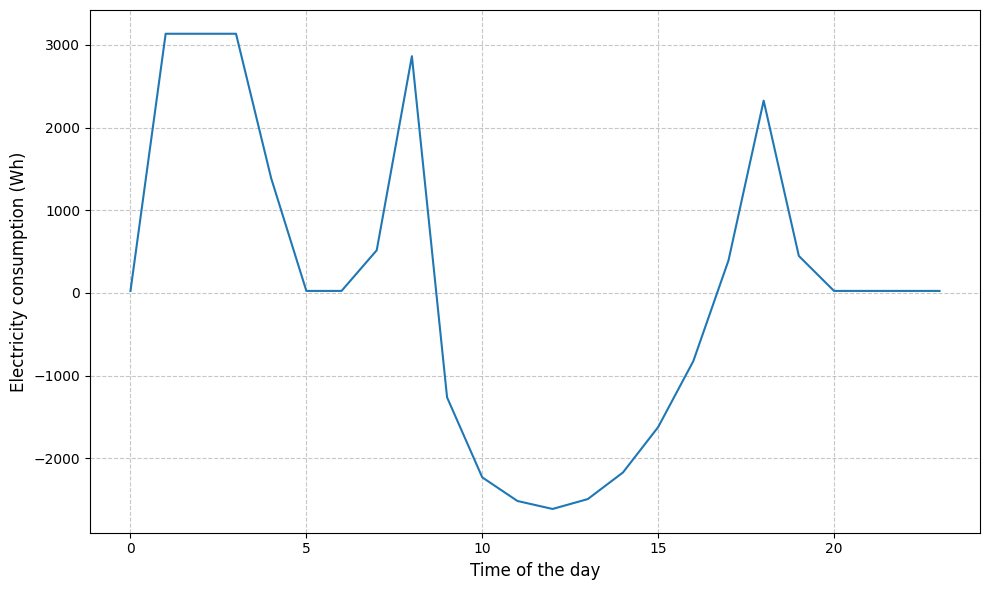

In [8]:
import matplotlib.pyplot as plt

# Example: Plotting the second sample from the training dataset
sample_index = 1
plt.figure(figsize=(10, 6))
plt.plot(x_train[sample_index, :, :], linewidth=1.5)

plt.xlabel("Time of the day", fontsize=12)
plt.ylabel("Electricity consumption (Wh)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('Input_sample.pdf')



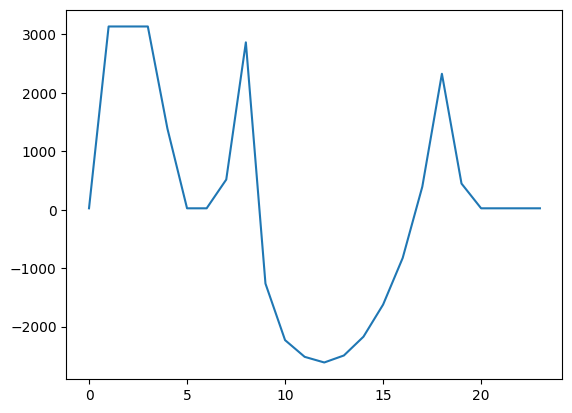

In [6]:
import matplotlib.pyplot as plt
plt.plot(x_train[1,:,:])

In [13]:
import numpy as np
import calendar

# Helper to get days per month for non-leap year
days_in_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
month_indices = np.repeat(np.arange(12), days_in_month)  # array of month index (0–11) for each day

def evaluate_by_month(y_true, y_pred):
    print("\nMonthly Evaluation:")
    for month in range(12):
        mask = month_indices == month
        y_m = y_true[mask, :, 1]
        p_m = y_pred[mask, :, 1]

        mae = np.mean(np.abs(y_m - p_m))
        ret = np.sum(np.abs(y_m - p_m)) / np.sum(y_m)
        r2 = r_squared(y_m, p_m)

        print(f"{calendar.month_name[month + 1]} - MAE: {mae:.2f} Wh | RET: {ret:.4f} | R²: {r2:.4f}")


In [14]:
evaluate_by_month(pred , y_test)


Monthly Evaluation:
January - MAE: 36.50 Wh | RET: 0.0177 | R²: 0.9998
February - MAE: 113.17 Wh | RET: 0.0422 | R²: 0.9981
March - MAE: 357.99 Wh | RET: 0.1231 | R²: 0.9868
April - MAE: 431.29 Wh | RET: 0.1512 | R²: 0.9820
May - MAE: 452.03 Wh | RET: 0.1621 | R²: 0.9780
June - MAE: 322.27 Wh | RET: 0.1202 | R²: 0.9879
July - MAE: 179.35 Wh | RET: 0.0684 | R²: 0.9967
August - MAE: 114.98 Wh | RET: 0.0457 | R²: 0.9983
September - MAE: 42.92 Wh | RET: 0.0179 | R²: 0.9998
October - MAE: 38.27 Wh | RET: 0.0170 | R²: 0.9998
November - MAE: 33.33 Wh | RET: 0.0177 | R²: 0.9999
December - MAE: 28.23 Wh | RET: 0.0173 | R²: 0.9999


In [17]:
def evaluate_by_hour(y_true, y_pred):
    print("\nHourly Evaluation (across 365 days):")
    for hour in range(24):
        # Extract values at the same hour across all days (for network component: index 1)
        y_h = y_true[:, hour, 1]
        p_h = y_pred[:, hour, 1]

        mae = np.mean(np.abs(y_h - p_h))
        ret = np.sum(np.abs(y_h - p_h)) / np.sum(y_h)
        r2 = r_squared(y_h, p_h)

        print(f"Hour {hour:02d}: MAE = {mae:.2f} Wh | RET = {ret:.4f} | R² = {r2:.4f}")



In [28]:
# Absolute differences for the network (grid) values
abs_diff = np.abs(y_test[:, :, 1] - pred[:, :, 1])  # shape: (365, 24)

# Optional: summary
mean_diff = np.mean(abs_diff)
max_diff = np.max(abs_diff)
for i in range(0,24):
    hour_0 = abs_diff[:,i]
    me = np.mean(hour_0)
    print(me)

107.74168079734277
241.04865947705446
171.7295616096142
139.0991421375404
195.68205849716355
109.1133788492093
149.35285276772646
236.33917138707267
234.94731671324715
281.3639671849206
477.8862771398214
361.4374534444098
138.16491732585962
132.1984307941505
117.096338454124
49.83928551534052
65.71289161585933
227.3878781412409
96.99815100064122
218.88442651784138
355.01298778055207
86.93883767257049
43.21933205569068
69.0506514095777


In [25]:
abs_diff[:,0]

(365,)

In [9]:
import numpy as np
import optuna
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, Reshape, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

# Assume x_train, y_train, x_test, y_test are already defined:
# x_train shape: (n_samples, 24, 1)
# y_train shape: (n_samples, 48)

# Reshape y to (n_samples, 24, 2)
y_train = y_train.reshape((-1, 24, 2))
y_test = y_test.reshape((-1, 24, 2))

def create_model(trial):
    # Hyperparameter suggestions
    num_filters = trial.suggest_categorical('num_filters', [32, 64, 128])
    kernel_size = trial.suggest_int('kernel_size', 2, 5)
    dense_units_1 = trial.suggest_int('dense_units_1', 64, 256)
    dense_units_2 = trial.suggest_int('dense_units_2', 32, 128)
    dropout_rate = trial.suggest_float('dropout_rate', 0.0, 0.4)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)

    # Model architecture
    model = Sequential()
    model.add(Input(shape=(24, 1)))
    model.add(Conv1D(num_filters, kernel_size=kernel_size, activation='relu'))
    model.add(Flatten())
    model.add(Dense(dense_units_1, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(dense_units_2, activation='relu'))
    model.add(Dense(24 * 2, activation='linear'))  # 48 output units
    model.add(Reshape((24, 2)))  # Reshape back to (24, 2)

    # Compile model
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse', metrics=['mae'])
    return model

def objective(trial):
    # Split training into train/validation sets
    x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

    model = create_model(trial)

    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)

    # Train model
    model.fit(
        x_tr, y_tr,
        validation_data=(x_val, y_val),
        epochs=50,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    # Evaluate on validation set
    val_loss, _ = model.evaluate(x_val, y_val, verbose=0)
    return val_loss

# Run Optuna study
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler())
study.optimize(objective, n_trials=30)

# Best trial
print("Best Trial:")
for key, value in study.best_trial.params.items():
    print(f"  {key}: {value}")

# Train final model with best params
best_params = study.best_trial.params
final_model = create_model(study.best_trial)
final_model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=50, batch_size=32, verbose=1)

# Evaluate
loss, mae = final_model.evaluate(x_test, y_test)
print(f"Test Loss: {loss:.4f}, Test MAE: {mae:.4f}")


[I 2025-04-07 20:49:03,866] A new study created in memory with name: no-name-258d0a83-a429-4f3f-ba54-e39ced71827f
[I 2025-04-07 20:49:19,121] Trial 0 finished with value: 24833.576171875 and parameters: {'num_filters': 128, 'kernel_size': 2, 'dense_units_1': 132, 'dense_units_2': 80, 'dropout_rate': 0.06356751328349386, 'learning_rate': 0.00365855609947749}. Best is trial 0 with value: 24833.576171875.
[I 2025-04-07 20:50:04,205] Trial 1 finished with value: 17507.49609375 and parameters: {'num_filters': 128, 'kernel_size': 4, 'dense_units_1': 182, 'dense_units_2': 78, 'dropout_rate': 0.15807012516285518, 'learning_rate': 0.0001028050535854583}. Best is trial 1 with value: 17507.49609375.
[I 2025-04-07 20:50:20,304] Trial 2 finished with value: 27745.8984375 and parameters: {'num_filters': 64, 'kernel_size': 2, 'dense_units_1': 153, 'dense_units_2': 87, 'dropout_rate': 0.21453229420396203, 'learning_rate': 0.00048048613147511635}. Best is trial 1 with value: 17507.49609375.
[I 2025-04-

Best Trial:
  num_filters: 64
  kernel_size: 3
  dense_units_1: 239
  dense_units_2: 115
  dropout_rate: 0.000622508972511252
  learning_rate: 0.00021302694840540722
Epoch 1/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 2423410.5000 - mae: 993.9603 - val_loss: 877172.0000 - val_mae: 548.1744
Epoch 2/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 161807.5312 - mae: 261.7840 - val_loss: 499323.7188 - val_mae: 432.6126
Epoch 3/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 96902.4766 - mae: 200.6933 - val_loss: 392589.0938 - val_mae: 393.5027
Epoch 4/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 69618.3516 - mae: 169.0562 - val_loss: 312464.1250 - val_mae: 363.9411
Epoch 5/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 50981.5938 - mae: 146.9032 - val_loss: 230610.1250 - val_mae: 310.9434
Epoch 6/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 40074.3594 - mae: 129.7830 - val_loss: 180063.6094 - val_mae: 269.1273
Epoch 7/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6m

# CNN_First

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten, Dropout, Reshape, Input
from tensorflow.keras.optimizers import Adam

# Best hyperparameters from Optuna
num_filters = 64
kernel_size = 3
dense_units_1 = 239
dense_units_2 = 115
dropout_rate = 0.000622508972511252
learning_rate = 0.00021302694840540722

# Build the CNN model
model_cnn = Sequential()
model_cnn.add(Input(shape=(24, 1)))  # Input shape: 24 hours × 1 feature
model_cnn.add(Conv1D(filters=num_filters, kernel_size=kernel_size, activation='relu'))
model_cnn.add(Flatten())
model_cnn.add(Dense(dense_units_1, activation='relu'))
model_cnn.add(Dropout(dropout_rate))
model_cnn.add(Dense(dense_units_2, activation='relu'))
model_cnn.add(Dense(24 * 2, activation='linear'))  # 48 output values
model_cnn.add(Reshape((24, 2)))  # Reshape to (24 hours × 2 outputs)

# Compile the model
model_cnn.compile(
    optimizer=Adam(learning_rate=learning_rate),
    loss='mse',
    metrics=['mae']
)

# Train the model
history = model_cnn.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=50,
    batch_size=32,
    verbose=1
)

# Evaluate the model
loss, mae = model_cnn.evaluate(x_test, y_test)
print(f"CNN Test Loss: {loss:.4f}, Test MAE: {mae:.4f}")


Epoch 1/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 2744752.5000 - mae: 1010.5955 - val_loss: 816705.9375 - val_mae: 529.8709
Epoch 2/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 139999.7031 - mae: 238.7083 - val_loss: 447499.7188 - val_mae: 422.4020
Epoch 3/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 86274.8438 - mae: 190.5545 - val_loss: 355876.2500 - val_mae: 398.3799
Epoch 4/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 59091.5352 - mae: 160.2097 - val_loss: 271685.6875 - val_mae: 328.5326
Epoch 5/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 41754.9766 - mae: 135.6096 - val_loss: 220148.7188 - val_mae: 281.7437
Epoch 6/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 29967.8301 - mae: 115.0180 - val_loss: 172572.0469 - val_mae: 244.0023
Epoch 7/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 24256.8906 - mae: 101.6699 - val_loss: 146442.2500 - val_mae: 231.1909
Epoch 8/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 19707.8887 - mae: 9

In [8]:
pred_cnn = model_cnn.predict(x_test)

def mean_absolute_error(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.mean(np.abs(y_test - pred))

def relative_error_total(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.sum(np.abs(y_test - pred)) / np.sum(np.abs(y_test))

def r_squared(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
    ss_residual = np.sum((y_test - pred) ** 2)
    return 1 - (ss_residual / ss_total)
mae = mean_absolute_error(y_test, pred_cnn)
ret = relative_error_total(y_test, pred_cnn)
r2 = r_squared(y_test, pred_cnn)

print(f"MAE: {mae:.2f} Wh")
print(f"Relative Error in Total: {ret:.4f}")
print(f"R²: {r2:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
MAE: 155.05 Wh
Relative Error in Total: 0.0736
R²: 0.9909


In [11]:
pred_ = model_cnn_lstm.predict(x_test)

def mean_absolute_error(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.mean(np.abs(y_test - pred))

def relative_error_total(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.sum(np.abs(y_test - pred)) / np.sum(np.abs(y_test))

def r_squared(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
    ss_residual = np.sum((y_test - pred) ** 2)
    return 1 - (ss_residual / ss_total)
mae = mean_absolute_error(y_test, pred)
ret = relative_error_total(y_test, pred)
r2 = r_squared(y_test, pred)

print(f"MAE: {mae:.2f} Wh")
print(f"Relative Error in Total: {ret:.4f}")
print(f"R²: {r2:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
MAE: 425.77 Wh
Relative Error in Total: 0.2020
R²: 0.8927


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Reshape, Input
from tensorflow.keras.optimizers import Adam

# Best parameters from Optuna
lstm_units = 64                 # chosen to match Conv1D num_filters
dense_units_1 = 239
dense_units_2 = 115
dropout_rate = 0.000622508972511252
learning_rate = 0.00021302694840540722

# Build the model
model_lstm = Sequential()
model_lstm.add(Input(shape=(24, 1)))
model_lstm.add(LSTM(lstm_units, return_sequences=False))
model_lstm.add(Dropout(dropout_rate))
model_lstm.add(Dense(dense_units_1, activation='relu'))
model_lstm.add(Dense(dense_units_2, activation='relu'))
model_lstm.add(Dense(24 * 2, activation='linear'))
model_lstm.add(Reshape((24, 2)))  # Final shape to match (24, 2)

# Compile
model_lstm.compile(
    optimizer=Adam(learning_rate=learning_rate),
    loss='mse',
    metrics=['mae']
)

# Fit
history = model_lstm.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=50,
    batch_size=32,
    verbose=1
)

# Evaluate
loss, mae = model_lstm.evaluate(x_test, y_test)
print(f"LSTM Test Loss: {loss:.4f}, Test MAE: {mae:.4f}")


Epoch 1/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 5906609.5000 - mae: 1566.7090 - val_loss: 11809565.0000 - val_mae: 2097.0935
Epoch 2/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5694189.5000 - mae: 1528.1541 - val_loss: 10532385.0000 - val_mae: 1904.6243
Epoch 3/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4350802.5000 - mae: 1265.5167 - val_loss: 7879810.0000 - val_mae: 1454.8322
Epoch 4/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 2489346.0000 - mae: 823.0469 - val_loss: 5870433.0000 - val_mae: 1063.5081
Epoch 5/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1526305.8750 - mae: 540.0592 - val_loss: 4890953.0000 - val_mae: 910.9896
Epoch 6/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1198397.8750 - mae: 465.4372 - val_loss: 4313107.5000 - val_mae: 868.6785
Epoch 7/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 1012445.2500 - mae: 449.0918 - val_loss: 3905094.5000 - val_mae: 837.6155
Epoch 8/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 14m

In [7]:
import numpy as np
pred_lstm = model_lstm.predict(x_test)
def mean_absolute_error(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.mean(np.abs(y_test - pred))

def relative_error_total(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.sum(np.abs(y_test - pred)) / np.sum(np.abs(y_test))

def r_squared(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
    ss_residual = np.sum((y_test - pred) ** 2)
    return 1 - (ss_residual / ss_total)
mae = mean_absolute_error(y_test, pred_lstm)
ret = relative_error_total(y_test, pred_lstm)
r2 = r_squared(y_test, pred_lstm)

print(f"MAE: {mae:.2f} Wh")
print(f"Relative Error in Total: {ret:.4f}")
print(f"R²: {r2:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
MAE: 406.71 Wh
Relative Error in Total: 0.1930
R²: 0.8995


In [10]:
pred = model_lstm.predict(x_test)
def mean_absolute_error(y_test, pred):
    y_test, pred = np.array(y_test[:,:,1]), np.array(pred[:,:,1])
    return np.mean(np.abs(y_test - pred))

def relative_error_total(y_test, pred):
    y_test, pred = np.array(y_test), np.array(pred)
    return np.sum(np.abs(y_test - pred)) / np.sum(y_test)

def r_squared(y_test, pred):
    y_test, pred = np.array(y_test), np.array(pred)
    ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
    ss_residual = np.sum((y_test - pred) ** 2)
    return 1 - (ss_residual / ss_total)

# Example usage
mae = mean_absolute_error(y_test, pred)
ret = relative_error_total(y_test, pred)
r2 = r_squared(y_test, pred)

print(f"MAE: {mae:.2f} Wh")
print(f"Relative Error in Total: {ret:.4f}")
print(f"R²: {r2:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
MAE: 637.63 Wh
Relative Error in Total: 0.2339
R²: 0.9074


In [10]:
pred = model.predict(x_test)
def mean_absolute_error(y_test, pred):
    y_test, pred = np.array(y_test[:,:,1]), np.array(pred[:,:,1])
    return np.mean(np.abs(y_test - pred))

def relative_error_total(y_test, pred):
    y_test, pred = np.array(y_test), np.array(pred)
    return np.sum(np.abs(y_test - pred)) / np.sum(y_test)

def r_squared(y_test, pred):
    y_test, pred = np.array(y_test), np.array(pred)
    ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
    ss_residual = np.sum((y_test - pred) ** 2)
    return 1 - (ss_residual / ss_total)

# Example usage
mae = mean_absolute_error(y_test, pred)
ret = relative_error_total(y_test, pred)
r2 = r_squared(y_test, pred)

print(f"MAE: {mae:.2f} Wh")
print(f"Relative Error in Total: {ret:.4f}")
print(f"R²: {r2:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
MAE: 179.43 Wh
Relative Error in Total: 0.1088
R²: 0.9899


In [4]:
import numpy as np
import optuna
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Reshape, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

# Assume x_train, y_train, x_test, y_test are already defined:
# x_train shape: (n_samples, 24, 1)
# y_train shape: (n_samples, 48)

# Reshape y to (n_samples, 24, 2)
y_train = y_train.reshape((-1, 24, 2))
y_test = y_test.reshape((-1, 24, 2))

def create_lstm_model(trial):
    # Hyperparameter suggestions
    lstm_units = trial.suggest_int('lstm_units', 32, 128)
    dense_units = trial.suggest_int('dense_units', 32, 128)
    dropout_rate = trial.suggest_float('dropout_rate', 0.0, 0.4)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)

    # Model architecture
    model = Sequential()
    model.add(Input(shape=(24, 1)))
    model.add(LSTM(lstm_units, return_sequences=False))
    model.add(Dropout(dropout_rate))
    model.add(Dense(dense_units, activation='relu'))
    model.add(Dense(24 * 2, activation='linear'))  # Predict 48 values
    model.add(Reshape((24, 2)))  # Reshape to (24, 2)

    # Compile model
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse', metrics=['mae'])
    return model

def objective(trial):
    # Split training into train/validation sets
    x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

    model = create_lstm_model(trial)

    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)

    # Train model
    model.fit(
        x_tr, y_tr,
        validation_data=(x_val, y_val),
        epochs=50,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    # Evaluate on validation set
    val_loss, _ = model.evaluate(x_val, y_val, verbose=0)
    return val_loss

# Run Optuna study
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler())
study.optimize(objective, n_trials=30)

# Best trial
print("Best Trial:")
for key, value in study.best_trial.params.items():
    print(f"  {key}: {value}")

# Train final model with best params
final_model = create_lstm_model(study.best_trial)
final_model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=50, batch_size=32, verbose=1)

# Evaluate
loss, mae = final_model.evaluate(x_test, y_test)
print(f"Test Loss: {loss:.4f}, Test MAE: {mae:.4f}")


[I 2025-04-10 19:59:42,313] A new study created in memory with name: no-name-cbde4622-51a0-4221-b81f-eea79e7df5cc
[I 2025-04-10 20:01:00,270] Trial 0 finished with value: 212072.59375 and parameters: {'lstm_units': 81, 'dense_units': 109, 'dropout_rate': 0.2757598506461631, 'learning_rate': 0.0016608149356408888}. Best is trial 0 with value: 212072.59375.
[I 2025-04-10 20:01:50,754] Trial 1 finished with value: 403862.59375 and parameters: {'lstm_units': 89, 'dense_units': 103, 'dropout_rate': 0.3521893201941703, 'learning_rate': 0.009205967402209154}. Best is trial 0 with value: 212072.59375.
[I 2025-04-10 20:02:46,609] Trial 2 finished with value: 295198.8125 and parameters: {'lstm_units': 41, 'dense_units': 76, 'dropout_rate': 0.2856225986165872, 'learning_rate': 0.001670584818866354}. Best is trial 0 with value: 212072.59375.
[I 2025-04-10 20:03:59,470] Trial 3 finished with value: 388898.625 and parameters: {'lstm_units': 79, 'dense_units': 71, 'dropout_rate': 0.23615019201629256,

Best Trial:
  lstm_units: 121
  dense_units: 119
  dropout_rate: 0.13621943633416736
  learning_rate: 0.0013188643063472075
Epoch 1/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 5788176.0000 - mae: 1543.0574 - val_loss: 10077530.0000 - val_mae: 1827.3397
Epoch 2/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 3802285.2500 - mae: 1136.2943 - val_loss: 6591740.5000 - val_mae: 1200.0728
Epoch 3/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 1803510.7500 - mae: 620.5889 - val_loss: 4966944.5000 - val_mae: 920.8680
Epoch 4/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 1181213.7500 - mae: 464.5157 - val_loss: 4156842.0000 - val_mae: 854.2076
Epoch 5/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 931563.3750 - mae: 443.9763 - val_loss: 3641144.7500 - val_mae: 813.0802
Epoch 6/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 784486.6875 - mae: 436.7791 - val_loss: 3200787.0000 - val_mae: 770.7332
Epoch 7/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 63

In [12]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# If y is (n_samples, 24, 2), reshape it to (n_samples, 48)
if y_train.ndim == 3:
    y_train = y_train.reshape((y_train.shape[0], -1))
    y_test = y_test.reshape((y_test.shape[0], -1))

# Flatten x_train if needed (in case it's 3D like (n_samples, 24, 1))
if x_train.ndim == 3:
    x_train = x_train.reshape((x_train.shape[0], -1))
    x_test = x_test.reshape((x_test.shape[0], -1))

# Define GBRT model
gbrt = MultiOutputRegressor(GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
))

# Fit the model
gbrt.fit(x_train, y_train)

# Predict
pred = gbrt.predict(x_test)

# Evaluate
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print(f"GBRT Test MAE: {mae:.2f} Wh")
print(f"GBRT R² Score: {r2:.4f}")


GBRT Test MAE: 79.16 Wh
GBRT R² Score: 0.8173


# GBRT_First

In [13]:
pred_gbrt = gbrt.predict(x_test.reshape(365,24))
pred = pred.reshape((-1, 24, 2))
def mean_absolute_error(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.mean(np.abs(y_test - pred))

def relative_error_total(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.sum(np.abs(y_test - pred)) / np.sum(np.abs(y_test))

def r_squared(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
    ss_residual = np.sum((y_test - pred) ** 2)
    return 1 - (ss_residual / ss_total)
mae = mean_absolute_error(y_test, pred_gbrt)
ret = relative_error_total(y_test, pred_gbrt)
r2 = r_squared(y_test, pred_gbrt)

print(f"MAE: {mae:.2f} Wh")
print(f"Relative Error in Total: {ret:.4f}")
print(f"R²: {r2:.4f}")

MAE: 79.16 Wh
Relative Error in Total: 0.0376
R²: 0.9865


In [25]:
x_test.shape

(365, 24, 1)

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten
from tensorflow.keras.layers import Reshape

model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(24, 1)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(24 * 2, activation='linear'),  # Predicts 24 hours of (PV, network)
    Reshape((24, 2))  # Reshape to (24, 2) for output
])

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model
history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=50, batch_size=32)

# Evaluate the model
loss, mae = model.evaluate(x_test, y_test)
print(f"Test Loss: {loss}, Test MAE: {mae}")

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1942907.8750 - mae: 845.0387 - val_loss: 609624.2500 - val_mae: 462.0982
Epoch 2/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 111771.8828 - mae: 216.5433 - val_loss: 384401.0938 - val_mae: 405.5769
Epoch 3/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 62422.2930 - mae: 169.8518 - val_loss: 242157.7656 - val_mae: 320.0531
Epoch 4/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 37047.2148 - mae: 131.0570 - val_loss: 188441.7500 - val_mae: 277.2419
Epoch 5/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 27415.2285 - mae: 112.7192 - val_loss: 166893.5625 - val_mae: 261.0108
Epoch 6/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 20522.6113 - mae: 97.2418 - val_loss: 160403.6406 - val_mae: 256.0617
Epoch 7/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 18121.7168 - mae: 89.7158 - val_loss: 144744.0312 - val_mae: 237.1385
Epoch 8/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 14975.5371 - mae: 81.2447 - val_l

KeyboardInterrupt: 

In [7]:
# Reshape data to 2D
x_train = x_train.reshape((x_train.shape[0], -1))
x_test = x_test.reshape((x_test.shape[0], -1))
y_train = y_train.reshape((y_train.shape[0], -1))
y_test = y_test.reshape((y_test.shape[0], -1))

# Train GBRT with multi-output support
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, r2_score

gbrt = MultiOutputRegressor(GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3))
gbrt.fit(x_train, y_train)

# Predict
y_pred = gbrt.predict(x_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")


Test MAE: 80.7288
R² Score: 0.8217


In [34]:
import numpy as np
pred = model.predict(x_test)
def mean_absolute_error(y_test, pred):
    y_test, pred = np.array(y_test[:,:,1]), np.array(pred[:,:,1])
    return np.mean(np.abs(y_test - pred))

def relative_error_total(y_test, pred):
    y_test, pred = np.array(y_test), np.array(pred)
    return np.sum(np.abs(y_test - pred)) / np.sum(y_test)

def r_squared(y_test, pred):
    y_test, pred = np.array(y_test), np.array(pred)
    ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
    ss_residual = np.sum((y_test - pred) ** 2)
    return 1 - (ss_residual / ss_total)

# Example usage
mae = mean_absolute_error(y_test, pred)
ret = relative_error_total(y_test, pred)
r2 = r_squared(y_test, pred)

print(f"MAE: {mae:.2f} Wh")
print(f"Relative Error in Total: {ret:.4f}")
print(f"R²: {r2:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
MAE: 131.70 Wh
Relative Error in Total: 0.0955
R²: 0.9922


In [28]:
import numpy as np
import matplotlib.pyplot as plt
import calendar

# Your predictions (all shaped: [365, 24, 2])
models = {
    "GBRT": pred_gbrt,
    "CNN_BiLSTM": pred_cnn_bilstm,
    "CNN": pred_cnn,
    "Transformer": pred_transformer
}

# Ground truth
y_true = y_test  # shape: (365, 24, 2)

# Month indexing helper (non-leap year)
days_in_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
month_indices = np.repeat(np.arange(12), days_in_month)

# R² function
def r_squared(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    ss_total = np.sum((y_true - np.mean(y_true)) ** 2)
    ss_res = np.sum((y_true - y_pred) ** 2)
    return 1 - (ss_res / ss_total) if ss_total != 0 else 0.0

# Dictionaries to store results
monthly_mae = {name: [] for name in models}
monthly_r2 = {name: [] for name in models}

# Calculate monthly MAE and R²
for month in range(12):
    mask = month_indices == month
    y_m = y_true[mask]  # shape: (days_in_month, 24, 2)
    for name, pred in models.items():
        p_m = pred[mask]
        y_flat = y_m.reshape(-1)
        p_flat = p_m.reshape(-1)
        monthly_mae[name].append(np.mean(np.abs(y_flat - p_flat)))
        monthly_r2[name].append(r_squared(y_flat, p_flat))


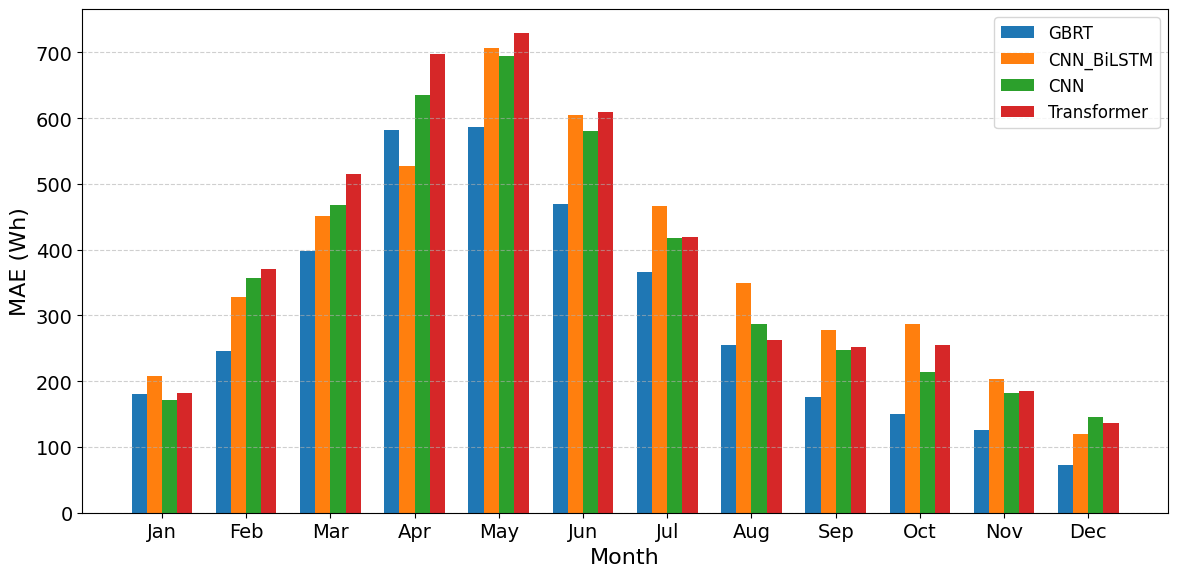

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import calendar

labels = [calendar.month_abbr[i + 1] for i in range(12)]
x = np.arange(len(labels))
width = 0.18
models = list(monthly_mae.keys())

# Set global font sizes
plt.rcParams.update({'font.size': 14})

# Create single plot for MAE
fig, ax = plt.subplots(figsize=(12, 6))

# --- Plot MAE ---
for i, model in enumerate(models):
    ax.bar(x + i * width, monthly_mae[model], width, label=model)

ax.set_ylabel('MAE (Wh)', fontsize=16)
ax.set_xlabel('Month', fontsize=16)
ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels(labels, fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.grid(True, axis='y', linestyle='--', alpha=0.6)

# --- Legend inside the plot (top-right corner) ---
ax.legend(loc='upper right', fontsize=12, frameon=True)

# Adjust layout and save
plt.tight_layout()
plt.savefig('compar_ex3.pdf')
plt.show()

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import calendar

labels = [calendar.month_abbr[i + 1] for i in range(12)]
x = np.arange(len(labels))
width = 0.18
models = list(monthly_mae.keys())

# Create single plot for MAE
fig, ax = plt.subplots(figsize=(12, 6))

# --- Plot MAE ---
for i, model in enumerate(models):
    ax.bar(x + i * width, monthly_mae[model], width, label=model)

ax.set_ylabel('MAE (Wh)')
ax.set_xlabel('Month')
ax.set_xticks(x + width * (len(models)-1)/2)
ax.set_xticklabels(labels)
ax.grid(True, axis='y', linestyle='--', alpha=0.6)

# --- Legend inside the plot (top-right corner) ---
ax.legend(loc='upper right', frameon=True)

# Adjust layout and save
plt.tight_layout()
plt.savefig('compar_ex2.pdf')
plt.show()


NameError: name 'monthly_mae' is not defined

In [25]:
# Make sure predictions are all shaped: (365, 24, 2)
def ensure_3d(pred):
    if pred.ndim == 2 and pred.shape[1] == 48:
        return pred.reshape((-1, 24, 2))
    return pred

# Reshape if needed
pred_gbrt = ensure_3d(pred_gbrt)
pred_lstm = ensure_3d(pred_lstm)
pred_cnn = ensure_3d(pred_cnn)
pred_transformer = ensure_3d(pred_transformer)

# Store model predictions
models = {
    "GBRT": pred_gbrt,
    "LSTM": pred_lstm,
    "1D CNN": pred_cnn,
    "Transformer": pred_transformer
}

# Initialize results
hourly_mae_combined = {name: [] for name in models}

# Compute combined MAE for each hour
for hour in range(24):
    y_h = y_test[:, hour, :]  # (365, 2)
    for name, pred in models.items():
        p_h = pred[:, hour, :]  # (365, 2)
        error = np.abs(y_h - p_h)
        mae = np.mean(error)  # average over 365 * 2
        hourly_mae_combined[name].append(mae)


In [28]:
def r_squared(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    ss_total = np.sum((y_true - np.mean(y_true)) ** 2)
    ss_res = np.sum((y_true - y_pred) ** 2)
    return 1 - (ss_res / ss_total) if ss_total != 0 else 0.0

# Store R² values
hourly_r2_combined = {name: [] for name in models}

for hour in range(24):
    y_h = y_test[:, hour, :]  # shape: (365, 2)
    for name, pred in models.items():
        p_h = pred[:, hour, :]
        r2 = r_squared(y_h, p_h)
        hourly_r2_combined[name].append(r2)


In [18]:
# Make sure predictions are all shaped: (365, 24, 2)
def ensure_3d(pred):
    if pred.ndim == 2 and pred.shape[1] == 48:
        return pred.reshape((-1, 24, 2))
    return pred

# Reshape if needed
pred_gbrt = ensure_3d(pred_gbrt)
pred_lstm = ensure_3d(pred_lstm)
pred_cnn = ensure_3d(pred_cnn)
pred_transformer = ensure_3d(pred_transformer)

# Store model predictions
models = {
    "GBRT": pred_gbrt,
    "LSTM": pred_lstm,
    "CNN": pred_cnn,
    "Transformer": pred_transformer
}

# Initialize results
hourly_mae_combined = {name: [] for name in models}

# Compute combined MAE for each hour
for hour in range(24):
    y_h = y_test[:, hour, :]  # (365, 2)
    for name, pred in models.items():
        p_h = pred[:, hour, :]  # (365, 2)
        error = np.abs(y_h - p_h)
        mae = np.mean(error)  # average over 365 * 2
        hourly_mae_combined[name].append(mae)
import matplotlib.pyplot as plt
import numpy as np

labels = [str(h) for h in range(24)]  # Hours 0 to 23
x = np.arange(len(labels))
width = 0.18
model_names = list(hourly_mae_combined.keys())

fig, ax = plt.subplots(figsize=(16, 6))

# Plot each model's bars
for i, model in enumerate(model_names):
    ax.bar(x + i * width, hourly_mae_combined[model], width, label=model)

# Formatting
ax.set_ylabel('Combined MAE (Wh)')
ax.set_xlabel('Time of the day')

ax.set_xticks(x + width * (len(model_names) - 1) / 2)
ax.set_xticklabels(labels)
ax.grid(True, axis='y', linestyle='--', alpha=0.6)
ax.legend(loc='upper right', frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('hourly_compar1.pdf')


NameError: name 'pred_lstm' is not defined

In [17]:
import matplotlib.pyplot as plt
import numpy as np

labels = [str(h) for h in range(24)]  # Hours 0 to 23
x = np.arange(len(labels))
width = 0.18
model_names = list(hourly_mae_combined.keys())

# Set global font sizes
plt.rcParams.update({'font.size': 14})

fig, ax = plt.subplots(figsize=(16, 6))

# Plot each model's bars
for i, model in enumerate(model_names):
    ax.bar(x + i * width, hourly_mae_combined[model], width, label=model)

# Formatting
ax.set_ylabel('MAE (Wh)', fontsize=16)
ax.set_xlabel('Hour of the Day', fontsize=16)
ax.set_xticks(x + width * (len(model_names) - 1) / 2)
ax.set_xticklabels(labels, fontsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.grid(True, axis='y', linestyle='--', alpha=0.6)
ax.legend(loc='upper right', fontsize=12, frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('hourly_compar3.pdf')
plt.show()


NameError: name 'hourly_mae_combined' is not defined

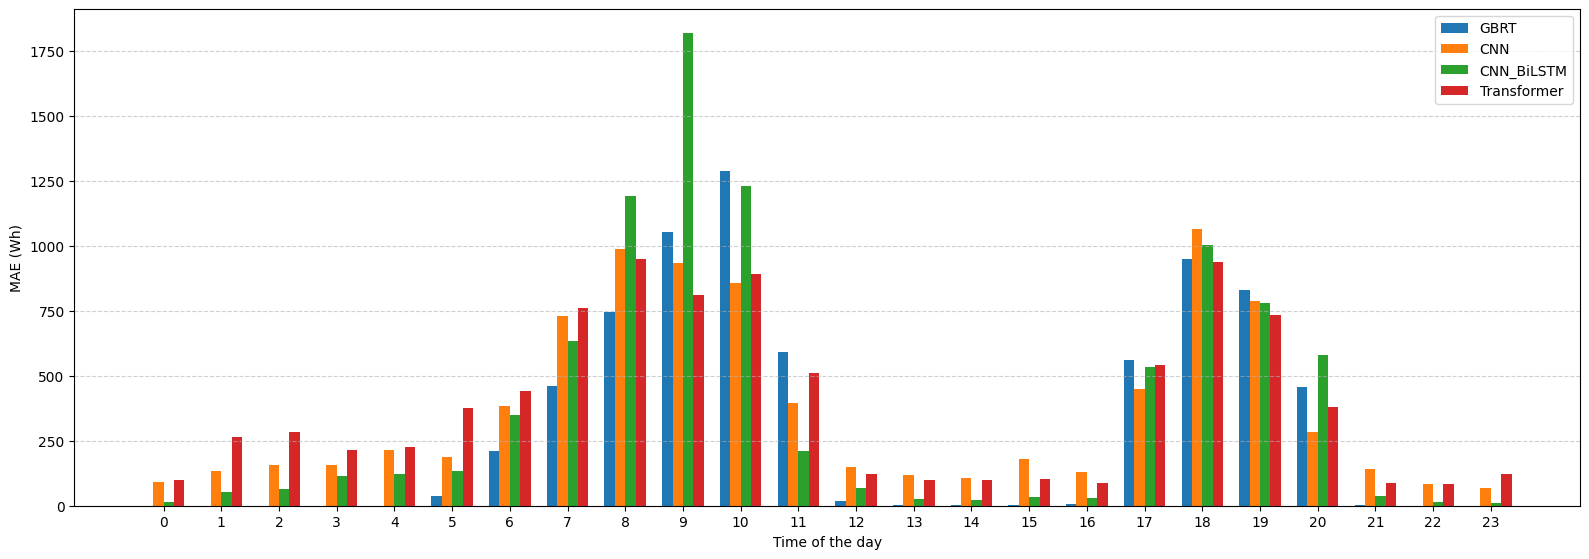

In [27]:
# Make sure predictions are all shaped: (365, 24, 2)
def ensure_3d(pred):
    if pred.ndim == 2 and pred.shape[1] == 48:
        return pred.reshape((-1, 24, 2))
    return pred

# Reshape if needed
pred_gbrt = ensure_3d(pred_gbrt)
pred_lstm = ensure_3d(pred_cnn_bilstm)
pred_cnn = ensure_3d(pred_cnn)
pred_transformer = ensure_3d(pred_transformer)

# Store model predictions
models = {
    "GBRT": pred_gbrt,
    "CNN": pred_cnn,
    "CNN_BiLSTM": pred_cnn_bilstm,
    "Transformer": pred_transformer
}

# Initialize results
hourly_mae_combined = {name: [] for name in models}

# Compute combined MAE for each hour
for hour in range(24):
    y_h = y_test[:, hour, :]  # (365, 2)
    for name, pred in models.items():
        p_h = pred[:, hour, :]  # (365, 2)
        error = np.abs(y_h - p_h)
        mae = np.mean(error)  # average over 365 * 2
        hourly_mae_combined[name].append(mae)
import matplotlib.pyplot as plt
import numpy as np

labels = [str(h) for h in range(24)]  # Hours 0 to 23
x = np.arange(len(labels))
width = 0.18
model_names = list(hourly_mae_combined.keys())

fig, ax = plt.subplots(figsize=(16, 6))

# Plot each model's bars
for i, model in enumerate(model_names):
    ax.bar(x + i * width, hourly_mae_combined[model], width, label=model)

# Formatting
ax.set_ylabel('MAE (Wh)')
ax.set_xlabel('Time of the day')

ax.set_xticks(x + width * (len(model_names) - 1) / 2)
ax.set_xticklabels(labels)
ax.grid(True, axis='y', linestyle='--', alpha=0.6)
ax.legend(loc='upper right', frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('hourly_compar3.pdf')


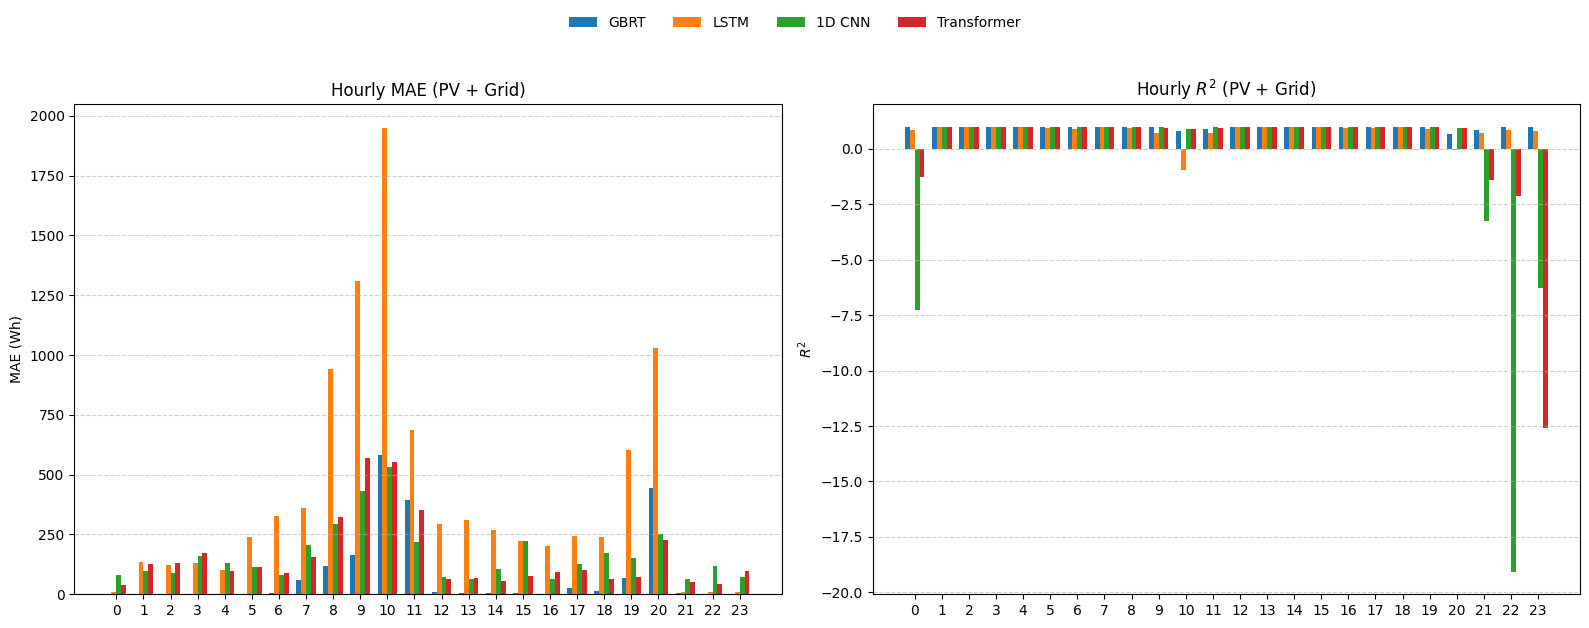

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import calendar

# --- Step 1: Ensure predictions are 3D: (365, 24, 2)
def ensure_3d(pred):
    if pred.ndim == 2 and pred.shape[1] == 48:
        return pred.reshape((-1, 24, 2))
    return pred

# Apply reshape if needed
pred_gbrt = ensure_3d(pred_gbrt)
pred_lstm = ensure_3d(pred_lstm)
pred_cnn = ensure_3d(pred_cnn)
pred_transformer = ensure_3d(pred_transformer)

# Ground truth (assumed already correct)
y_true = y_test  # shape: (365, 24, 2)

# --- Step 2: Store predictions
models = {
    "GBRT": pred_gbrt,
    "LSTM": pred_lstm,
    "1D CNN": pred_cnn,
    "Transformer": pred_transformer
}

# --- Step 3: Evaluation helpers
def r_squared(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    ss_total = np.sum((y_true - np.mean(y_true)) ** 2)
    ss_res = np.sum((y_true - y_pred) ** 2)
    return 1 - (ss_res / ss_total) if ss_total != 0 else 0.0

# --- Step 4: Compute hourly MAE and R²
hourly_mae = {name: [] for name in models}
hourly_r2 = {name: [] for name in models}

for hour in range(24):
    y_h = y_true[:, hour, :].reshape(-1)  # PV + Grid
    for name, pred in models.items():
        p_h = pred[:, hour, :].reshape(-1)
        mae = np.mean(np.abs(y_h - p_h))
        r2 = r_squared(y_h, p_h)
        hourly_mae[name].append(mae)
        hourly_r2[name].append(r2)

# --- Step 5: Plotting
labels = [str(h) for h in range(24)]  # Hour labels
x = np.arange(len(labels))
width = 0.18
model_names = list(models.keys())

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

# --- Plot Hourly MAE ---
for i, model in enumerate(model_names):
    axes[0].bar(x + i * width, hourly_mae[model], width, label=model)
axes[0].set_ylabel('MAE (Wh)')
axes[0].set_title('Hourly MAE (PV + Grid)')
axes[0].set_xticks(x + width * (len(model_names)-1)/2)
axes[0].set_xticklabels(labels)
axes[0].grid(True, axis='y', linestyle='--', alpha=0.6)

# --- Plot Hourly R² ---
for i, model in enumerate(model_names):
    axes[1].bar(x + i * width, hourly_r2[model], width, label=model)
axes[1].set_ylabel('$R^2$')
axes[1].set_title('Hourly $R^2$ (PV + Grid)')
axes[1].set_xticks(x + width * (len(model_names)-1)/2)
axes[1].set_xticklabels(labels)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.6)

# --- Legend at the top ---
fig.legend(
    labels=model_names,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.05),
    ncol=len(model_names),
    frameon=False
)

# Final layout tweaks
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


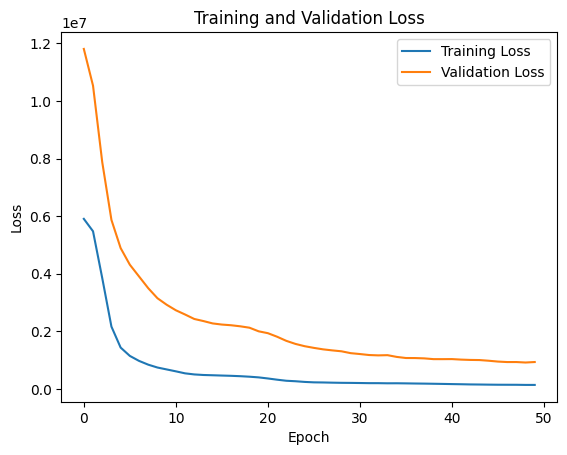

In [47]:
import matplotlib.pyplot as plt

# Assuming you have trained your model and stored the history


# Plot training loss and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.savefig('11.pdf')

In [30]:
import numpy as np

def mean_absolute_percentage_error(y_test, pred):
    y_test, pred = np.array(y_test[:,:,1]), np.array(pred[:,:,1])
    return np.mean(np.abs((y_test - pred) / y_test)) * 100

# Example usage
mape = mean_absolute_percentage_error(y_test, pred)
print(f"MAPE: {mape:.2f}%")


MAPE: 70.06%


In [10]:
pred = model.predict(x_test)
np.mean(np.abs(y_test[:,:,1] - pred[:,:,1]))

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


182.9521092002785

**Early Stopping**

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, Dropout, Reshape
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import Huber


# Define the model
model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(0.001), input_shape=(24, 1)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(0.001)),
    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),  # Dropout to prevent overfitting
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(24 * 2, activation='linear'),
    Reshape((24, 2))
])

# Compile with Huber Loss (better for noisy regression)
model.compile(optimizer='adam', loss=Huber(), metrics=['mae'])

# Early Stopping Callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(x_train, y_train, validation_data=(x_test, y_test), 
                    epochs=100, batch_size=32, callbacks=[early_stopping])

# Evaluate the model
loss, mae = model.evaluate(x_test, y_test)
print(f"Test Loss: {loss}, Test MAE: {mae}")


Epoch 1/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 1182.3280 - mae: 1182.5250 - val_loss: 753.8956 - val_mae: 754.1458
Epoch 2/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 539.2177 - mae: 539.4692 - val_loss: 536.8387 - val_mae: 537.0927
Epoch 3/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 424.3503 - mae: 424.6059 - val_loss: 539.0317 - val_mae: 539.2880
Epoch 4/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 371.0279 - mae: 371.2854 - val_loss: 718.1151 - val_mae: 718.3693
Epoch 5/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 345.1774 - mae: 345.4331 - val_loss: 475.1220 - val_mae: 475.3764
Epoch 6/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 340.1301 - mae: 340.3828 - val_loss: 538.9075 - val_mae: 539.1599
Epoch 7/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 324.8282 - mae: 325.0779 - val_loss: 409.8935 - val_mae: 410.1419
Epoch 8/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 315.8290 - mae: 316.0767 - val_loss: 482.9484 - 

In [22]:
import numpy as np

def r_squared(y_test, pred):
    y_test, pred = np.array(y_test[:,:,1]), np.array(pred[:,:,1])
    ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
    ss_residual = np.sum((y_test - pred) ** 2)
    return 1 - (ss_residual / ss_total)

# Example usage
r2 = r_squared(y_test, pred)
print(f"R²: {r2:.4f}")


R²: 0.9947


In [14]:
import numpy as np

def relative_error_total(y_test, pred):
    y_test, pred = np.array(y_test[:,:,1]), np.array(pred[:,:,1])
    return np.sum(np.abs(y_test - pred)) / np.sum(y_test)

# Example usage
ret = relative_error_total(y_test, pred)
print(f"Relative Error in Total: {ret:.4f}")


Relative Error in Total: 0.0650


In [42]:
import optuna
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, Reshape
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import MeanAbsoluteError

# Define the objective function for Optuna
def objective(trial):
    # Hyperparameter search space
    num_filters = trial.suggest_categorical("num_filters", [32, 64, 128])
    kernel_size = trial.suggest_int("kernel_size", 2, 5)
    dense_1_units = trial.suggest_int("dense_1_units", 128, 512, step=64)
    dense_2_units = trial.suggest_int("dense_2_units", 64, 256, step=64)
    learning_rate = trial.suggest_loguniform("learning_rate", 1e-4, 1e-2)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    # Define the model
    model = Sequential([
        Conv1D(num_filters, kernel_size=kernel_size, activation='relu', input_shape=(24, 1)),
        Flatten(),
        Dense(dense_1_units, activation='relu'),
        Dense(dense_2_units, activation='relu'),
        Dense(24 * 2, activation='linear'),
        Reshape((24, 2))
    ])

    # Compile the model
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss=MeanSquaredError(), metrics=[MeanAbsoluteError()])

    # Train the model
    model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=10, batch_size=batch_size, verbose=0)

    # Evaluate the model
    loss, mae = model.evaluate(x_test, y_test, verbose=0)
    
    return loss  # Optuna minimizes the loss

# Run the Optuna study
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler())
study.optimize(objective, n_trials=30)

# Print the best hyperparameters
print("Best hyperparameters:", study.best_params)


[I 2025-02-16 21:10:32,796] A new study created in memory with name: no-name-83cb69e0-01bf-4e05-b744-9590c69c1ba0
<ipython-input-42-5b5e2404ca4e>:16: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform("learning_rate", 1e-4, 1e-2)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2025-02-16 21:10:42,153] Trial 0 finished with value: 168131.625 and parameters: {'num_filters': 32, 'kernel_size': 2, 'dense_1_units': 128, 'dense_2_units': 64, 'learning_rate': 0.009940144484847263, 'batch_size': 16}. Best 

Best hyperparameters: {'num_filters': 64, 'kernel_size': 3, 'dense_1_units': 512, 'dense_2_units': 192, 'learning_rate': 0.00047919145475059093, 'batch_size': 32}


In [9]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, MultiHeadAttention, LayerNormalization, Dropout
from tensorflow.keras.models import Model

# Transformer Block
def transformer_encoder(inputs, head_size=64, num_heads=4, ff_dim=128, dropout=0.1):
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads)(inputs, inputs)
    x = Dropout(dropout)(x)
    x = LayerNormalization(epsilon=1e-6)(x)
    res = x + inputs  # Residual connection

    x = Dense(ff_dim, activation="relu")(res)
    x = Dropout(dropout)(x)
    x = Dense(inputs.shape[-1])(x)
    x = LayerNormalization(epsilon=1e-6)(x)

    return x + res  # Another residual connection






# Input
inputs = Input(shape=(24, 1))

# Transformer layers
x = transformer_encoder(inputs)
x = tf.keras.layers.Flatten()(x)
x = Dense(128, activation="relu")(x)
x = Dense(64, activation="relu")(x)
x = Dense(24 * 2, activation="linear")(x)
outputs = Reshape((24, 2))(x)

# Define model
model_transformer = Model(inputs, outputs)

# Compile and train
model_transformer.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_transformer.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=50, batch_size=32)


Epoch 1/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 2444879.2500 - mae: 948.8532 - val_loss: 770702.7500 - val_mae: 516.0557
Epoch 2/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 122226.0938 - mae: 223.5009 - val_loss: 354860.5000 - val_mae: 369.1207
Epoch 3/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 62921.1562 - mae: 161.3022 - val_loss: 235581.8125 - val_mae: 311.5366
Epoch 4/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 41791.3125 - mae: 131.5646 - val_loss: 223984.9219 - val_mae: 298.0147
Epoch 5/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 30757.9746 - mae: 112.7455 - val_loss: 206400.4219 - val_mae: 277.1882
Epoch 6/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 23977.4219 - mae: 98.5301 - val_loss: 200543.0156 - val_mae: 269.5546
Epoch 7/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 20489.4902 - mae: 89.9968 - val_loss: 181947.0938 - val_mae: 253.0178
Epoch 8/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 18278.8047 - m

In [11]:
import optuna
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, MultiHeadAttention, LayerNormalization, Dropout, Reshape, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

# Assume x_train, y_train, x_test, y_test are already defined:
# x_train shape: (n_samples, 24, 1)
# y_train shape: (n_samples, 24, 2)

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout):
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads)(inputs, inputs)
    x = Dropout(dropout)(x)
    x = LayerNormalization(epsilon=1e-6)(x)
    res = x + inputs  # Residual connection

    x = Dense(ff_dim, activation="relu")(res)
    x = Dropout(dropout)(x)
    x = Dense(inputs.shape[-1])(x)
    x = LayerNormalization(epsilon=1e-6)(x)
    
    return x + res  # Second residual connection

def create_transformer_model(trial):
    # Hyperparameter search space
    head_size = trial.suggest_categorical('head_size', [32, 64, 128])
    num_heads = trial.suggest_categorical('num_heads', [2, 4, 8])
    ff_dim = trial.suggest_int('ff_dim', 64, 256)
    dense_units_1 = trial.suggest_int('dense_units_1', 64, 256)
    dense_units_2 = trial.suggest_int('dense_units_2', 32, 128)
    dropout_rate = trial.suggest_float('dropout_rate', 0.0, 0.4)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)

    inputs = Input(shape=(24, 1))
    x = transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout_rate)
    x = Flatten()(x)
    x = Dense(dense_units_1, activation="relu")(x)
    x = Dense(dense_units_2, activation="relu")(x)
    x = Dense(24 * 2, activation="linear")(x)
    outputs = Reshape((24, 2))(x)

    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse', metrics=['mae'])
    return model

def objective(trial):
    # Train/val split
    x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

    model = create_transformer_model(trial)
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)

    model.fit(
        x_tr, y_tr,
        validation_data=(x_val, y_val),
        epochs=50,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    val_loss, _ = model.evaluate(x_val, y_val, verbose=0)
    return val_loss

# Run Optuna Study
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler())
study.optimize(objective, n_trials=30)

# Best trial info
print("Best Trial:")
for key, value in study.best_trial.params.items():
    print(f"  {key}: {value}")

# Train final model with best parameters
final_model = create_transformer_model(study.best_trial)
final_model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=50, batch_size=32, verbose=1)

# Evaluate final model
loss, mae = final_model.evaluate(x_test, y_test)
print(f"Transformer Test Loss: {loss:.4f}, Test MAE: {mae:.4f}")


[I 2025-04-13 17:10:03,917] A new study created in memory with name: no-name-edd0959e-dd02-42e7-9465-30f70037737e
[I 2025-04-13 17:11:11,682] Trial 0 finished with value: 4481.9189453125 and parameters: {'head_size': 128, 'num_heads': 2, 'ff_dim': 255, 'dense_units_1': 96, 'dense_units_2': 79, 'dropout_rate': 0.007148352473577636, 'learning_rate': 0.00043654332078394586}. Best is trial 0 with value: 4481.9189453125.
[I 2025-04-13 17:12:06,893] Trial 1 finished with value: 10491.0546875 and parameters: {'head_size': 32, 'num_heads': 4, 'ff_dim': 123, 'dense_units_1': 231, 'dense_units_2': 61, 'dropout_rate': 0.30400651837748766, 'learning_rate': 0.00011303036045560562}. Best is trial 0 with value: 4481.9189453125.
[I 2025-04-13 17:13:45,081] Trial 2 finished with value: 3842.838134765625 and parameters: {'head_size': 128, 'num_heads': 4, 'ff_dim': 252, 'dense_units_1': 237, 'dense_units_2': 59, 'dropout_rate': 0.02936618990643951, 'learning_rate': 0.0011146677625284347}. Best is trial 2

Best Trial:
  head_size: 32
  num_heads: 8
  ff_dim: 140
  dense_units_1: 214
  dense_units_2: 96
  dropout_rate: 0.17442489473657014
  learning_rate: 0.0017198703686266369
Epoch 1/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 969158.8750 - mae: 578.7768 - val_loss: 364350.0000 - val_mae: 394.3216
Epoch 2/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 50786.8359 - mae: 151.1673 - val_loss: 222677.1719 - val_mae: 300.4477
Epoch 3/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 26612.1992 - mae: 106.8650 - val_loss: 169456.9531 - val_mae: 256.2851
Epoch 4/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 18520.5723 - mae: 87.9660 - val_loss: 138332.7812 - val_mae: 224.9159
Epoch 5/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 14260.0029 - mae: 76.8513 - val_loss: 134442.0000 - val_mae: 230.8572
Epoch 6/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 12059.9414 - mae: 69.5282 - val_loss: 118086.3203 - val_mae: 215.1179
Epoch 7/50
126/126 ━━━━━━━━━━━━━━━━━━

In [10]:
pred_transformer = model_transformer.predict(x_test)

def mean_absolute_error(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.mean(np.abs(y_test - pred))

def relative_error_total(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.sum(np.abs(y_test - pred)) / np.sum(np.abs(y_test))

def r_squared(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
    ss_residual = np.sum((y_test - pred) ** 2)
    return 1 - (ss_residual / ss_total)
mae = mean_absolute_error(y_test, pred_transformer)
ret = relative_error_total(y_test, pred_transformer)
r2 = r_squared(y_test, pred_transformer)

print(f"MAE: {mae:.2f} Wh")
print(f"Relative Error in Total: {ret:.4f}")
print(f"R²: {r2:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
MAE: 130.86 Wh
Relative Error in Total: 0.0621
R²: 0.9923


In [15]:
pred = model_transformer.predict(x_test)
def mean_absolute_error(y_test, pred):
    y_test, pred = np.array(y_test[:,:,1]), np.array(pred[:,:,1])
    return np.mean(np.abs(y_test - pred))

def relative_error_total(y_test, pred):
    y_test, pred = np.array(y_test), np.array(pred)
    return np.sum(np.abs(y_test - pred)) / np.sum(y_test)

def r_squared(y_test, pred):
    y_test, pred = np.array(y_test), np.array(pred)
    ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
    ss_residual = np.sum((y_test - pred) ** 2)
    return 1 - (ss_residual / ss_total)

# Example usage
mae = mean_absolute_error(y_test, pred)
ret = relative_error_total(y_test, pred)
r2 = r_squared(y_test, pred)

print(f"MAE: {mae:.2f} Wh")
print(f"Relative Error in Total: {ret:.4f}")
print(f"R²: {r2:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
MAE: 115.76 Wh
Relative Error in Total: 0.0897
R²: 0.9919


In [33]:
import numpy as np
pred = model.predict(x_test)
def mean_absolute_percentage_error(y_test, pred):
    y_test, pred = np.array(y_test[:,:,1]), np.array(pred[:,:,1])
    return np.mean(np.abs((y_test - pred) / y_test)) * 100

def relative_error_total(y_test, pred):
    y_test, pred = np.array(y_test), np.array(pred)
    return np.sum(np.abs(y_test - pred)) / np.sum(y_test)

def r_squared(y_test, pred):
    y_test, pred = np.array(y_test), np.array(pred)
    ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
    ss_residual = np.sum((y_test - pred) ** 2)
    return 1 - (ss_residual / ss_total)

# Example usage
mape = mean_absolute_percentage_error(y_test, pred)
ret = relative_error_total(y_test, pred)
r2 = r_squared(y_test, pred)

print(f"MAPE: {mape:.2f}%")
print(f"Relative Error in Total: {ret:.4f}")
print(f"R²: {r2:.4f}")


MAPE: 70.06%
Relative Error in Total: 0.2544
R²: 0.8863


LSTM

In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Reshape

# Define LSTM model
model_lstm = Sequential([
    LSTM(64, activation='relu', return_sequences=True, input_shape=(24, 1)),
    LSTM(32, activation='relu', return_sequences=False),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(24 * 2, activation='linear'),  # Predicts 24 hours of (PV, network)
    Reshape((24, 2))  # Reshape to (24, 2) for output
])

# Compile and train
model_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_lstm.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=50, batch_size=32)


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 4220965.5000 - mae: 1284.3640 - val_loss: 5133138.0000 - val_mae: 1308.4296
Epoch 2/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 1891352.6250 - mae: 881.4131 - val_loss: 3717307.5000 - val_mae: 1136.1544
Epoch 3/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 1063025.5000 - mae: 690.1726 - val_loss: 2429242.5000 - val_mae: 952.7800
Epoch 4/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 658920.0625 - mae: 530.8134 - val_loss: 2671720.7500 - val_mae: 971.5361
Epoch 5/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 636892.5000 - mae: 516.1462 - val_loss: 2689182.5000 - val_mae: 962.1259
Epoch 6/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 752742.6250 - mae: 553.7594 - val_loss: 3150722.7500 - val_mae: 995.3477
Epoch 7/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 660471.5625 - mae: 511.4970 - val_loss: 2178789.2500 - val_mae: 750.6071
Epoch 8/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 766807

In [36]:
import numpy as np
pred = model_lstm.predict(x_test)
def mean_absolute_error(y_test, pred):
    y_test, pred = np.array(y_test[:,:,1]), np.array(pred[:,:,1])
    return np.mean(np.abs(y_test - pred))

def relative_error_total(y_test, pred):
    y_test, pred = np.array(y_test), np.array(pred)
    return np.sum(np.abs(y_test - pred)) / np.sum(y_test)

def r_squared(y_test, pred):
    y_test, pred = np.array(y_test), np.array(pred)
    ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
    ss_residual = np.sum((y_test - pred) ** 2)
    return 1 - (ss_residual / ss_total)

# Example usage
mae = mean_absolute_error(y_test, pred)
ret = relative_error_total(y_test, pred)
r2 = r_squared(y_test, pred)

print(f"MAE: {mae:.2f} Wh")
print(f"Relative Error in Total: {ret:.4f}")
print(f"R²: {r2:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
MAE: 1008.96 Wh
Relative Error in Total: 0.3792
R²: 0.8200


Finland Data

In [43]:
data_fin = pd.read_csv('/kaggle/input/finland-dataset/Farm_load_kW_data.txt',header = None)
pv_fin = pd.read_csv('/kaggle/input/finland-dataset/PV_pu_data.txt',header = None)

In [44]:
data_fin[0]

0       29.227938
1       26.635586
2       24.691912
3       25.997035
4       31.203100
          ...    
8755    45.417134
8756    32.447745
8757    27.911025
8758    24.670828
8759    25.974841
Name: 0, Length: 8760, dtype: float64

In [45]:
dataset_fin = pd.DataFrame({'Load':data_fin[0],'PV':pv_fin[0]})

In [46]:
x_fin = data_fin[0] - pv_fin[0]

In [47]:
x_fin = np.array(x_fin)
x_fin = x_fin.reshape(365,24,1)

In [35]:
x_test.shape

(365, 24, 1)

In [48]:
pred_fin = model_transformer.predict(x_fin)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


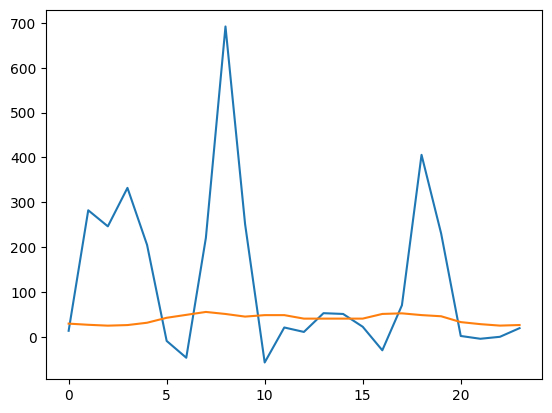

In [49]:
plt.plot(pred_fin[0,:,0])
plt.plot(data_fin[0][0:24])

In [50]:
r_squared(data_fin, pred_fin)

AttributeError: 'DataFrame' object has no attribute 'flatten'

**Transformer**

In [3]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, MultiHeadAttention, LayerNormalization, Dropout, Reshape
from tensorflow.keras.models import Model

# Transformer Block
def transformer_encoder(inputs, head_size=64, num_heads=4, ff_dim=128, dropout=0.1):
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads)(inputs, inputs)
    x = Dropout(dropout)(x)
    x = LayerNormalization(epsilon=1e-6)(x)
    res = x + inputs  # Residual connection

    x = Dense(ff_dim, activation="relu")(res)
    x = Dropout(dropout)(x)
    x = Dense(inputs.shape[-1])(x)
    x = LayerNormalization(epsilon=1e-6)(x)

    return x + res  # Another residual connection

# Model Definition
inputs = Input(shape=(24, 1))  # 24-hour sequences

# Apply Transformer layers
x = transformer_encoder(inputs)
x = transformer_encoder(x)  # Stack another Transformer layer
x = tf.keras.layers.Flatten()(x)
x = Dense(128, activation="relu")(x)
x = Dense(64, activation="relu")(x)
x = Dense(24 * 2, activation="linear")(x)  # Predict next 24 hours, 2 outputs (PV + network)
outputs = Reshape((24, 2))(x)

# Define model
model_transformer = Model(inputs, outputs)

# Compile
model_transformer.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train
model_transformer.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=50, batch_size=32)

# Evaluate
loss, mae = model_transformer.evaluate(x_test, y_test)
print(f"Test Loss: {loss}, Test MAE: {mae}")


Epoch 1/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 2336956.5000 - mae: 959.8760 - val_loss: 614793.8750 - val_mae: 478.5324
Epoch 2/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 96640.0625 - mae: 207.1729 - val_loss: 370196.5625 - val_mae: 392.5388
Epoch 3/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 45659.3203 - mae: 142.9520 - val_loss: 287859.3438 - val_mae: 351.7763
Epoch 4/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 30212.9785 - mae: 116.5971 - val_loss: 245893.5156 - val_mae: 313.8880
Epoch 5/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 24578.2715 - mae: 102.7421 - val_loss: 213523.4375 - val_mae: 296.7451
Epoch 6/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 20625.9219 - mae: 92.7735 - val_loss: 193887.6562 - val_mae: 273.9541
Epoch 7/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 17266.3770 - mae: 84.5751 - val_loss: 189498.8750 - val_mae: 272.0362
Epoch 8/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 14889.8271 - ma

In [4]:
pred = model_transformer.predict(x_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


In [10]:


def mean_absolute_error(y_test, pred):
    y_test, pred = np.array(y_test[:,:,1]), np.array(pred[:,:,1])
    return np.mean(np.abs(y_test - pred))

def relative_error_total(y_test, pred):
    y_test, pred = np.array(y_test), np.array(pred)
    return np.sum(np.abs(y_test - pred)) / np.sum(y_test)

def r_squared(y_test, pred):
    y_test, pred = np.array(y_test), np.array(pred)
    ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
    ss_residual = np.sum((y_test - pred) ** 2)
    return 1 - (ss_residual / ss_total)

# Example usage
mae = mean_absolute_error(y_test, pred)
ret = relative_error_total(y_test, pred)
r2 = r_squared(y_test, pred)

print(f"MAE: {mae:.2f} Wh")
print(f"Relative Error in Total: {ret:.4f}")
print(f"R²: {r2:.4f}")

MAE: 166.96 Wh
Relative Error in Total: 0.1026
R²: 0.9901


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


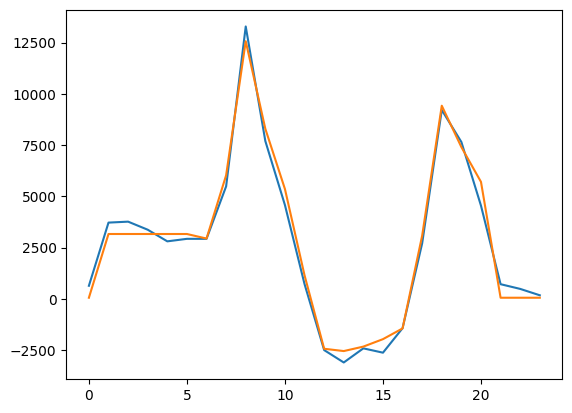

In [11]:
import matplotlib.pyplot as plt
plt.plot(model.predict(x_test)[140,:,1])
plt.plot(y_test[140,:,1])

In [17]:
!pip install nixtlats

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.9/73.9 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.0 MB/s eta 0:00:00


In [25]:
import pandas as pd
import numpy as np
import tensorflow as tf
from nixtla import TimeGPT  # Correct import


# Load pretrained TimeGPT model
model = TimeGPT(model_name="timegpt-1")

# Fine-tune TimeGPT on electricity disaggregation data
model.fit(x_train, y_train, freeze_backbone=True)

# Predict PV generation and network electricity for the test set
future_predictions = model.predict(x_test)

# Save predictions
pd.DataFrame(future_predictions).to_csv("disaggregated_predictions.csv", index=False)

print("Disaggregation completed. Predictions saved to 'disaggregated_predictions.csv'.")

ImportError: cannot import name 'TimeGPT' from 'nixtla' (/usr/local/lib/python3.10/dist-packages/nixtla/__init__.py)

In [26]:

import pandas as pd
from nixtla import NixtlaClient

# Initialize the client with your API key
nixtla_client = NixtlaClient(api_key='YOUR_API_KEY')




In [32]:
import pandas as pd
import numpy as np
from nixtla import NixtlaClient

# Initialize NixtlaClient (Make sure you have an API key)
nixtla_client = NixtlaClient(api_key='YOUR_API_KEY')

# Convert x_train and y_train into DataFrame
x_train_df = pd.DataFrame(x_train, columns=['meter_reading'])
y_train_df = pd.DataFrame(y_train, columns=['pv_generation', 'network_electricity'])

# Create an artificial time index
x_train_df["step"] = np.arange(len(x_train_df))
y_train_df["step"] = np.arange(len(y_train_df))

# Merge input and output
train_data = pd.concat([x_train_df, y_train_df], axis=1)

# Train TimeGPT (without timestamps)
horizon = len(y_test)  # Number of steps to predict
forecast_results = nixtla_client.forecast(
    df=train_data,
    h=horizon,
    time_col="step",  # Using artificial index instead of timestamp
    target_col="meter_reading",
    finetune_steps=10  # Adjust fine-tuning steps as needed
)

# Save predictions
predictions = pd.DataFrame(forecast_results, columns=['step', 'predicted_pv', 'predicted_network'])
predictions.to_csv("disaggregated_predictions.csv", index=False)

print("Disaggregation completed. Predictions saved to 'disaggregated_predictions.csv'.")


ValueError: Must pass 2-d input. shape=(4015, 24, 1)

---------------------------------------------------- Different PVs-----------------------------------------------

In [1]:
import pandas as pd
import glob

# Path to CSV files
csv_files = glob.glob("/kaggle/input/dairy-farm-pvs/PV*.csv")

# Create an empty DataFrame
dataset = pd.DataFrame()

# Read each CSV and add it as a separate column
dataframes = []
for file in csv_files:
    df = pd.read_csv(file, index_col=0)  # Remove the index column
    column_name = file.split('.')[0][-3:]  # Use the last 3 characters of the file name as column name
    df.rename(columns={df.columns[0]: column_name}, inplace=True)
    df[(df[column_name] > -0.01) & (df[column_name] < 0.01)] = 0  # Replace values between -0.01 and 0.01 with 0
    dataframes.append(df)

# Concatenate along columns
dataset = pd.concat(dataframes, axis=1)

# Display the first few rows
print(dataset.head())


            V10  PV7  V13  PV3  V11  PV8  PV1  PV4  V12  PV2  V14  PV5  PV9  \
Time stamp                                                                    
1           0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
2           0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
3           0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
4           0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
5           0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

            PV6  
Time stamp       
1           0.0  
2           0.0  
3           0.0  
4           0.0  
5           0.0  


In [2]:
dataset_pv = (dataset.iloc[0:8760])*1000


In [5]:
(dataset_pv)[0:24]

,V10,PV7,V13,PV3,V11,PV8,PV1,PV4,V12,PV2,V14,PV5,PV9,PV6
Time stamp,,,,,,,,,,,,,,
1,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
4,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
5,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
6,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
7,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
8,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
9,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


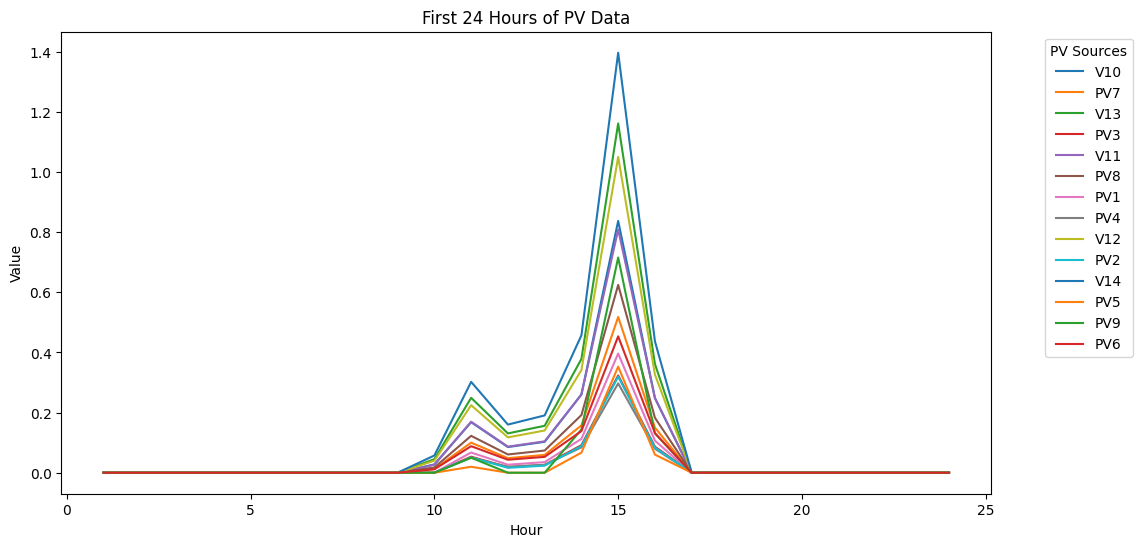

In [6]:
import matplotlib.pyplot as plt
dataset.iloc[:24].plot(figsize=(12, 6), title="First 24 Hours of PV Data")
plt.xlabel("Hour")
plt.ylabel("Value")
plt.legend(title="PV Sources", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [3]:
dataset_uni= pd.read_csv('/kaggle/input/dataset-unisex1/dataset_final_unix.csv',index_col = 'Unnamed: 0')
dataset_uni.drop(['timestamp','SAM'],axis =1 , inplace = True)

In [4]:
dataset_uni.drop(['timestamp','SAM'],axis =1 , inplace = True)

KeyError: "['timestamp', 'SAM'] not found in axis"

In [9]:
dataset_uni

,farm1,farm1 net load,farm2,farm2 net load,farm3,farm3 net load,farm4,farm4 net load,farm5,farm5 net load,...,farm9,farm9 net load,farm10,farm10 net load,farm11,farm11 net load,farm12,farm12 net load,farm13,farm13 net load
0,23.415279,23.415279,23.415279,23.415279,29.269099,29.269099,35.122919,35.122919,40.976739,40.976739,...,58.538198,58.538198,64.392018,64.392018,70.245838,70.245838,70.245838,70.245838,76.099657,76.099657
1,3133.415279,3133.415279,3133.415279,3133.415279,3139.269099,3139.269099,3145.122919,3145.122919,3150.976739,3150.976739,...,3168.538198,3168.538198,3174.392018,3174.392018,3180.245838,3180.245838,3180.245838,3180.245838,3186.099657,3186.099657
2,3133.415279,3133.415279,3133.415279,3133.415279,3139.269099,3139.269099,3145.122919,3145.122919,3150.976739,3150.976739,...,3168.538198,3168.538198,3174.392018,3174.392018,3180.245838,3180.245838,3180.245838,3180.245838,3186.099657,3186.099657
3,3133.415279,3133.415279,3133.415279,3133.415279,3139.269099,3139.269099,3145.122919,3145.122919,3150.976739,3150.976739,...,3168.538198,3168.538198,3174.392018,3174.392018,3180.245838,3180.245838,3180.245838,3180.245838,3186.099657,3186.099657
4,1344.168215,1344.168215,2066.168215,2066.168215,3139.269099,3139.269099,3145.122919,3145.122919,3150.976739,3150.976739,...,3168.538198,3168.538198,3174.392018,3174.392018,3180.245838,3180.245838,3180.245838,3180.245838,3186.099657,3186.099657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,403.521505,403.521505,403.521505,403.521505,504.401882,504.401882,605.282258,605.282258,878.743280,878.743280,...,2241.061828,2241.061828,2695.168011,2695.168011,3088.444700,3088.444700,3149.274194,3149.274194,3603.380376,3603.380376
8756,22.876344,22.876344,22.876344,22.876344,28.595430,28.595430,34.314516,34.314516,40.033602,40.033602,...,57.190860,57.190860,62.909946,62.909946,68.629032,68.629032,68.629032,68.629032,74.348118,74.348118
8757,22.876344,22.876344,22.876344,22.876344,28.595430,28.595430,34.314516,34.314516,40.033602,40.033602,...,57.190860,57.190860,62.909946,62.909946,68.629032,68.629032,68.629032,68.629032,74.348118,74.348118
8758,22.876344,22.876344,22.876344,22.876344,28.595430,28.595430,34.314516,34.314516,40.033602,40.033602,...,57.190860,57.190860,62.909946,62.909946,68.629032,68.629032,68.629032,68.629032,74.348118,74.348118


In [5]:
farm_col = dataset_uni.columns[dataset_uni.columns.str.match(r'.*\d$')]
farm_col = list(farm_col)
data_farm= dataset_uni[farm_col]
dataset_pv = dataset_pv.reset_index()
dataset_combined = pd.concat([data_farm,dataset_pv], axis=1)

dataset_pv.drop('Time stamp',axis =1 , inplace = True)


In [11]:
data_farm

,farm1,farm2,farm3,farm4,farm5,farm6,farm7,farm8,farm9,farm10,farm11,farm12,farm13
0,23.415279,23.415279,29.269099,35.122919,40.976739,46.830558,46.830558,52.684378,58.538198,64.392018,70.245838,70.245838,76.099657
1,3133.415279,3133.415279,3139.269099,3145.122919,3150.976739,3156.830558,3156.830558,3162.684378,3168.538198,3174.392018,3180.245838,3180.245838,3186.099657
2,3133.415279,3133.415279,3139.269099,3145.122919,3150.976739,3156.830558,3156.830558,3162.684378,3168.538198,3174.392018,3180.245838,3180.245838,3186.099657
3,3133.415279,3133.415279,3139.269099,3145.122919,3150.976739,3156.830558,3156.830558,3162.684378,3168.538198,3174.392018,3180.245838,3180.245838,3186.099657
4,1344.168215,2066.168215,3139.269099,3145.122919,3150.976739,3156.830558,3156.830558,3162.684378,3168.538198,3174.392018,3180.245838,3180.245838,3186.099657
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,403.521505,403.521505,504.401882,605.282258,878.743280,1332.849462,1332.849462,1786.955645,2241.061828,2695.168011,3088.444700,3149.274194,3603.380376
8756,22.876344,22.876344,28.595430,34.314516,40.033602,45.752688,45.752688,51.471774,57.190860,62.909946,68.629032,68.629032,74.348118
8757,22.876344,22.876344,28.595430,34.314516,40.033602,45.752688,45.752688,51.471774,57.190860,62.909946,68.629032,68.629032,74.348118
8758,22.876344,22.876344,28.595430,34.314516,40.033602,45.752688,45.752688,51.471774,57.190860,62.909946,68.629032,68.629032,74.348118


In [6]:
dataset_pv

,V10,PV7,V13,PV3,V11,PV8,PV1,PV4,V12,PV2,V14,PV5,PV9,PV6
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8756,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8757,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8758,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


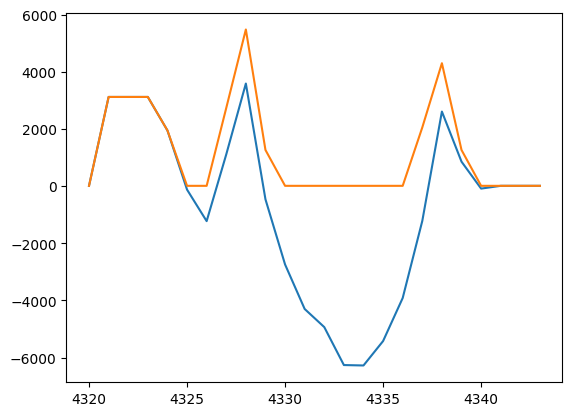

In [13]:
import matplotlib.pyplot as plt
plt.plot((dataset_combined['farm1'] - dataset_combined['PV1'])[180*24:181*24])
plt.plot(dataset_combined['farm1'][180*24:181*24])


In [7]:

x = pd.DataFrame()
for i in range(1, 15):  # Loop from 1 to 14
    farm_col = f"farm{i}"
    possible_pv_cols = [f"PV{i}", f"V{i}"]  # Handle cases where 'P' is missing
    pv_col = next((col for col in dataset_combined.columns if col in possible_pv_cols), None)
    
    if pv_col and farm_col in dataset_combined.columns:
        x[f"Diff{i}"] = dataset_combined[farm_col] - dataset_combined[pv_col]


In [15]:
dataset_combined

,farm1,farm2,farm3,farm4,farm5,farm6,farm7,farm8,farm9,farm10,...,V11,PV8,PV1,PV4,V12,PV2,V14,PV5,PV9,PV6
0,23.415279,23.415279,29.269099,35.122919,40.976739,46.830558,46.830558,52.684378,58.538198,64.392018,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,3133.415279,3133.415279,3139.269099,3145.122919,3150.976739,3156.830558,3156.830558,3162.684378,3168.538198,3174.392018,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3133.415279,3133.415279,3139.269099,3145.122919,3150.976739,3156.830558,3156.830558,3162.684378,3168.538198,3174.392018,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3133.415279,3133.415279,3139.269099,3145.122919,3150.976739,3156.830558,3156.830558,3162.684378,3168.538198,3174.392018,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1344.168215,2066.168215,3139.269099,3145.122919,3150.976739,3156.830558,3156.830558,3162.684378,3168.538198,3174.392018,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,403.521505,403.521505,504.401882,605.282258,878.743280,1332.849462,1332.849462,1786.955645,2241.061828,2695.168011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8756,22.876344,22.876344,28.595430,34.314516,40.033602,45.752688,45.752688,51.471774,57.190860,62.909946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8757,22.876344,22.876344,28.595430,34.314516,40.033602,45.752688,45.752688,51.471774,57.190860,62.909946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8758,22.876344,22.876344,28.595430,34.314516,40.033602,45.752688,45.752688,51.471774,57.190860,62.909946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
x = pd.DataFrame()
missing_columns = []
for i in range(1, 15):  # Loop from 1 to 14
    farm_col = f"farm{i}"
    possible_pv_cols = [f"PV{i}", f"V{i}"]  # Handle cases where 'P' is missing
    pv_col = next((col for col in dataset_combined.columns if col in possible_pv_cols), None)
    
    if pv_col and farm_col in dataset_combined.columns:
        x[f"Diff{i}"] = dataset_combined[farm_col] - dataset_combined[pv_col]
    else:
        missing_columns.append((farm_col, pv_col))

# Print missing columns if any
if missing_columns:
    print("Warning: The following column pairs are missing and were not subtracted:")
    for farm, pv in missing_columns:
        print(f"Farm column: {farm}, PV column: {pv if pv else 'Not Found'}")

Farm column: farm14, PV column: V14


In [9]:
flattened_x = x.values.flatten('F')

In [12]:
# Create an array with shape [8760*13,2]
paired_data = []
for i in range(1, 14):  # Loop from 1 to 13
    farm_col = f"farm{i}"
    possible_pv_cols = [f"PV{i}", f"V{i}"]  # Handle cases where 'P' is missing
    pv_col = next((col for col in dataset_combined.columns if col in possible_pv_cols), None)
    
    if pv_col and farm_col in dataset_combined.columns:
        paired_data.append(np.column_stack((dataset_combined[farm_col].values, dataset_combined[pv_col].values)))

# Stack all pairs into a single array
final_array = np.vstack(paired_data)

In [13]:
final_array[0:8760,1] == dataset_combined['PV1'][0:8760]

0       True
1       True
2       True
3       True
4       True
        ... 
8755    True
8756    True
8757    True
8758    True
8759    True
Name: PV1, Length: 8760, dtype: bool

In [16]:
final_array.shape

(113880, 2)

In [14]:
flattened_x = flattened_x.reshape(-1,1)

In [25]:
flattened_x.shape

(113880, 1)

In [26]:
flattened_x[0]

array([23.41527922])

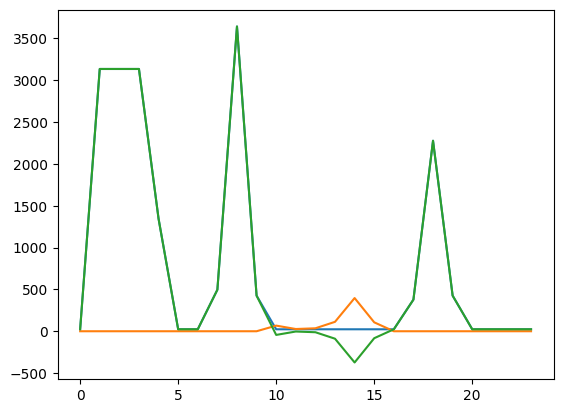

In [26]:

plt.plot(final_array[0:24,0])
plt.plot(final_array[0:24,1])
plt.plot(flattened_x[0:24])


In [15]:
final_array_df = pd.DataFrame(final_array)

In [17]:
final_array_df

,0,1
0,23.415279,0.0
1,3133.415279,0.0
2,3133.415279,0.0
3,3133.415279,0.0
4,1344.168215,0.0
...,...,...
113875,3603.380376,0.0
113876,74.348118,0.0
113877,74.348118,0.0
113878,74.348118,0.0


In [18]:
final_array_df.to_csv('final_array_df.csv')

In [24]:
flattened_x_df = pd.DataFrame(flattened_x)
flattened_x_df.to_csv('flattened_x.csv')

In [20]:
final_array_df.to_csv('different_pv_y.csv')

In [37]:

x_train = flattened_x[:2*-8760].reshape(4015,24,1)
y_train = final_array[:2*-8760].reshape(4015,24,2)
x_val = flattened_x[2*-8760:-8760].reshape(365,24,1)
y_val = final_array[2*-8760:-8760].reshape(365,24,2)
x_test = flattened_x[-8760:].reshape(365,24,1)
y_test = final_array[-8760:].reshape(365,24,2)

In [44]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Stack model predictions together (remove "_train" suffix)
# Assuming pred_gbrt is (365, 48)
pred_gbrt = pred_gbrt.reshape(365, 24, 2)

X_stack = np.concatenate([pred_cnn, pred_lstm, pred_transformer, pred_gbrt], axis=-1)

# Build the meta-model
meta_model = Sequential([
    Input(shape=(X_stack.shape[1],)),
    Dense(64, activation='relu'),
    Dense(2)  # Predict PV and Grid outputs
])

meta_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the meta-model
meta_model.fit(X_stack, y_test, validation_split=0.2, epochs=50, batch_size=32)


Epoch 1/50


ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(None, 24, 8), dtype=float32). Expected shape (None, 24), but input has incompatible shape (None, 24, 8)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 24, 8), dtype=float32)
  • training=True
  • mask=None

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
day = 80

# Plot GBRT
plt.plot(pred_gbrt[day, :, 1], label='GBRT Prediction', linestyle='--')
# Plot LSTM
plt.plot(pred_CNN_bilstm[day, :, 1], label='LSTM Prediction', linestyle='--')
# Plot CNN
plt.plot(pred_cnn[day, :, 1], label='CNN Prediction', linestyle='--')
# Plot Transformer
plt.plot(pred_transformer[day, :, 1], label='Transformer Prediction', linestyle='--')
# Plot Ground Truth
plt.plot(y_test[day, :, 1], label='PV generation', color='black', linewidth=2)

plt.xlabel('Hour of Day')
plt.ylabel('Electricity (Wh)')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('PV.pdf')



NameError: name 'pred_gbrt' is not defined

<Figure size 1200x600 with 0 Axes>

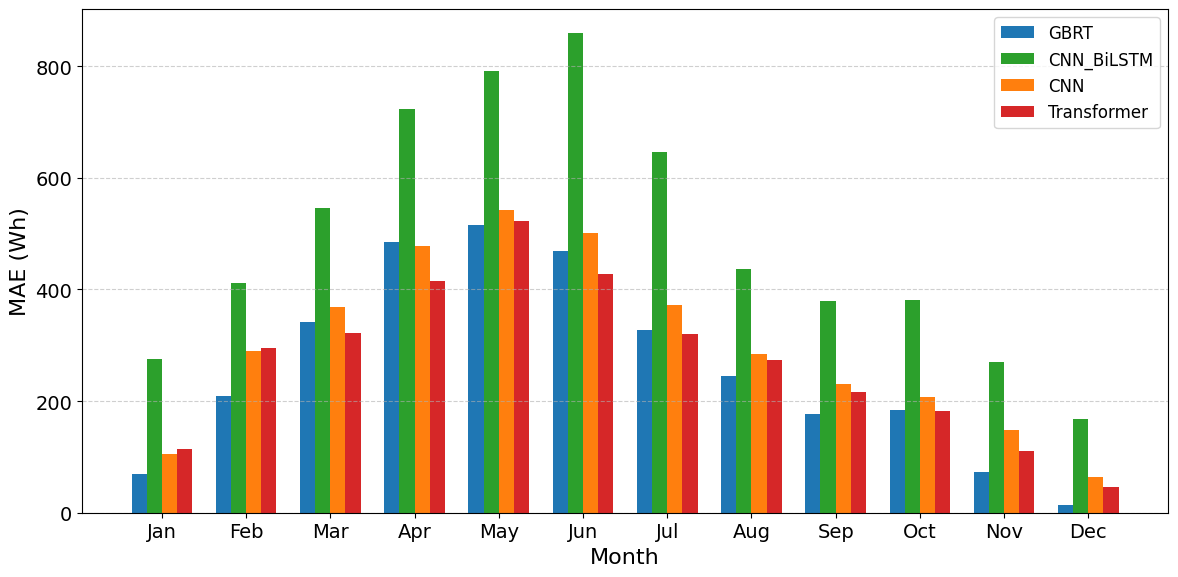

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import calendar

# Your predictions (all shaped: [365, 24, 2])
models = {
    "GBRT": pred_gbrt,
    "CNN_BiLSTM": pred_cnn_bilstm,
    "CNN": pred_cnn,
    "Transformer": pred_transformer
}

# Ground truth
y_true = y_test  # shape: (365, 24, 2)

# Month indexing helper (non-leap year)
days_in_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
month_indices = np.repeat(np.arange(12), days_in_month)

# R² function
def r_squared(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    ss_total = np.sum((y_true - np.mean(y_true)) ** 2)
    ss_res = np.sum((y_true - y_pred) ** 2)
    return 1 - (ss_res / ss_total) if ss_total != 0 else 0.0

# Dictionaries to store results
monthly_mae = {name: [] for name in models}
monthly_r2 = {name: [] for name in models}

# Calculate monthly MAE and R²
for month in range(12):
    mask = month_indices == month
    y_m = y_true[mask]  # shape: (days_in_month, 24, 2)
    for name, pred in models.items():
        p_m = pred[mask]
        y_flat = y_m.reshape(-1)
        p_flat = p_m.reshape(-1)
        monthly_mae[name].append(np.mean(np.abs(y_flat - p_flat)))
        monthly_r2[name].append(r_squared(y_flat, p_flat))
import numpy as np
import matplotlib.pyplot as plt
import calendar

labels = [calendar.month_abbr[i + 1] for i in range(12)]
x = np.arange(len(labels))
width = 0.18
models = list(monthly_mae.keys())

# Set global font sizes
plt.rcParams.update({'font.size': 14})

# Define custom, unique colors for each model
colors = {
    "GBRT": "#1f77b4",        # blue
    "CNN": "#ff7f0e",         # orange
    "CNN_BiLSTM": "#2ca02c",  # green
    "Transformer": "#d62728"  # red
}

# Create single plot for MAE
fig, ax = plt.subplots(figsize=(12, 6))

# --- Plot MAE ---
for i, model in enumerate(models):
    ax.bar(x + i * width, monthly_mae[model], width, label=model, color=colors.get(model, None))

ax.set_ylabel('MAE (Wh)', fontsize=16)
ax.set_xlabel('Month', fontsize=16)
ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels(labels, fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.grid(True, axis='y', linestyle='--', alpha=0.6)

# --- Legend ---
ax.legend(loc='upper right', fontsize=12, frameon=True)

# Adjust layout and save
plt.tight_layout()
plt.savefig('compar_ex2.pdf')



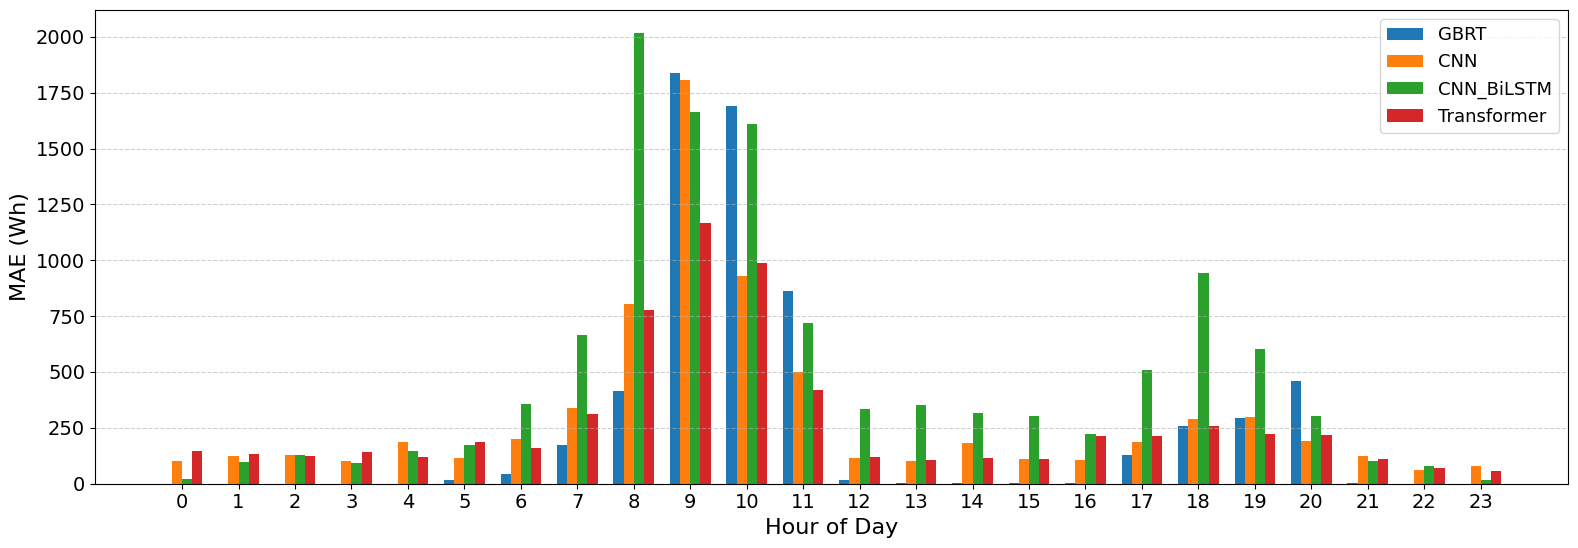

In [45]:
# Make sure predictions are all shaped: (365, 24, 2)
def ensure_3d(pred):
    if pred.ndim == 2 and pred.shape[1] == 48:
        return pred.reshape((-1, 24, 2))
    return pred

# Reshape if needed
pred_gbrt = ensure_3d(pred_gbrt)
pred_lstm = ensure_3d(pred_cnn_bilstm)
pred_cnn = ensure_3d(pred_cnn)
pred_transformer = ensure_3d(pred_transformer)

# Store model predictions
models = {
    "GBRT": pred_gbrt,
    "CNN": pred_cnn,
    "CNN_BiLSTM": pred_cnn_bilstm,
    "Transformer": pred_transformer
}

# Initialize results
hourly_mae_combined = {name: [] for name in models}

# Compute combined MAE for each hour
for hour in range(24):
    y_h = y_test[:, hour, :]  # (365, 2)
    for name, pred in models.items():
        p_h = pred[:, hour, :]  # (365, 2)
        error = np.abs(y_h - p_h)
        mae = np.mean(error)  # average over 365 * 2
        hourly_mae_combined[name].append(mae)
import matplotlib.pyplot as plt
import numpy as np

# Labels for 24 hours
labels = [str(h) for h in range(24)]
x = np.arange(len(labels))
width = 0.18

# Extract model names
model_names = list(hourly_mae_combined.keys())

# Define distinct and consistent colors for each model
colors = {
    "GBRT": "#1f77b4",        # blue
    "CNN": "#ff7f0e",         # orange
    "CNN_BiLSTM": "#2ca02c",  # green
    "Transformer": "#d62728"  # red
}

# Set global font sizes
plt.rcParams.update({'font.size': 14})

# Create figure and axis
fig, ax = plt.subplots(figsize=(16, 6))

# Plot bars for each model
for i, model in enumerate(model_names):
    ax.bar(
        x + i * width,
        hourly_mae_combined[model],
        width,
        label=model,
        color=colors.get(model, '#888888')  # default gray if not found
    )

# Axis labeling and formatting
ax.set_ylabel('MAE (Wh)', fontsize=16)
ax.set_xlabel('Hour of Day', fontsize=16)
ax.set_xticks(x + width * (len(model_names) - 1) / 2)
ax.set_xticklabels(labels, fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.grid(True, axis='y', linestyle='--', alpha=0.6)

# Add legend
ax.legend(loc='upper right', fontsize=13, frameon=True)

# Final layout adjustments and save
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('hourly_compar2.pdf')




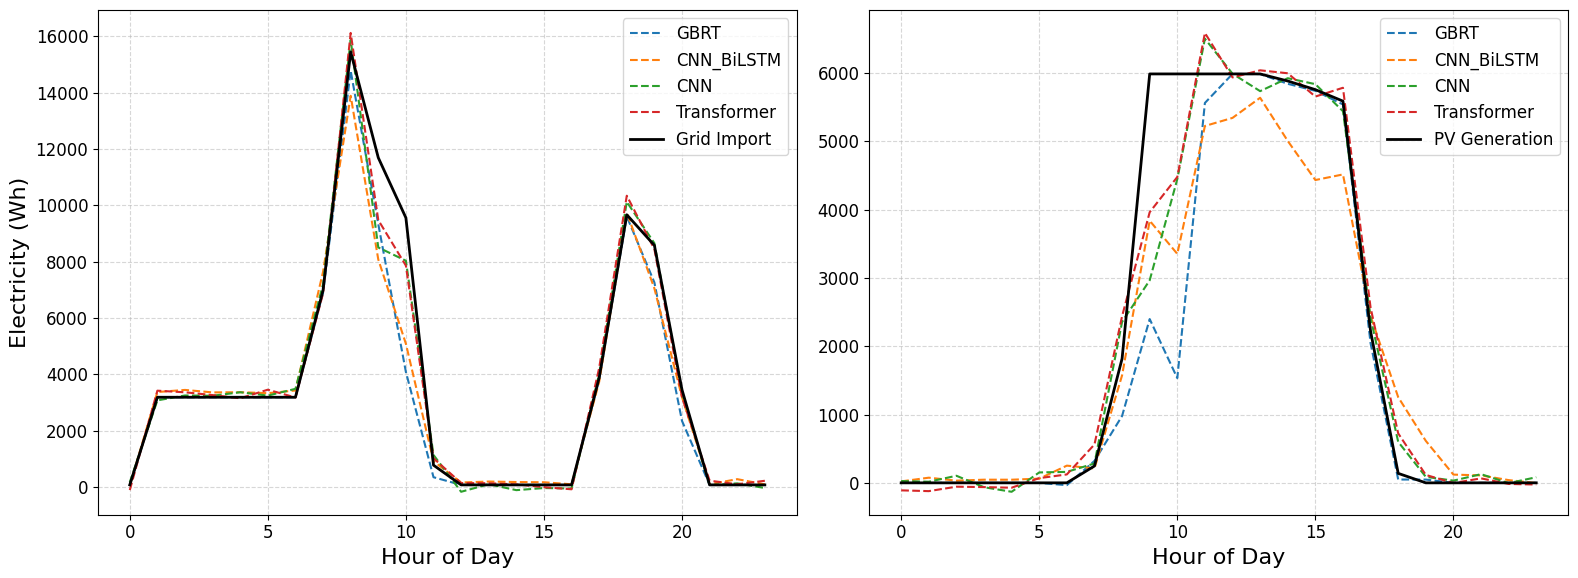

In [38]:
import matplotlib.pyplot as plt

# Set global font sizes
plt.rcParams.update({'font.size': 14})

day = 80  # Day you want to visualize

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

# --- Plot for Grid Import ([:, 0]) ---
pred_gbrt = pred_gbrt.reshape(365, 24, 2)
axes[0].plot(pred_gbrt[day, :, 0], label='GBRT', linestyle='--')
axes[0].plot(pred_cnn_bilstm[day, :, 0], label='CNN_BiLSTM', linestyle='--')
axes[0].plot(pred_cnn[day, :, 0], label='CNN', linestyle='--')
axes[0].plot(pred_transformer[day, :, 0], label='Transformer', linestyle='--')
axes[0].plot(y_test[day, :, 0], label='Grid Import', color='black', linewidth=2)

axes[0].set_xlabel('Hour of Day', fontsize=16)
axes[0].set_ylabel('Electricity (Wh)', fontsize=16)
axes[0].legend(loc='upper right', fontsize=12, frameon=True)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].tick_params(axis='both', labelsize=12)

# --- Plot for PV Generation ([:, 1]) ---
axes[1].plot(pred_gbrt[day, :, 1], label='GBRT', linestyle='--')
axes[1].plot(pred_cnn_bilstm[day, :, 1], label='CNN_BiLSTM', linestyle='--')
axes[1].plot(pred_cnn[day, :, 1], label='CNN', linestyle='--')
axes[1].plot(pred_transformer[day, :, 1], label='Transformer', linestyle='--')
axes[1].plot(y_test[day, :, 1], label='PV Generation', color='black', linewidth=2)

axes[1].set_xlabel('Hour of Day', fontsize=16)
axes[1].legend(loc='upper right', fontsize=12, frameon=True)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.savefig('PV_and_Grid_second.pdf')


In [54]:
pred_gbrt = pred_gbrt.reshape(365,24,2)

# Ensemble

In [ ]:
import numpy as np

# Hour-wise model selection on the validation set (no test-set leakage).
# Selection is decided from validation predictions, then frozen and applied
# to the test set.

def to_seq(a, last):
    return a.reshape(-1, 24, last) if a.ndim != 3 else a

x_val_seq  = to_seq(x_val,  1)
y_val_seq  = to_seq(y_val,  2)
y_test_seq = to_seq(y_test, 2)

val_preds = {
    "GBRT":        gbrt.predict(x_val_seq.reshape(x_val_seq.shape[0], -1)).reshape(-1, 24, 2),
    "CNN_BiLSTM":  model_cnn_bilstm.predict(x_val_seq, verbose=0).reshape(-1, 24, 2),
    "CNN":         model_cnn.predict(x_val_seq, verbose=0).reshape(-1, 24, 2),
    "Transformer": model_transformer.predict(x_val_seq, verbose=0).reshape(-1, 24, 2),
}
test_preds = {
    "GBRT":        pred_gbrt.reshape(-1, 24, 2),
    "CNN_BiLSTM":  pred_cnn_bilstm.reshape(-1, 24, 2),
    "CNN":         pred_cnn.reshape(-1, 24, 2),
    "Transformer": pred_transformer.reshape(-1, 24, 2),
}

def select_hourly(val_preds, y_val):
    sel = {}
    for h in range(24):
        best, best_mae = None, np.inf
        for name, p in val_preds.items():
            m = float(np.mean(np.abs(p[:, h, :] - y_val[:, h, :])))
            if m < best_mae:
                best_mae, best = m, name
        sel[h] = best
    return sel

selection = select_hourly(val_preds, y_val_seq)
print("Selection per hour (from validation):")
for h in range(24):
    print(f"  h={h:02d}: {selection[h]}")

ensemble_preds = np.zeros_like(y_test_seq)
for h in range(24):
    ensemble_preds[:, h, :] = test_preds[selection[h]][:, h, :]
ensemble_flat = ensemble_preds

mae = float(np.mean(np.abs(ensemble_flat - y_test_seq)))
ss_res = float(np.sum((y_test_seq - ensemble_flat) ** 2))
ss_tot = float(np.sum((y_test_seq - y_test_seq.mean()) ** 2))
print(f"\nEnsemble (validation-selected) test MAE: {mae:.2f} Wh")
print(f"Ensemble (validation-selected) test R2:  {1.0 - ss_res / ss_tot:.4f}")


In [ ]:
import numpy as np

# Leave-one-out ablation on the model pool, using the same validation-based
# selection as the previous cell. Reports a simple-averaging baseline too.

def metrics(p, y):
    mae = float(np.mean(np.abs(p - y)))
    ss_res = float(np.sum((y - p) ** 2))
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    r2 = 1.0 - ss_res / ss_tot
    e, eh = float(np.sum(np.abs(y))), float(np.sum(np.abs(p)))
    ret = abs(eh - e) / max(e, eh) if max(e, eh) > 0 else 0.0
    return mae, ret, r2

base_mae, base_ret, base_r2 = metrics(ensemble_flat, y_test_seq)
avg = sum(test_preds.values()) / len(test_preds)
avg_mae, avg_ret, avg_r2 = metrics(avg, y_test_seq)

print(f"{'Variant':32s} {'MAE (Wh)':>10s} {'RET':>7s} {'R2':>7s} {'Delta':>8s}")
print(f"{'Full pool (4 models, ours)':32s} {base_mae:10.2f} {base_ret:7.3f} {base_r2:7.3f} {0.0:+8.2f}")
print(f"{'Simple averaging':32s} {avg_mae:10.2f} {avg_ret:7.3f} {avg_r2:7.3f} {avg_mae - base_mae:+8.2f}")

for drop in list(val_preds.keys()):
    v = {k: vv for k, vv in val_preds.items() if k != drop}
    t = {k: tt for k, tt in test_preds.items() if k != drop}
    sel = select_hourly(v, y_val_seq)
    pred = np.zeros_like(y_test_seq)
    for h in range(24):
        pred[:, h, :] = t[sel[h]][:, h, :]
    m, r, r2 = metrics(pred, y_test_seq)
    print(f"{'minus ' + drop:32s} {m:10.2f} {r:7.3f} {r2:7.3f} {m - base_mae:+8.2f}")


In [31]:
ensemble_flat.shape

(365, 24, 2)

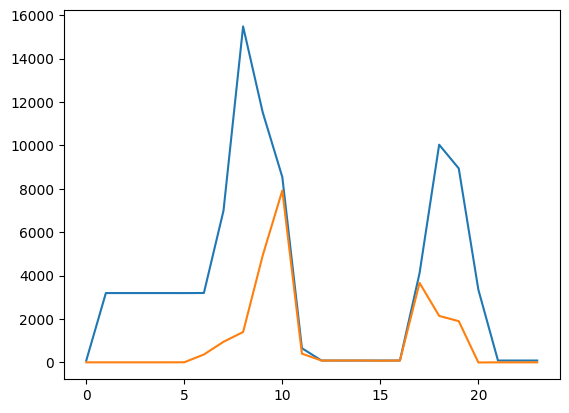

In [34]:
import matplotlib.pyplot as plt
ensemble_flat = ensemble_preds.reshape(365, 24, 2)
plt.plot(ensemble_flat[80])


In [28]:
from sklearn.metrics import mean_absolute_error, r2_score

# Flatten for MAE and R2 computation
y_true_flat = y_test.reshape(-1, 2)
ensemble_flat = ensemble_preds.reshape(-1, 2)

mae = mean_absolute_error(y_true_flat, ensemble_flat)
r2 = r2_score(y_true_flat, ensemble_flat)

print(f"Hourly Ensemble MAE: {mae:.2f}")
print(f"Hourly Ensemble R2: {r2:.4f}")


Hourly Ensemble MAE: 234.42
Hourly Ensemble R2: 0.8449


# GBRT_Second

In [35]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# If y is (n_samples, 24, 2), reshape it to (n_samples, 48)
if y_train.ndim == 3:
    y_train = y_train.reshape((y_train.shape[0], -1))
    y_test = y_test.reshape((y_test.shape[0], -1))

# Flatten x_train if needed (in case it's 3D like (n_samples, 24, 1))
if x_train.ndim == 3:
    x_train = x_train.reshape((x_train.shape[0], -1))
    x_test = x_test.reshape((x_test.shape[0], -1))

# Define GBRT model
gbrt_2 = MultiOutputRegressor(GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
))

# Fit the model
gbrt_2.fit(x_train, y_train)

# Predict
pred = gbrt_2.predict(x_test)

# Evaluate
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print(f"GBRT Test MAE: {mae:.2f} Wh")
print(f"GBRT R² Score: {r2:.4f}")


GBRT Test MAE: 259.05 Wh
GBRT R² Score: 0.4917


In [36]:
pred_gbrt = gbrt_2.predict(x_test.reshape(365,24))
pred = pred.reshape((-1, 24, 2))
def mean_absolute_error(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.mean(np.abs(y_test - pred))

def relative_error_total(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.sum(np.abs(y_test - pred)) / np.sum(np.abs(y_test))

def r_squared(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
    ss_residual = np.sum((y_test - pred) ** 2)
    return 1 - (ss_residual / ss_total)
mae = mean_absolute_error(y_test, pred)
ret = relative_error_total(y_test, pred)
r2 = r_squared(y_test, pred)

print(f"MAE: {mae:.2f} Wh")
print(f"Relative Error in Total: {ret:.4f}")
print(f"R²: {r2:.4f}")

MAE: 259.05 Wh
Relative Error in Total: 0.1083
R²: 0.9451


# BiLSTM_CNN Second

In [28]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, Bidirectional, LSTM, Dense, Dropout, LayerNormalization

# Build CNN + BiLSTM model
def build_cnn_bilstm_model(input_shape=(24, 1)):
    inputs = Input(shape=input_shape)

    # CNN block
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(x)

    # BiLSTM block
    x = Bidirectional(LSTM(64, return_sequences=True))(x)

    x = LayerNormalization()(x)

    # Dense layers
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(2, activation='linear')(x)  # Predict Grid Import and PV Generation

    model = Model(inputs, outputs)
    return model

# Instantiate and compile
model_cnn_bilstm = build_cnn_bilstm_model()
model_cnn_bilstm.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Model Summary
model_cnn_bilstm.summary()

# Example Callbacks
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)

# Example Training
history = model_cnn_bilstm.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=60,
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 24, 1)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ (None, 24, 64)              │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 24, 64)              │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 24, 128)             │          66,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer_normalization                  │ (None, 24, 128)             │             256 │
│ (LayerNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 24, 128)             │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 24, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 24, 2)               │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 95,682 (373.76 KB)

 Trainable params: 95,682 (373.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 7297234.0000 - mae: 1462.5629 - val_loss: 13270720.0000 - val_mae: 2174.9722 - learning_rate: 0.0010
Epoch 2/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 5554377.5000 - mae: 1414.4109 - val_loss: 8645161.0000 - val_mae: 1871.4243 - learning_rate: 0.0010
Epoch 3/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 3489650.5000 - mae: 1172.3192 - val_loss: 5930823.5000 - val_mae: 1456.8060 - learning_rate: 0.0010
Epoch 4/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 2178388.2500 - mae: 867.6951 - val_loss: 3680958.0000 - val_mae: 1068.6740 - learning_rate: 0.0010
Epoch 5/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 1166914.8750 - mae: 599.0344 - val_loss: 2623329.2500 - val_mae: 853.1887 - learning_rate: 0.0010
Epoch 6/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 720152.6250 - mae: 477.1187 - val_loss: 1941051.1250 - val_mae: 719.5944 - learning_rate: 0.0010
Epoch 7/60
126/126 ━━━━━━━━━━━━━━━━━━━━

In [29]:
import numpy as np
pred_cnn_bilstm = model_cnn_bilstm.predict(x_test)
def mean_absolute_error(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.mean(np.abs(y_test - pred))

def relative_error_total(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.sum(np.abs(y_test - pred)) / np.sum(np.abs(y_test))

def r_squared(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
    ss_residual = np.sum((y_test - pred) ** 2)
    return 1 - (ss_residual / ss_total)
mae = mean_absolute_error(y_test, pred_cnn_bilstm)
ret = relative_error_total(y_test, pred_cnn_bilstm)
r2 = r_squared(y_test, pred_cnn_bilstm)

print(f"MAE: {mae:.2f} Wh")
print(f"Relative Error in Total: {ret:.4f}")
print(f"R²: {r2:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
MAE: 490.70 Wh
Relative Error in Total: 0.2052
R²: 0.9116


# BiLSTM_Attention Second

In [27]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, Dropout, Attention, LayerNormalization, Multiply
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Build BiLSTM + Attention model
def build_bilstm_attention_model(input_shape=(24, 1)):
    inputs = Input(shape=input_shape)

    # BiLSTM layer
    x = Bidirectional(LSTM(64, return_sequences=True))(inputs)

    # Simple Attention
    attention = Attention()([x, x])
    x = Multiply()([x, attention])  # Combine attention output

    x = LayerNormalization()(x)

    # Dense layers after attention
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(2, activation='linear')(x)  # Predict Grid Import and PV Generation

    model = Model(inputs, outputs)
    return model

# Instantiate and compile
model_bilstm_att = build_bilstm_attention_model()
model_bilstm_att.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)

# Model Summary
model_bilstm_att.summary()

# Now fitting the model
history = model_bilstm_att.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=60,
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 24, 1)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional_2           │ (None, 24, 128)        │         33,792 │ input_layer_2[0][0]    │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attention (Attention)     │ (None, 24, 128)        │              0 │ bidirectional_2[0][0], │
│                           │                        │                │ bidirectional_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply (Multiply)       │ (None, 24, 128)        │              0 │ bidirectional_2[0][0], │
│                           │                        │                │ attention[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_2     │ (None, 24, 128)        │            256 │ multiply[0][0]         │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_4 (Dense)           │ (None, 24, 128)        │         16,512 │ layer_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_2 (Dropout)       │ (None, 24, 128)        │              0 │ dense_4[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_5 (Dense)           │ (None, 24, 2)          │            258 │ dropout_2[0][0]        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 50,818 (198.51 KB)

 Trainable params: 50,818 (198.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 7273918.0000 - mae: 1461.4282 - val_loss: 13757148.0000 - val_mae: 2148.8914 - learning_rate: 0.0010
Epoch 2/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 5984150.5000 - mae: 1329.9664 - val_loss: 9608061.0000 - val_mae: 1731.5475 - learning_rate: 0.0010
Epoch 3/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 3468994.5000 - mae: 942.9493 - val_loss: 6296849.0000 - val_mae: 1299.4357 - learning_rate: 0.0010
Epoch 4/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 2173533.0000 - mae: 740.2269 - val_loss: 4725163.0000 - val_mae: 1098.8479 - learning_rate: 0.0010
Epoch 5/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 1374392.3750 - mae: 574.6639 - val_loss: 3262660.5000 - val_mae: 883.8811 - learning_rate: 0.0010
Epoch 6/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 938117.0000 - mae: 476.9810 - val_loss: 2433487.0000 - val_mae: 731.9011 - learning_rate: 0.0010
Epoch 7/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 

In [28]:
import numpy as np
pred_bilstm_att = model_bilstm_att.predict(x_test)
def mean_absolute_error(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.mean(np.abs(y_test - pred))

def relative_error_total(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.sum(np.abs(y_test - pred)) / np.sum(np.abs(y_test))

def r_squared(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
    ss_residual = np.sum((y_test - pred) ** 2)
    return 1 - (ss_residual / ss_total)
mae = mean_absolute_error(y_test, pred_bilstm_att)
ret = relative_error_total(y_test, pred_bilstm_att)
r2 = r_squared(y_test, pred_bilstm_att)

print(f"MAE: {mae:.2f} Wh")
print(f"Relative Error in Total: {ret:.4f}")
print(f"R²: {r2:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
MAE: 383.62 Wh
Relative Error in Total: 0.1604
R²: 0.9421


# LSTM_Second

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Reshape, Input
from tensorflow.keras.optimizers import Adam

# Best parameters from Optuna
lstm_units = 64                 # chosen to match Conv1D num_filters
dense_units_1 = 239
dense_units_2 = 115
dropout_rate = 0.000622508972511252
learning_rate = 0.00021302694840540722

# Build the model
model_lstm = Sequential()
model_lstm.add(Input(shape=(24, 1)))
model_lstm.add(LSTM(lstm_units, return_sequences=False))
model_lstm.add(Dropout(dropout_rate))
model_lstm.add(Dense(dense_units_1, activation='relu'))
model_lstm.add(Dense(dense_units_2, activation='relu'))
model_lstm.add(Dense(24 * 2, activation='linear'))
model_lstm.add(Reshape((24, 2)))  # Final shape to match (24, 2)

# Compile
model_lstm.compile(
    optimizer=Adam(learning_rate=learning_rate),
    loss='mse',
    metrics=['mae']
)

# Fit
history = model_lstm.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=50,
    batch_size=32,
    verbose=1
)

# Evaluate
loss, mae = model_lstm.evaluate(x_test, y_test)
print(f"LSTM Test Loss: {loss:.4f}, Test MAE: {mae:.4f}")

Epoch 1/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 7305291.5000 - mae: 1458.9667 - val_loss: 16404594.0000 - val_mae: 2376.8792
Epoch 2/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 7089385.5000 - mae: 1428.3960 - val_loss: 14483154.0000 - val_mae: 2199.0376
Epoch 3/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 5517291.5000 - mae: 1252.5720 - val_loss: 10571911.0000 - val_mae: 1821.4550
Epoch 4/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 3410115.7500 - mae: 971.5826 - val_loss: 7560655.5000 - val_mae: 1457.0195
Epoch 5/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 2383120.5000 - mae: 807.5525 - val_loss: 6273373.5000 - val_mae: 1333.6191
Epoch 6/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 2083072.7500 - mae: 779.5002 - val_loss: 5695622.0000 - val_mae: 1294.5692
Epoch 7/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 1877041.3750 - mae: 756.5178 - val_loss: 5333874.0000 - val_mae: 1270.5135
Epoch 8/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s

In [32]:
import numpy as np
pred_lstm = model_lstm.predict(x_test)
def mean_absolute_error(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.mean(np.abs(y_test - pred))

def relative_error_total(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.sum(np.abs(y_test - pred)) / np.sum(np.abs(y_test))

def r_squared(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
    ss_residual = np.sum((y_test - pred) ** 2)
    return 1 - (ss_residual / ss_total)
mae = mean_absolute_error(y_test, pred_lstm)
ret = relative_error_total(y_test, pred_lstm)
r2 = r_squared(y_test, pred_lstm)

print(f"MAE: {mae:.2f} Wh")
print(f"Relative Error in Total: {ret:.4f}")
print(f"R²: {r2:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
MAE: 778.76 Wh
Relative Error in Total: 0.3257
R²: 0.7864


# CNN_Second

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten, Dropout, Reshape, Input
from tensorflow.keras.optimizers import Adam

# Best hyperparameters from Optuna
num_filters = 64
kernel_size = 3
dense_units_1 = 239
dense_units_2 = 115
dropout_rate = 0.000622508972511252
learning_rate = 0.00021302694840540722

# Build the CNN model
model_cnn = Sequential()
model_cnn.add(Input(shape=(24, 1)))  # Input shape: 24 hours × 1 feature
model_cnn.add(Conv1D(filters=num_filters, kernel_size=kernel_size, activation='relu'))
model_cnn.add(Flatten())
model_cnn.add(Dense(dense_units_1, activation='relu'))
model_cnn.add(Dropout(dropout_rate))
model_cnn.add(Dense(dense_units_2, activation='relu'))
model_cnn.add(Dense(24 * 2, activation='linear'))  # 48 output values
model_cnn.add(Reshape((24, 2)))  # Reshape to (24 hours × 2 outputs)

# Compile the model
model_cnn.compile(
    optimizer=Adam(learning_rate=learning_rate),
    loss='mse',
    metrics=['mae']
)

# Train the model
history = model_cnn.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=80,
    batch_size=32,
    verbose=1
)

# Evaluate the model
loss, mae = model_cnn.evaluate(x_test, y_test)
print(f"CNN Test Loss: {loss:.4f}, Test MAE: {mae:.4f}")


Epoch 1/80
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 3035203.7500 - mae: 1052.5289 - val_loss: 1795986.3750 - val_mae: 786.6792
Epoch 2/80
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 352525.9062 - mae: 380.5650 - val_loss: 1082277.7500 - val_mae: 636.4902
Epoch 3/80
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 220989.1875 - mae: 297.5388 - val_loss: 731194.0625 - val_mae: 538.5082
Epoch 4/80
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 161215.9219 - mae: 253.4720 - val_loss: 580727.8750 - val_mae: 482.9258
Epoch 5/80
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 127729.4609 - mae: 226.9135 - val_loss: 546924.8750 - val_mae: 468.4204
Epoch 6/80
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 108077.7812 - mae: 206.9584 - val_loss: 492944.4688 - val_mae: 440.2074
Epoch 7/80
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 91610.6016 - mae: 187.7612 - val_loss: 491857.5000 - val_mae: 436.0389
Epoch 8/80
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 79169.6406 - 

In [31]:
import numpy as np
pred_cnn = model_cnn.predict(x_test)
def mean_absolute_error(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.mean(np.abs(y_test - pred))

def relative_error_total(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.sum(np.abs(y_test - pred)) / np.sum(np.abs(y_test))

def r_squared(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
    ss_residual = np.sum((y_test - pred) ** 2)
    return 1 - (ss_residual / ss_total)
mae = mean_absolute_error(y_test, pred_cnn)
ret = relative_error_total(y_test, pred_cnn)
r2 = r_squared(y_test, pred_cnn)

print(f"MAE: {mae:.2f} Wh")
print(f"Relative Error in Total: {ret:.4f}")
print(f"R²: {r2:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
MAE: 299.06 Wh
Relative Error in Total: 0.1251
R²: 0.9647


# Transformer_Second

In [33]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, MultiHeadAttention, LayerNormalization, Dropout, Reshape, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Best hyperparameters from Optuna
head_size = 32
num_heads = 8
ff_dim = 212
dense_units_1 = 222
dense_units_2 = 102
dropout_rate = 0.34868317866379933
learning_rate = 0.0014875856245174688

# Transformer Encoder Block
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout):
    # Multi-head self-attention
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads)(inputs, inputs)
    x = Dropout(dropout)(x)
    x = LayerNormalization(epsilon=1e-6)(x)
    res = x + inputs  # First residual connection

    # Feed-forward block
    x = Dense(ff_dim, activation="relu")(res)
    x = Dropout(dropout)(x)
    x = Dense(inputs.shape[-1])(x)
    x = LayerNormalization(epsilon=1e-6)(x)

    return x + res  # Second residual connection

# Input: net load for 24 hours
inputs = Input(shape=(24, 1))

# Transformer layer
x = transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout_rate)

# Dense layers
x = Flatten()(x)
x = Dense(dense_units_1, activation="relu")(x)
x = Dense(dense_units_2, activation="relu")(x)
x = Dense(24 * 2, activation="linear")(x)  # 24 time steps × 2 outputs (PV + grid)
outputs = Reshape((24, 2))(x)

# Define model
model_transformer = Model(inputs, outputs)

# Compile
model_transformer.compile(
    optimizer=Adam(learning_rate=learning_rate),
    loss='mse',
    metrics=['mae']
)

# Fit the model
history = model_transformer.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=60,
    batch_size=32,
    verbose=1
)

# Evaluate
loss, mae = model_transformer.evaluate(x_test, y_test)
print(f"Transformer Test Loss: {loss:.4f}, Test MAE: {mae:.4f}")


Epoch 1/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 1878054.1250 - mae: 793.8016 - val_loss: 1073305.7500 - val_mae: 621.9144
Epoch 2/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 173317.0625 - mae: 268.7881 - val_loss: 751808.5000 - val_mae: 517.3022
Epoch 3/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 99638.9141 - mae: 201.4429 - val_loss: 530837.1250 - val_mae: 438.0698
Epoch 4/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 70440.1719 - mae: 163.0333 - val_loss: 458475.5000 - val_mae: 401.6163
Epoch 5/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 59658.9180 - mae: 142.9236 - val_loss: 448867.8438 - val_mae: 384.7039
Epoch 6/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 53085.2734 - mae: 132.1943 - val_loss: 415283.8438 - val_mae: 357.1706
Epoch 7/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 50403.7422 - mae: 127.6291 - val_loss: 425346.9688 - val_mae: 363.6398
Epoch 8/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 51793.2227 

In [34]:
import numpy as np
pred_transformer = model_transformer.predict(x_test)
def mean_absolute_error(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.mean(np.abs(y_test - pred))

def relative_error_total(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.sum(np.abs(y_test - pred)) / np.sum(np.abs(y_test))

def r_squared(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
    ss_residual = np.sum((y_test - pred) ** 2)
    return 1 - (ss_residual / ss_total)
mae = mean_absolute_error(y_test, pred_transformer)
ret = relative_error_total(y_test, pred_transformer)
r2 = r_squared(y_test, pred_transformer)

print(f"MAE: {mae:.2f} Wh")
print(f"Relative Error in Total: {ret:.4f}")
print(f"R²: {r2:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
MAE: 270.34 Wh
Relative Error in Total: 0.1131
R²: 0.9720


# Hybrid_Second

In [25]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, Dense, Dropout, LayerNormalization,
    MultiHeadAttention, Add
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# --- Transformer block ---
def transformer_block(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1):
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=head_size)(x, x)
    attn_output = Dropout(dropout)(attn_output)
    out1 = Add()([x, attn_output])
    out1 = LayerNormalization(epsilon=1e-6)(out1)

    ff_output = Dense(ff_dim, activation="relu")(out1)
    ff_output = Dropout(dropout)(ff_output)
    ff_output = Dense(x.shape[-1])(ff_output)
    out2 = Add()([out1, ff_output])
    return LayerNormalization(epsilon=1e-6)(out2)

# --- Build the CNN + Transformer hybrid model ---
def build_cnn_transformer_model(input_shape=(24, 1)):
    inputs = Input(shape=input_shape)

    # CNN block
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(x)

    # Transformer block
    x = transformer_block(x, head_size=32, num_heads=4, ff_dim=128, dropout=0.1)

    # Dense layers
    x = Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = Dropout(0.2)(x)
    x = Dense(2, activation='linear')(x)  # Output: 2 values per hour

    outputs = x
    return Model(inputs, outputs)

# --- Instantiate and compile ---
model_hy = build_cnn_transformer_model()
model_hy.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

# --- Setup Callbacks ---
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
    ModelCheckpoint('best_hybrid_model.keras', monitor='val_loss', save_best_only=True, verbose=1)

]

# --- Model summary ---
model_hy.summary()

# --- Fit (example) ---
# history = model_hy.fit(
#     x_train, y_train,
#     validation_data=(x_val, y_val),
#     epochs=100,
#     batch_size=32,
#     callbacks=callbacks
# )


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, 24, 1)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_4 (Conv1D)         │ (None, 24, 64)         │            256 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_5 (Conv1D)         │ (None, 24, 64)         │         12,352 │ conv1d_4[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention_3    │ (None, 24, 64)         │         33,216 │ conv1d_5[0][0],        │
│ (MultiHeadAttention)      │                        │                │ conv1d_5[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_12 (Dropout)      │ (None, 24, 64)         │              0 │ multi_head_attention_… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_6 (Add)               │ (None, 24, 64)         │              0 │ conv1d_5[0][0],        │
│                           │                        │                │ dropout_12[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_6     │ (None, 24, 64)         │            128 │ add_6[0][0]            │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_13 (Dense)          │ (None, 24, 128)        │          8,320 │ layer_normalization_6… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_13 (Dropout)      │ (None, 24, 128)        │              0 │ dense_13[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_14 (Dense)          │ (None, 24, 64)         │          8,256 │ dropout_13[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_7 (Add)               │ (None, 24, 64)         │              0 │ layer_normalization_6… │
│                           │                        │                │ dense_14[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_7     │ (None, 24, 64)         │            128 │ add_7[0][0]            │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_15 (Dense)          │ (None, 24, 128)        │          8,320 │ layer_normalization_7… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_14 (Dropout)      │ (None, 24, 128)        │              0 │ dense_15[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_16 (Dense)          │ (None, 24, 2)          │            258 │ dropout_14[0][0]       │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 71,234 (278.26 KB)

 Trainable params: 71,234 (278.26 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
history = model_hy.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=60, batch_size=32)

Epoch 1/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - loss: 7102622.5000 - mae: 1433.9536 - val_loss: 15406363.0000 - val_mae: 2340.7898
Epoch 2/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 6192685.5000 - mae: 1409.0221 - val_loss: 11485932.0000 - val_mae: 2139.2092
Epoch 3/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 4260168.5000 - mae: 1281.4255 - val_loss: 8544462.0000 - val_mae: 1904.9587
Epoch 4/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 3092041.2500 - mae: 1101.2382 - val_loss: 5801671.5000 - val_mae: 1479.7156
Epoch 5/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 1960693.8750 - mae: 799.1588 - val_loss: 3828523.5000 - val_mae: 1094.3781
Epoch 6/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 1135924.5000 - mae: 555.4706 - val_loss: 2668066.5000 - val_mae: 890.5237
Epoch 7/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 768197.0625 - mae: 468.0198 - val_loss: 2892338.2500 - val_mae: 911.3535
Epoch 8/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 24

In [27]:
import numpy as np
pred_hy = model_hy.predict(x_test)
def mean_absolute_error(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.mean(np.abs(y_test - pred))

def relative_error_total(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.sum(np.abs(y_test - pred)) / np.sum(np.abs(y_test))

def r_squared(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
    ss_residual = np.sum((y_test - pred) ** 2)
    return 1 - (ss_residual / ss_total)
mae = mean_absolute_error(y_test, pred_hy)
ret = relative_error_total(y_test, pred_hy)
r2 = r_squared(y_test, pred_hy)

print(f"MAE: {mae:.2f} Wh")
print(f"Relative Error in Total: {ret:.4f}")
print(f"R²: {r2:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
MAE: 394.56 Wh
Relative Error in Total: 0.1650
R²: 0.9086


In [36]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, MultiHeadAttention, LayerNormalization, Dropout, Reshape
from tensorflow.keras.models import Model

# Transformer Block
def transformer_encoder(inputs, head_size=64, num_heads=4, ff_dim=128, dropout=0.1):
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads)(inputs, inputs)
    x = Dropout(dropout)(x)
    x = LayerNormalization(epsilon=1e-6)(x)
    res = x + inputs  # Residual connection

    x = Dense(ff_dim, activation="relu")(res)
    x = Dropout(dropout)(x)
    x = Dense(inputs.shape[-1])(x)
    x = LayerNormalization(epsilon=1e-6)(x)

    return x + res  # Another residual connection

# Model Definition
inputs = Input(shape=(24, 1))  # 24-hour sequences

# Apply Transformer layers
x = transformer_encoder(inputs)
x = transformer_encoder(x)  # Stack another Transformer layer
x = tf.keras.layers.Flatten()(x)
x = Dense(128, activation="relu")(x)
x = Dense(64, activation="relu")(x)
x = Dense(24 * 2, activation="linear")(x)  # Predict next 24 hours, 2 outputs (PV + network)
outputs = Reshape((24, 2))(x)

# Define model
model_transformer = Model(inputs, outputs)

# Compile
model_transformer.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train
model_transformer.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=100, batch_size=32)

# Evaluate
loss, mae = model_transformer.evaluate(x_test, y_test)
print(f"Test Loss: {loss}, Test MAE: {mae}")


Epoch 1/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 2913570.2500 - mae: 1015.5636 - val_loss: 1497564.3750 - val_mae: 734.1971
Epoch 2/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 286619.4062 - mae: 336.8504 - val_loss: 842594.6875 - val_mae: 566.4111
Epoch 3/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 175689.3125 - mae: 265.4747 - val_loss: 628303.0000 - val_mae: 491.2416
Epoch 4/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 123061.4688 - mae: 221.5350 - val_loss: 581498.6875 - val_mae: 462.5143
Epoch 5/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 101470.9219 - mae: 199.1494 - val_loss: 628452.5625 - val_mae: 466.5220
Epoch 6/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 83665.4062 - mae: 178.7308 - val_loss: 529160.7500 - val_mae: 419.4709
Epoch 7/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 74038.0234 - mae: 164.4689 - val_loss: 546471.8750 - val_mae: 426.8852
Epoch 8/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss

# Eval Second

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import calendar

# Your predictions (all shaped: [365, 24, 2])
models = {
    "GBRT": pred_gbrt,
    "CNN_BiLSTM": pred_cnn_bilstm,
    "CNN": pred_cnn,
    "Transformer": pred_transformer
}

# Ground truth
y_true = y_test  # shape: (365, 24, 2)

# Month indexing helper (non-leap year)
days_in_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
month_indices = np.repeat(np.arange(12), days_in_month)

# R² function
def r_squared(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    ss_total = np.sum((y_true - np.mean(y_true)) ** 2)
    ss_res = np.sum((y_true - y_pred) ** 2)
    return 1 - (ss_res / ss_total) if ss_total != 0 else 0.0

# Dictionaries to store results
monthly_mae = {name: [] for name in models}
monthly_r2 = {name: [] for name in models}

# Calculate monthly MAE and R²
for month in range(12):
    mask = month_indices == month
    y_m = y_true[mask]  # shape: (days_in_month, 24, 2)
    for name, pred in models.items():
        p_m = pred[mask]
        y_flat = y_m.reshape(-1)
        p_flat = p_m.reshape(-1)
        monthly_mae[name].append(np.mean(np.abs(y_flat - p_flat)))
        monthly_r2[name].append(r_squared(y_flat, p_flat))


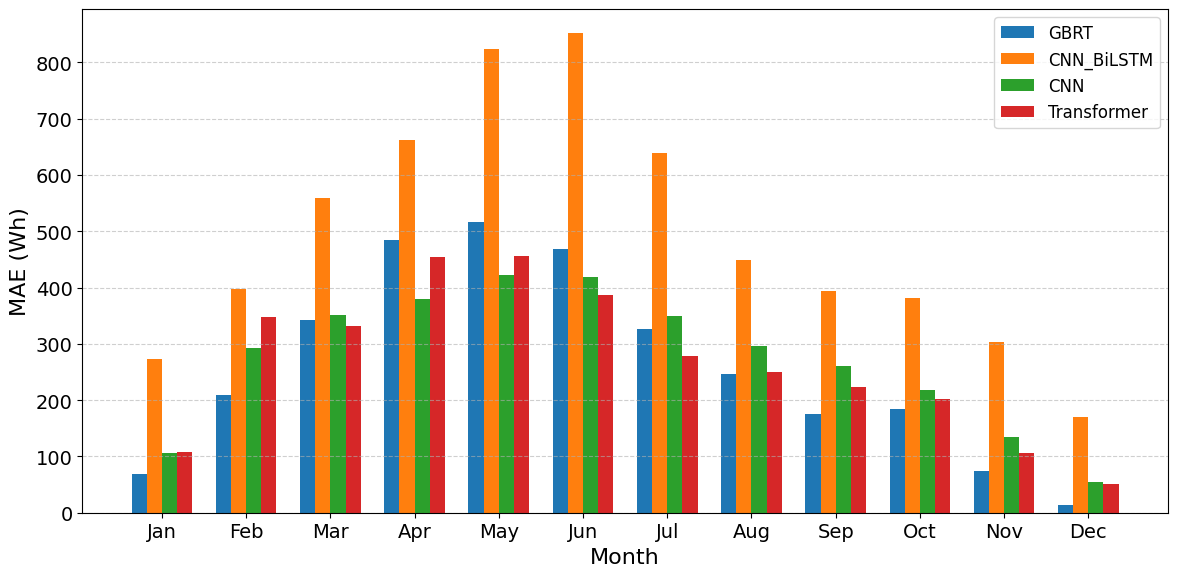

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import calendar

labels = [calendar.month_abbr[i + 1] for i in range(12)]
x = np.arange(len(labels))
width = 0.18
models = list(monthly_mae.keys())

# Set global font sizes
plt.rcParams.update({'font.size': 14})

# Create single plot for MAE
fig, ax = plt.subplots(figsize=(12, 6))

# --- Plot MAE ---
for i, model in enumerate(models):
    ax.bar(x + i * width, monthly_mae[model], width, label=model)

ax.set_ylabel('MAE (Wh)', fontsize=16)
ax.set_xlabel('Month', fontsize=16)
ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels(labels, fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.grid(True, axis='y', linestyle='--', alpha=0.6)

# --- Legend inside the plot (top-right corner) ---
ax.legend(loc='upper right', fontsize=12, frameon=True)

# Adjust layout and save
plt.tight_layout()
plt.savefig('compar_ex2.pdf')
plt.show()


In [125]:
def mean_absolute_error(y_test, pred):
    y_test, pred = np.array(y_test[:,:,1]), np.array(pred[:,:,1])
    return np.mean(np.abs(y_test - pred))

def relative_error_total(y_test, pred):
    y_test, pred = np.array(y_test), np.array(pred)
    return np.sum(np.abs(y_test - pred)) / np.sum(y_test)

def r_squared(y_test, pred):
    y_test, pred = np.array(y_test), np.array(pred)
    ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
    ss_residual = np.sum((y_test - pred) ** 2)
    return 1 - (ss_residual / ss_total)

# Example usage
mae = mean_absolute_error(y_test, pred)
ret = relative_error_total(y_test, pred)
r2 = r_squared(y_test, pred)

print(f"MAE: {mae:.2f} Wh")
print(f"Relative Error in Total: {ret:.4f}")
print(f"R²: {r2:.4f}")

MAE: 291.23 Wh
Relative Error in Total: 0.1278
R²: 0.9552


In [39]:
def mean_absolute_error(y_test, pred):
    y_test, pred = np.array(y_test[:,:,1]), np.array(pred[:,:,1])
    return np.mean(np.abs(y_test - pred))

def relative_error_total(y_test, pred):
    y_test, pred = np.array(y_test), np.array(pred)
    return np.sum(np.abs(y_test - pred)) / np.sum(y_test)

def r_squared(y_test, pred):
    y_test, pred = np.array(y_test), np.array(pred)
    ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
    ss_residual = np.sum((y_test - pred) ** 2)
    return 1 - (ss_residual / ss_total)

# Example usage
mae = mean_absolute_error(y_test, pred)
ret = relative_error_total(y_test, pred)
r2 = r_squared(y_test, pred)

print(f"MAE: {mae:.2f} Wh")
print(f"Relative Error in Total: {ret:.4f}")
print(f"R²: {r2:.4f}")

MAE: 264.40 Wh
Relative Error in Total: 0.1171
R²: 0.9674


**PV-Battery**

In [7]:
import pandas as pd
import glob

# Path to CSV files
csv_files = glob.glob("/kaggle/input/pv-battery/pv-bat*.csv")

# Create an empty DataFrame
dataset = pd.DataFrame()

# Read each CSV and add it as a separate column
dataframes = []
for file in csv_files:
    df = pd.read_csv(file, index_col=0)  # Remove the index column
    column_name = file.split('.')[0][-3:]  # Use the last 3 characters of the file name as column name
    df.rename(columns={df.columns[0]: column_name}, inplace=True)
    df[(df[column_name] > -0.01) & (df[column_name] < 0.01)] = 0  # Replace values between -0.01 and 0.01 with 0
    dataframes.append(df)

# Concatenate along columns
dataset = pd.concat(dataframes, axis=1)

# Display the first few rows
print(dataset.head())


            at4  at9  t10  at5  at6  at8  t13  at1  at3  at2  t11  at7  t12
Time stamp                                                                 
1           0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
2           0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
3           0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
4           0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
5           0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0


In [3]:
dataset.head(24)

,at4,at9,t10,at5,at6,at8,t13,at1,at3,at2,t11,at7,t12
Time stamp,,,,,,,,,,,,,
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [8]:
dataset_uni= pd.read_csv('/kaggle/input/dataset-unisex1/dataset_final_unix.csv',index_col = 'Unnamed: 0')
dataset_uni.drop(['timestamp','SAM'],axis =1 , inplace = True)

In [9]:
dataset = dataset.reset_index(drop=True)

In [10]:
new_dataset = dataset_uni.loc[:, dataset_uni.columns.str.contains(r'\d$')]


In [11]:
dataset = dataset[0:8760]


In [12]:
import pandas as pd

# Let's assume new_dataset and dataset are already defined
# Create a function to get the number at the end of a column name
def get_column_number(col_name):
    return int(''.join(filter(str.isdigit, col_name.split()[-1])))

# Create dictionaries mapping the number to column names
new_cols = {get_column_number(col): col for col in new_dataset.columns}
old_cols = {get_column_number(col): col for col in dataset.columns}

# Sort keys to maintain order (1 to 13)
sorted_keys = sorted(set(new_cols.keys()) & set(old_cols.keys()))

# Create a new DataFrame with the result of the subtraction
result = pd.DataFrame()

for key in sorted_keys:
    col_new = new_cols[key]
    col_old = old_cols[key]
    result[f"diff_{key}"] = new_dataset[col_new] - dataset[col_old]


In [9]:
result

,diff_1,diff_2,diff_3,diff_4,diff_5,diff_6,diff_7,diff_8,diff_9,diff_10,diff_11,diff_12,diff_13
0,23.415279,23.415279,29.269099,35.122919,40.976739,46.830558,46.830558,52.684378,58.538198,64.392018,70.245838,70.245838,76.099657
1,3133.415279,3133.415279,3139.269099,3145.122919,3150.976739,3156.830558,3156.830558,3162.684378,3168.538198,3174.392018,3180.245838,3180.245838,3186.099657
2,3133.415279,3133.415279,3139.269099,3145.122919,3150.976739,3156.830558,3156.830558,3162.684378,3168.538198,3174.392018,3180.245838,3180.245838,3186.099657
3,3133.415279,3133.415279,3139.269099,3145.122919,3150.976739,3156.830558,3156.830558,3162.684378,3168.538198,3174.392018,3180.245838,3180.245838,3186.099657
4,1344.168215,2066.168215,3139.269099,3145.122919,3150.976739,3156.830558,3156.830558,3162.684378,3168.538198,3174.392018,3180.245838,3180.245838,3186.099657
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,403.521505,403.521505,504.401882,605.282258,878.743280,1332.849462,1332.849462,1786.955645,2241.061828,2695.168011,3088.444700,3147.462254,3601.573246
8756,22.876344,22.876344,28.595430,34.314516,40.033602,45.752688,45.752688,51.471774,57.190860,62.909946,68.629032,68.629032,74.348118
8757,22.876344,22.876344,28.595430,34.314516,40.033602,45.752688,45.752688,51.471774,57.190860,62.909946,68.629032,68.629032,74.348118
8758,22.876344,22.876344,28.595430,34.314516,40.033602,45.752688,45.752688,51.471774,57.190860,62.909946,68.629032,68.629032,74.348118


In [13]:
x_bat = result.values.flatten('F').reshape(-1,1)
x_bat1 = pd.DataFrame(x_bat)
x_bat1.to_csv('x_bat.csv')


In [18]:
y_bat1 = new_dataset.values.flatten('F').reshape(-1,1)
y_bat2 = (sorted_dataset.values.flatten('F').reshape(-1,1))*1000
combined = np.hstack((y_bat1, y_bat2)) 
y_bat= pd.DataFrame(combined)
y_bat.to_csv('y_bat.csv')

In [20]:
y_batt = combined

In [15]:
y_batt[0:24,1]

array([  0.    ,   0.    ,   0.    ,   0.    ,   0.    ,   0.    ,
         0.    ,   0.    ,   0.    ,   0.    ,  23.4153,  23.4153,
        23.4153,  23.4153,  23.4153,  23.4153,  23.4153, 377.817 ,
         0.    ,   0.    ,   0.    ,   0.    ,   0.    ,   0.    ])

In [73]:
import os
print(os.listdir('.'))

['X_varried_pvs.csv', 'final_array_df.csv', '.virtual_documents']


In [15]:
import pandas as pd
import re

# Function to extract number from the end of a string
def get_column_number(col):
    match = re.search(r'(\d+)$', col)
    return int(match.group(1)) if match else float('inf')  # use inf to push non-matching columns to the end

# Sort columns based on the extracted number
sorted_columns = sorted(dataset.columns, key=get_column_number)

# Reorder dataset
sorted_dataset = dataset[sorted_columns]


In [25]:

x_train = x_bat[:2*-8760].reshape(4015,24,1)
y_train = y_batt[:2*-8760].reshape(4015,24,2)
x_val = x_bat[2*-8760:-8760].reshape(365,24,1)
y_val = y_batt[2*-8760:-8760].reshape(365,24,2)
x_test = x_bat[-8760:].reshape(365,24,1)
y_test = y_batt[-8760:].reshape(365,24,2)

# GBRT_Third

In [22]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# If y is (n_samples, 24, 2), reshape it to (n_samples, 48)
if y_train.ndim == 3:
    y_train = y_train.reshape((y_train.shape[0], -1))
    y_test = y_test.reshape((y_test.shape[0], -1))

# Flatten x_train if needed (in case it's 3D like (n_samples, 24, 1))
if x_train.ndim == 3:
    x_train = x_train.reshape((x_train.shape[0], -1))
    x_test = x_test.reshape((x_test.shape[0], -1))

# Define GBRT model
gbrt = MultiOutputRegressor(GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
))

# Fit the model
gbrt.fit(x_train, y_train)

# Predict
pred = gbrt.predict(x_test)

# Evaluate
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print(f"GBRT Test MAE: {mae:.2f} Wh")
print(f"GBRT R² Score: {r2:.4f}")


GBRT Test MAE: 300.52 Wh
GBRT R² Score: 0.6884


In [23]:
pred_gbrt = gbrt.predict(x_test.reshape(365,24))
pred = pred.reshape((-1, 24, 2))
def mean_absolute_error(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.mean(np.abs(y_test - pred))

def relative_error_total(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.sum(np.abs(y_test - pred)) / np.sum(np.abs(y_test))

def r_squared(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
    ss_residual = np.sum((y_test - pred) ** 2)
    return 1 - (ss_residual / ss_total)
mae = mean_absolute_error(y_test, pred_gbrt)
ret = relative_error_total(y_test, pred_gbrt)
r2 = r_squared(y_test, pred_gbrt)

print(f"MAE: {mae:.2f} Wh")
print(f"Relative Error in Total: {ret:.4f}")
print(f"R²: {r2:.4f}")

MAE: 300.52 Wh
Relative Error in Total: 0.1512
R²: 0.9302


# CNN_BiLSTM Third

In [26]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, Bidirectional, LSTM, Dense, Dropout, LayerNormalization

# Build CNN + BiLSTM model
def build_cnn_bilstm_model(input_shape=(24, 1)):
    inputs = Input(shape=input_shape)

    # CNN block
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(x)

    # BiLSTM block
    x = Bidirectional(LSTM(64, return_sequences=True))(x)

    x = LayerNormalization()(x)

    # Dense layers
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(2, activation='linear')(x)  # Predict Grid Import and PV Generation

    model = Model(inputs, outputs)
    return model

# Instantiate and compile
model_cnn_bilstm = build_cnn_bilstm_model()
model_cnn_bilstm.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Model Summary
model_cnn_bilstm.summary()

# Example Callbacks
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)

# Example Training
history = model_cnn_bilstm.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=60,
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 24, 1)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 24, 64)              │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 24, 64)              │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 24, 128)             │          66,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer_normalization_1                │ (None, 24, 128)             │             256 │
│ (LayerNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 24, 128)             │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 24, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 24, 2)               │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 95,682 (373.76 KB)

 Trainable params: 95,682 (373.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - loss: 5688506.0000 - mae: 1140.9032 - val_loss: 11189436.0000 - val_mae: 1756.7949 - learning_rate: 0.0010
Epoch 2/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 4288395.0000 - mae: 1021.0303 - val_loss: 6883857.5000 - val_mae: 1278.4691 - learning_rate: 0.0010
Epoch 3/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 2183619.5000 - mae: 643.7725 - val_loss: 4576723.0000 - val_mae: 973.1525 - learning_rate: 0.0010
Epoch 4/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 1270123.7500 - mae: 504.5627 - val_loss: 2861317.7500 - val_mae: 781.0809 - learning_rate: 0.0010
Epoch 5/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 807020.8750 - mae: 420.6602 - val_loss: 2040600.2500 - val_mae: 637.3046 - learning_rate: 0.0010
Epoch 6/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 554637.0000 - mae: 346.3539 - val_loss: 1356521.5000 - val_mae: 532.2580 - learning_rate: 0.0010
Epoch 7/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 

In [27]:
import numpy as np
pred_cnn_bilstm = model_cnn_bilstm.predict(x_test)
def mean_absolute_error(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.mean(np.abs(y_test - pred))

def relative_error_total(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.sum(np.abs(y_test - pred)) / np.sum(np.abs(y_test))

def r_squared(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
    ss_residual = np.sum((y_test - pred) ** 2)
    return 1 - (ss_residual / ss_total)
mae = mean_absolute_error(y_test, pred_cnn_bilstm)
ret = relative_error_total(y_test, pred_cnn_bilstm)
r2 = r_squared(y_test, pred_cnn_bilstm)

print(f"MAE: {mae:.2f} Wh")
print(f"Relative Error in Total: {ret:.4f}")
print(f"R²: {r2:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
MAE: 394.51 Wh
Relative Error in Total: 0.1985
R²: 0.9163


# LSTM_Third

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Reshape, Input
from tensorflow.keras.optimizers import Adam

# Best parameters from Optuna
lstm_units = 64                 # chosen to match Conv1D num_filters
dense_units_1 = 239
dense_units_2 = 115
dropout_rate = 0.000622508972511252
learning_rate = 0.00021302694840540722

# Build the model
model_lstm = Sequential()
model_lstm.add(Input(shape=(24, 1)))
model_lstm.add(LSTM(lstm_units, return_sequences=False))
model_lstm.add(Dropout(dropout_rate))
model_lstm.add(Dense(dense_units_1, activation='relu'))
model_lstm.add(Dense(dense_units_2, activation='relu'))
model_lstm.add(Dense(24 * 2, activation='linear'))
model_lstm.add(Reshape((24, 2)))  # Final shape to match (24, 2)

# Compile
model_lstm.compile(
    optimizer=Adam(learning_rate=learning_rate),
    loss='mse',
    metrics=['mae']
)

# Fit
history = model_lstm.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=50,
    batch_size=32,
    verbose=1
)

# Evaluate
loss, mae = model_lstm.evaluate(x_test, y_test)
print(f"LSTM Test Loss: {loss:.4f}, Test MAE: {mae:.4f}")

Epoch 1/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 5747790.0000 - mae: 1144.8209 - val_loss: 13999121.0000 - val_mae: 1973.9060
Epoch 2/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 5377261.0000 - mae: 1098.9426 - val_loss: 12149545.0000 - val_mae: 1798.6183
Epoch 3/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 4093129.7500 - mae: 945.9937 - val_loss: 8889045.0000 - val_mae: 1457.2517
Epoch 4/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 2431032.2500 - mae: 689.7006 - val_loss: 6521436.0000 - val_mae: 1158.7131
Epoch 5/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 1647522.0000 - mae: 548.1052 - val_loss: 5382067.0000 - val_mae: 1074.5609
Epoch 6/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 1288774.5000 - mae: 516.8249 - val_loss: 4572171.0000 - val_mae: 1010.3074
Epoch 7/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 1001493.8750 - mae: 472.1553 - val_loss: 3886118.5000 - val_mae: 943.0471
Epoch 8/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 17

In [22]:
import numpy as np
pred_lstm = model_lstm.predict(x_test)
def mean_absolute_error(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.mean(np.abs(y_test - pred))

def relative_error_total(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.sum(np.abs(y_test - pred)) / np.sum(np.abs(y_test))

def r_squared(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
    ss_residual = np.sum((y_test - pred) ** 2)
    return 1 - (ss_residual / ss_total)
mae = mean_absolute_error(y_test, pred_lstm)
ret = relative_error_total(y_test, pred_lstm)
r2 = r_squared(y_test, pred_lstm)

print(f"MAE: {mae:.2f} Wh")
print(f"Relative Error in Total: {ret:.4f}")
print(f"R²: {r2:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
MAE: 577.59 Wh
Relative Error in Total: 0.2906
R²: 0.8517


# CNN_Third

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten, Dropout, Reshape, Input
from tensorflow.keras.optimizers import Adam

# Best hyperparameters from Optuna
num_filters = 64
kernel_size = 3
dense_units_1 = 239
dense_units_2 = 115
dropout_rate = 0.000622508972511252
learning_rate = 0.00021302694840540722

# Build the CNN model
model_cnn = Sequential()
model_cnn.add(Input(shape=(24, 1)))  # Input shape: 24 hours × 1 feature
model_cnn.add(Conv1D(filters=num_filters, kernel_size=kernel_size, activation='relu'))
model_cnn.add(Flatten())
model_cnn.add(Dense(dense_units_1, activation='relu'))
model_cnn.add(Dropout(dropout_rate))
model_cnn.add(Dense(dense_units_2, activation='relu'))
model_cnn.add(Dense(24 * 2, activation='linear'))  # 48 output values
model_cnn.add(Reshape((24, 2)))  # Reshape to (24 hours × 2 outputs)

# Compile the model
model_cnn.compile(
    optimizer=Adam(learning_rate=learning_rate),
    loss='mse',
    metrics=['mae']
)

# Train the model
history = model_cnn.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=60,
    batch_size=32,
    verbose=1
)

# Evaluate the model
loss, mae = model_cnn.evaluate(x_test, y_test)
print(f"CNN Test Loss: {loss:.4f}, Test MAE: {mae:.4f}")


Epoch 1/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 2756533.0000 - mae: 958.9604 - val_loss: 1625527.8750 - val_mae: 804.7531
Epoch 2/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 356896.6250 - mae: 355.0609 - val_loss: 1145982.5000 - val_mae: 675.7537
Epoch 3/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 237736.7500 - mae: 274.6897 - val_loss: 852338.3125 - val_mae: 566.2304
Epoch 4/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 189350.0469 - mae: 225.1964 - val_loss: 734958.8125 - val_mae: 493.2985
Epoch 5/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 166693.4062 - mae: 196.0778 - val_loss: 641897.7500 - val_mae: 437.5884
Epoch 6/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 156431.2344 - mae: 183.0284 - val_loss: 620217.2500 - val_mae: 428.5349
Epoch 7/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 155052.6562 - mae: 175.0373 - val_loss: 575215.1875 - val_mae: 420.7483
Epoch 8/60
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 152341.6875 -

In [29]:
import numpy as np
pred_cnn = model_cnn.predict(x_test)
def mean_absolute_error(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.mean(np.abs(y_test - pred))

def relative_error_total(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.sum(np.abs(y_test - pred)) / np.sum(np.abs(y_test))

def r_squared(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
    ss_residual = np.sum((y_test - pred) ** 2)
    return 1 - (ss_residual / ss_total)
mae = mean_absolute_error(y_test, pred_cnn)
ret = relative_error_total(y_test, pred_cnn)
r2 = r_squared(y_test, pred_cnn)

print(f"MAE: {mae:.2f} Wh")
print(f"Relative Error in Total: {ret:.4f}")
print(f"R²: {r2:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
MAE: 316.21 Wh
Relative Error in Total: 0.1591
R²: 0.9609


# Transformer_Third

In [25]:
import optuna
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, MultiHeadAttention, LayerNormalization, Dropout, Reshape, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

# Assume x_train, y_train, x_test, y_test are already defined:
# x_train shape: (n_samples, 24, 1)
# y_train shape: (n_samples, 24, 2)

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout):
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads)(inputs, inputs)
    x = Dropout(dropout)(x)
    x = LayerNormalization(epsilon=1e-6)(x)
    res = x + inputs  # Residual connection

    x = Dense(ff_dim, activation="relu")(res)
    x = Dropout(dropout)(x)
    x = Dense(inputs.shape[-1])(x)
    x = LayerNormalization(epsilon=1e-6)(x)
    
    return x + res  # Second residual connection

def create_transformer_model(trial):
    # Hyperparameter search space
    head_size = trial.suggest_categorical('head_size', [32, 64, 128])
    num_heads = trial.suggest_categorical('num_heads', [2, 4, 8])
    ff_dim = trial.suggest_int('ff_dim', 64, 256)
    dense_units_1 = trial.suggest_int('dense_units_1', 64, 256)
    dense_units_2 = trial.suggest_int('dense_units_2', 32, 128)
    dropout_rate = trial.suggest_float('dropout_rate', 0.0, 0.4)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)

    inputs = Input(shape=(24, 1))
    x = transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout_rate)
    x = Flatten()(x)
    x = Dense(dense_units_1, activation="relu")(x)
    x = Dense(dense_units_2, activation="relu")(x)
    x = Dense(24 * 2, activation="linear")(x)
    outputs = Reshape((24, 2))(x)

    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse', metrics=['mae'])
    return model

def objective(trial):
    # Train/val split
    x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

    model = create_transformer_model(trial)
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)

    model.fit(
        x_tr, y_tr,
        validation_data=(x_val, y_val),
        epochs=50,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    val_loss, _ = model.evaluate(x_val, y_val, verbose=0)
    return val_loss

# Run Optuna Study
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler())
study.optimize(objective, n_trials=30)

# Best trial info
print("Best Trial:")
for key, value in study.best_trial.params.items():
    print(f"  {key}: {value}")

# Train final model with best parameters
final_model = create_transformer_model(study.best_trial)
final_model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=50, batch_size=32, verbose=1)

# Evaluate final model
loss, mae = final_model.evaluate(x_test, y_test)
print(f"Transformer Test Loss: {loss:.4f}, Test MAE: {mae:.4f}")


[I 2025-10-01 18:52:57,723] A new study created in memory with name: no-name-6d8eb454-883c-4912-9d43-ece424ec1fd0
[I 2025-10-01 18:53:50,559] Trial 0 finished with value: 130151.8828125 and parameters: {'head_size': 32, 'num_heads': 2, 'ff_dim': 203, 'dense_units_1': 246, 'dense_units_2': 62, 'dropout_rate': 0.07683101123337553, 'learning_rate': 0.00017523708128378611}. Best is trial 0 with value: 130151.8828125.
[W 2025-10-01 18:54:06,795] Trial 1 failed with parameters: {'head_size': 128, 'num_heads': 4, 'ff_dim': 86, 'dense_units_1': 90, 'dense_units_2': 88, 'dropout_rate': 0.38510660397458396, 'learning_rate': 0.0007227913869001203} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/optuna/study/_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
  File "<ipython-input-25-08051534b552>", line 55, in objective
    model.fit(
  File "/usr/local/lib/python3.10/dist-packages/keras/

KeyboardInterrupt: 

In [27]:
import numpy as np
pred_transformer = final_model.predict(x_test)
def mean_absolute_error(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.mean(np.abs(y_test - pred))

def relative_error_total(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.sum(np.abs(y_test - pred)) / np.sum(np.abs(y_test))

def r_squared(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
    ss_residual = np.sum((y_test - pred) ** 2)
    return 1 - (ss_residual / ss_total)
mae = mean_absolute_error(y_test, pred_transformer)
ret = relative_error_total(y_test, pred_transformer)
r2 = r_squared(y_test, pred_transformer)

print(f"MAE: {mae:.2f} Wh")
print(f"Relative Error in Total: {ret:.4f}")
print(f"R²: {r2:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
MAE: 374.45 Wh
Relative Error in Total: 0.1884
R²: 0.9547


In [30]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, MultiHeadAttention, LayerNormalization, Dropout, Reshape
from tensorflow.keras.models import Model

# Transformer Block
def transformer_encoder(inputs, head_size=64, num_heads=4, ff_dim=128, dropout=0.1):
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads)(inputs, inputs)
    x = Dropout(dropout)(x)
    x = LayerNormalization(epsilon=1e-6)(x)
    res = x + inputs  # Residual connection

    x = Dense(ff_dim, activation="relu")(res)
    x = Dropout(dropout)(x)
    x = Dense(inputs.shape[-1])(x)
    x = LayerNormalization(epsilon=1e-6)(x)

    return x + res  # Another residual connection

# Model Definition
inputs = Input(shape=(24, 1))  # 24-hour sequences

# Apply Transformer layers
x = transformer_encoder(inputs)
x = transformer_encoder(x)  # Stack another Transformer layer
x = tf.keras.layers.Flatten()(x)
x = Dense(128, activation="relu")(x)
x = Dense(64, activation="relu")(x)
x = Dense(24 * 2, activation="linear")(x)  # Predict next 24 hours, 2 outputs (PV + network)
outputs = Reshape((24, 2))(x)

# Define model
model_transformer = Model(inputs, outputs)

# Compile
model_transformer.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train
model_transformer.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=50, batch_size=32)

# Evaluate
loss, mae = model_transformer.evaluate(x_test, y_test)
print(f"Test Loss: {loss}, Test MAE: {mae}")


Epoch 1/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 2367655.5000 - mae: 863.0134 - val_loss: 1749235.2500 - val_mae: 764.6244
Epoch 2/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 268388.6875 - mae: 296.8755 - val_loss: 1100826.5000 - val_mae: 633.4800
Epoch 3/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 201337.4219 - mae: 230.9360 - val_loss: 839544.4375 - val_mae: 542.2486
Epoch 4/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 182183.6719 - mae: 203.8968 - val_loss: 757177.4375 - val_mae: 506.0035
Epoch 5/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 161150.7344 - mae: 177.7817 - val_loss: 743739.0625 - val_mae: 481.6143
Epoch 6/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 157475.2656 - mae: 171.9421 - val_loss: 664806.6875 - val_mae: 470.1078
Epoch 7/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 153424.0938 - mae: 166.7068 - val_loss: 644459.5000 - val_mae: 447.4687
Epoch 8/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 1428

In [31]:
import numpy as np
pred_transformer = model_transformer.predict(x_test)
def mean_absolute_error(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.mean(np.abs(y_test - pred))

def relative_error_total(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    return np.sum(np.abs(y_test - pred)) / np.sum(np.abs(y_test))

def r_squared(y_test, pred):
    y_test = np.ravel(y_test)
    pred = np.ravel(pred)
    ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
    ss_residual = np.sum((y_test - pred) ** 2)
    return 1 - (ss_residual / ss_total)
mae = mean_absolute_error(y_test, pred_transformer)
ret = relative_error_total(y_test, pred_transformer)
r2 = r_squared(y_test, pred_transformer)

print(f"MAE: {mae:.2f} Wh")
print(f"Relative Error in Total: {ret:.4f}")
print(f"R²: {r2:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
MAE: 311.71 Wh
Relative Error in Total: 0.1568
R²: 0.9589


In [133]:
pred = model_transformer.predict(x_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step


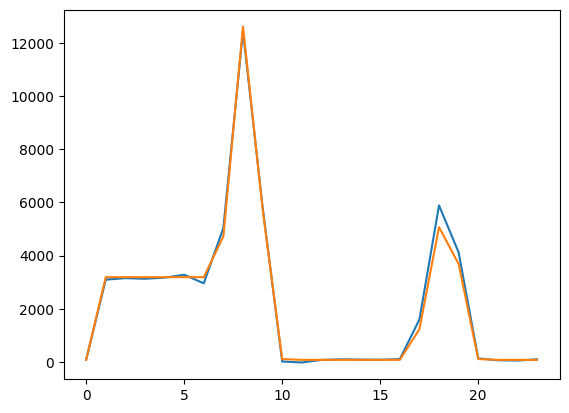

In [134]:
plt.plot(pred[0,:,0])
plt.plot(y_test[0,:,0])

In [137]:
def mean_absolute_error(y_test, pred):
    y_test, pred = np.array(y_test[:,:,1]), np.array(pred[:,:,1])
    return np.mean(np.abs(y_test - pred))

def relative_error_total(y_test, pred):
    y_test, pred = np.array(y_test), np.array(pred)
    return np.sum(np.abs(y_test - pred)) / np.sum(y_test)

def r_squared(y_test, pred):
    y_test, pred = np.array(y_test), np.array(pred)
    ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
    ss_residual = np.sum((y_test - pred) ** 2)
    return 1 - (ss_residual / ss_total)

# Example usage
mae = mean_absolute_error(y_test, pred)
ret = relative_error_total(y_test, pred)
r2 = r_squared(y_test, pred)

print(f"MAE: {mae:.2f} Wh")
print(f"Relative Error in Total: {ret:.4f}")
print(f"R²: {r2:.4f}")

MAE: 339.48 Wh
Relative Error in Total: 0.1922
R²: 0.9417


In [138]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, Dropout, Reshape
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import Huber


# Define the model
model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(0.001), input_shape=(24, 1)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(0.001)),
    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),  # Dropout to prevent overfitting
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(24 * 2, activation='linear'),
    Reshape((24, 2))
])

# Compile with Huber Loss (better for noisy regression)
model.compile(optimizer='adam', loss=Huber(), metrics=['mae'])

# Early Stopping Callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(x_train, y_train, validation_data=(x_test, y_test), 
                    epochs=100, batch_size=32, callbacks=[early_stopping])

# Evaluate the model
loss, mae = model.evaluate(x_test, y_test)
print(f"Test Loss: {loss}, Test MAE: {mae}")


Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 1098.5588 - mae: 1098.7681 - val_loss: 1029.8945 - val_mae: 1030.1733
Epoch 2/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 593.4873 - mae: 593.7670 - val_loss: 858.7736 - val_mae: 859.0496
Epoch 3/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 474.8377 - mae: 475.1133 - val_loss: 748.9307 - val_mae: 749.1945
Epoch 4/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 418.1941 - mae: 418.4561 - val_loss: 680.8342 - val_mae: 681.0869
Epoch 5/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 386.7375 - mae: 386.9806 - val_loss: 760.0928 - val_mae: 760.3270
Epoch 6/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 371.1573 - mae: 371.3826 - val_loss: 734.9316 - val_mae: 735.1559
Epoch 7/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 355.1624 - mae: 355.3734 - val_loss: 796.8495 - val_mae: 797.0502
Epoch 8/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 348.4175 - mae: 348.6126 - val_loss: 712.9368 - val_mae: 7

In [139]:
pred = model.predict(x_test)
def mean_absolute_error(y_test, pred):
    y_test, pred = np.array(y_test[:,:,1]), np.array(pred[:,:,1])
    return np.mean(np.abs(y_test - pred))

def relative_error_total(y_test, pred):
    y_test, pred = np.array(y_test), np.array(pred)
    return np.sum(np.abs(y_test - pred)) / np.sum(y_test)

def r_squared(y_test, pred):
    y_test, pred = np.array(y_test), np.array(pred)
    ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
    ss_residual = np.sum((y_test - pred) ** 2)
    return 1 - (ss_residual / ss_total)

# Example usage
mae = mean_absolute_error(y_test, pred)
ret = relative_error_total(y_test, pred)
r2 = r_squared(y_test, pred)

print(f"MAE: {mae:.2f} Wh")
print(f"Relative Error in Total: {ret:.4f}")
print(f"R²: {r2:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
MAE: 363.48 Wh
Relative Error in Total: 0.2823
R²: 0.8645


In [140]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Reshape

# Define LSTM model
model_lstm = Sequential([
    LSTM(64, activation='relu', return_sequences=True, input_shape=(24, 1)),
    LSTM(32, activation='relu', return_sequences=False),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(24 * 2, activation='linear'),  # Predicts 24 hours of (PV, network)
    Reshape((24, 2))  # Reshape to (24, 2) for output
])

# Compile and train
model_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_lstm.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=50, batch_size=32)


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 4232773.0000 - mae: 997.9106 - val_loss: 4343234.5000 - val_mae: 1144.9000
Epoch 2/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 1358350.1250 - mae: 627.8661 - val_loss: 3145013.7500 - val_mae: 981.6764
Epoch 3/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 846799.8125 - mae: 517.9849 - val_loss: 3059782.7500 - val_mae: 918.1850
Epoch 4/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 721372.7500 - mae: 472.5110 - val_loss: 3180097.0000 - val_mae: 927.7987
Epoch 5/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 728633.1250 - mae: 462.2753 - val_loss: 3125913.2500 - val_mae: 902.0348
Epoch 6/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 683889.6875 - mae: 445.7595 - val_loss: 3043058.7500 - val_mae: 909.6327
Epoch 7/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 681223.5625 - mae: 451.7190 - val_loss: 2856543.0000 - val_mae: 873.9658
Epoch 8/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 724327.93

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import calendar

# Your predictions (all shaped: [365, 24, 2])
models = {
    "GBRT": pred_gbrt,
    "CNN_BiLSTM": pred_cnn_bilstm,
    "CNN": pred_cnn,
    "Transformer": pred_transformer
}

# Ground truth
y_true = y_test  # shape: (365, 24, 2)

# Month indexing helper (non-leap year)
days_in_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
month_indices = np.repeat(np.arange(12), days_in_month)

# R² function
def r_squared(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    ss_total = np.sum((y_true - np.mean(y_true)) ** 2)
    ss_res = np.sum((y_true - y_pred) ** 2)
    return 1 - (ss_res / ss_total) if ss_total != 0 else 0.0

# Dictionaries to store results
monthly_mae = {name: [] for name in models}
monthly_r2 = {name: [] for name in models}

# Calculate monthly MAE and R²
for month in range(12):
    mask = month_indices == month
    y_m = y_true[mask]  # shape: (days_in_month, 24, 2)
    for name, pred in models.items():
        p_m = pred[mask]
        y_flat = y_m.reshape(-1)
        p_flat = p_m.reshape(-1)
        monthly_mae[name].append(np.mean(np.abs(y_flat - p_flat)))
        monthly_r2[name].append(r_squared(y_flat, p_flat))


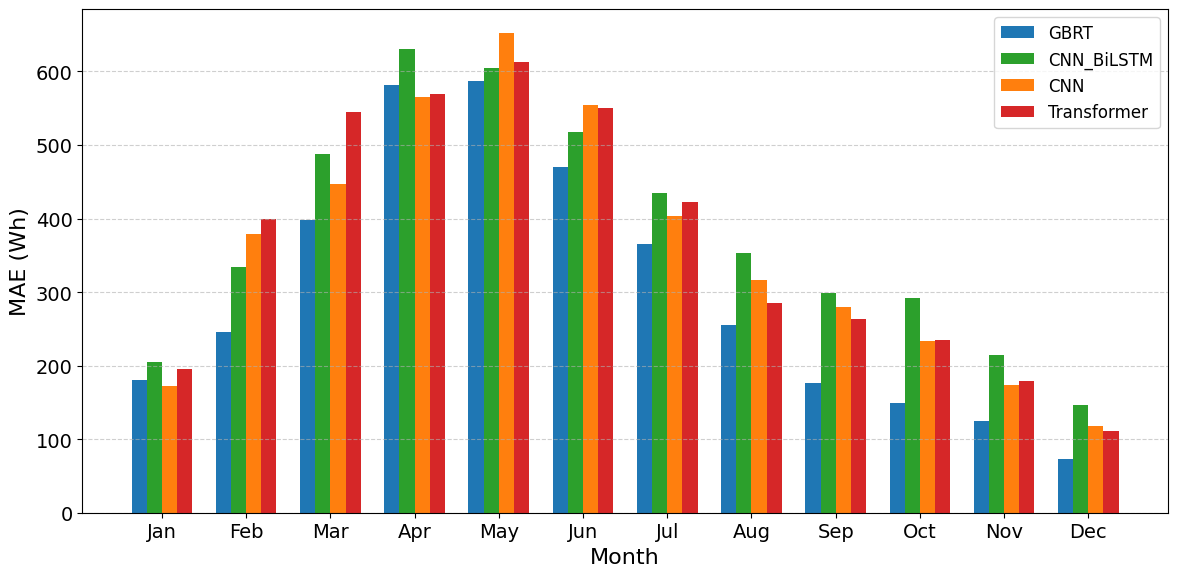

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import calendar

labels = [calendar.month_abbr[i + 1] for i in range(12)]
x = np.arange(len(labels))
width = 0.18
models = list(monthly_mae.keys())

# Set global font sizes
plt.rcParams.update({'font.size': 14})

# Define custom, unique colors for each model
colors = {
    "GBRT": "#1f77b4",        # blue
    "CNN": "#ff7f0e",         # orange
    "CNN_BiLSTM": "#2ca02c",  # green
    "Transformer": "#d62728"  # red
}

# Create single plot for MAE
fig, ax = plt.subplots(figsize=(12, 6))

# --- Plot MAE ---
for i, model in enumerate(models):
    ax.bar(x + i * width, monthly_mae[model], width, label=model, color=colors.get(model, None))

ax.set_ylabel('MAE (Wh)', fontsize=16)
ax.set_xlabel('Month', fontsize=16)
ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels(labels, fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.grid(True, axis='y', linestyle='--', alpha=0.6)

# --- Legend ---
ax.legend(loc='upper right', fontsize=12, frameon=True)

# Adjust layout and save
plt.tight_layout()
plt.savefig('compar_ex3.pdf')



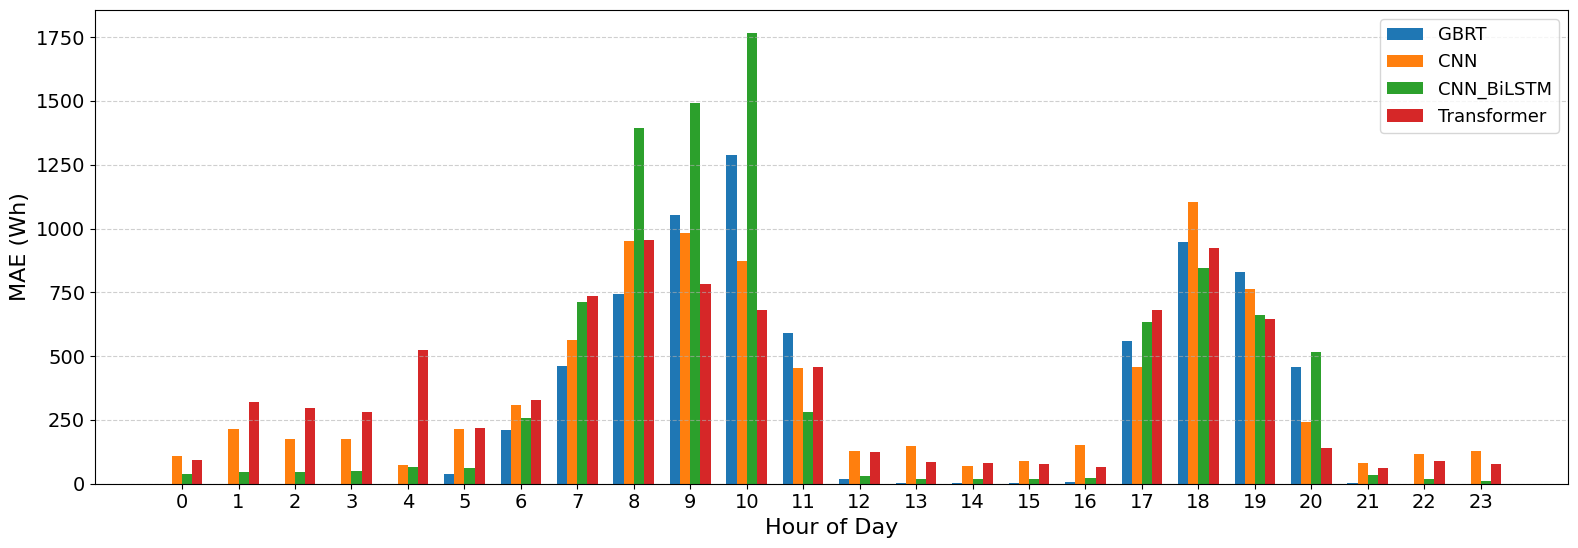

In [33]:
# Make sure predictions are all shaped: (365, 24, 2)
def ensure_3d(pred):
    if pred.ndim == 2 and pred.shape[1] == 48:
        return pred.reshape((-1, 24, 2))
    return pred

# Reshape if needed
pred_gbrt = ensure_3d(pred_gbrt)
pred_lstm = ensure_3d(pred_cnn_bilstm)
pred_cnn = ensure_3d(pred_cnn)
pred_transformer = ensure_3d(pred_transformer)

# Store model predictions
models = {
    "GBRT": pred_gbrt,
    "CNN": pred_cnn,
    "CNN_BiLSTM": pred_cnn_bilstm,
    "Transformer": pred_transformer
}

# Initialize results
hourly_mae_combined = {name: [] for name in models}

# Compute combined MAE for each hour
for hour in range(24):
    y_h = y_test[:, hour, :]  # (365, 2)
    for name, pred in models.items():
        p_h = pred[:, hour, :]  # (365, 2)
        error = np.abs(y_h - p_h)
        mae = np.mean(error)  # average over 365 * 2
        hourly_mae_combined[name].append(mae)
import matplotlib.pyplot as plt
import numpy as np

# Labels for 24 hours
labels = [str(h) for h in range(24)]
x = np.arange(len(labels))
width = 0.18

# Extract model names
model_names = list(hourly_mae_combined.keys())

# Define distinct and consistent colors for each model
colors = {
    "GBRT": "#1f77b4",        # blue
    "CNN": "#ff7f0e",         # orange
    "CNN_BiLSTM": "#2ca02c",  # green
    "Transformer": "#d62728"  # red
}

# Set global font sizes
plt.rcParams.update({'font.size': 14})

# Create figure and axis
fig, ax = plt.subplots(figsize=(16, 6))

# Plot bars for each model
for i, model in enumerate(model_names):
    ax.bar(
        x + i * width,
        hourly_mae_combined[model],
        width,
        label=model,
        color=colors.get(model, '#888888')  # default gray if not found
    )

# Axis labeling and formatting
ax.set_ylabel('MAE (Wh)', fontsize=16)
ax.set_xlabel('Hour of Day', fontsize=16)
ax.set_xticks(x + width * (len(model_names) - 1) / 2)
ax.set_xticklabels(labels, fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.grid(True, axis='y', linestyle='--', alpha=0.6)

# Add legend
ax.legend(loc='upper right', fontsize=13, frameon=True)

# Final layout adjustments and save
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('hourly_compar3.pdf')




In [53]:
!pip install nixtla



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 50.2 MB/s eta 0:00:0000:0100:01


In [60]:
from nixtlats import timegpt


/usr/local/lib/python3.10/dist-packages/nixtlats/__init__.py:5: FutureWarning: This package is deprecated, please install nixtla instead.
  warnings.warn("This package is deprecated, please install nixtla instead.", category=FutureWarning)


ImportError: cannot import name 'timegpt' from 'nixtlats' (/usr/local/lib/python3.10/dist-packages/nixtlats/__init__.py)

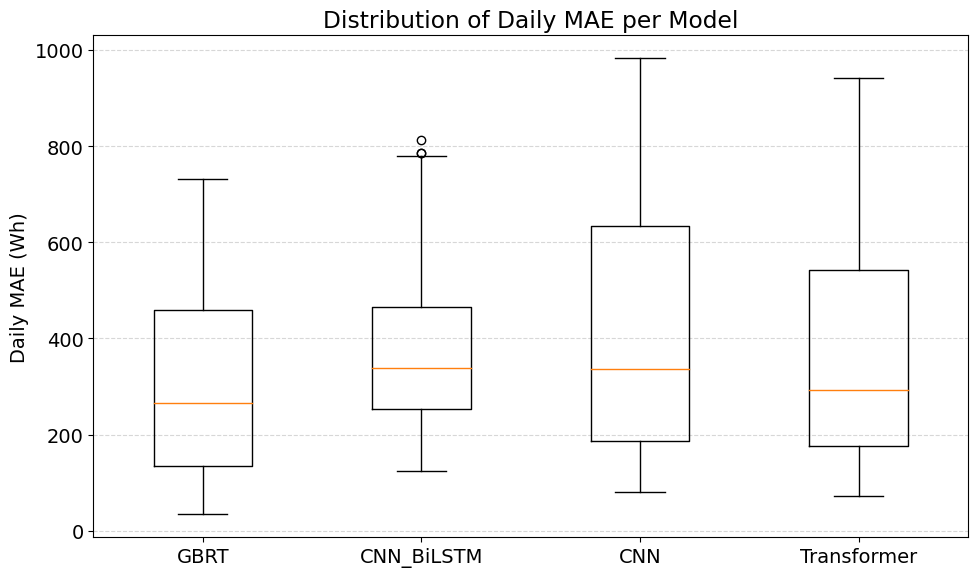

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Function to compute daily MAE
def compute_daily_mae(y_true, y_pred):
    errors = np.abs(y_true - y_pred)  # shape (365, 24, 2)
    daily_mae = errors.mean(axis=(1, 2))  # shape (365,)
    return daily_mae

# Dictionary to store daily MAEs for each model
daily_mae_all = {
    "GBRT": compute_daily_mae(y_test, pred_gbrt),
    "CNN_BiLSTM": compute_daily_mae(y_test, pred_cnn_bilstm),
    "CNN": compute_daily_mae(y_test, pred_cnn),
    "Transformer": compute_daily_mae(y_test, pred_transformer),
}

# Prepare data for box plot
data = [daily_mae_all[model] for model in daily_mae_all]
labels = list(daily_mae_all.keys())

# Plotting
plt.figure(figsize=(10, 6))
plt.boxplot(data, labels=labels, showfliers=True)
plt.ylabel('Daily MAE (Wh)')

plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('daily_mae_boxplot.pdf')



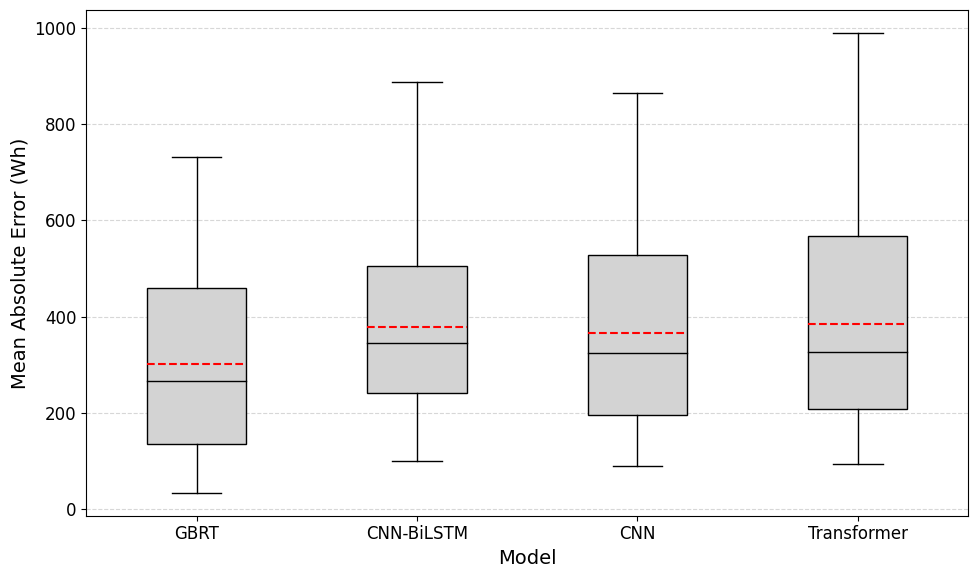

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# --- Function to compute daily MAE across all hours and targets ---
def compute_daily_mae(y_true, y_pred):
    absolute_errors = np.abs(y_true - y_pred)  # shape: (365, 24, 2)
    daily_mae = absolute_errors.mean(axis=(1, 2))  # mean over time and targets
    return daily_mae

# --- Collect daily MAEs for each model ---
daily_mae_per_model = {
    "GBRT": compute_daily_mae(y_test, pred_gbrt),
    "CNN-BiLSTM": compute_daily_mae(y_test, pred_cnn_bilstm),
    "CNN": compute_daily_mae(y_test, pred_cnn),
    "Transformer": compute_daily_mae(y_test, pred_transformer),
}

# --- Prepare data for boxplot ---
box_data = [daily_mae_per_model[model] for model in daily_mae_per_model]
model_labels = list(daily_mae_per_model.keys())

# --- Plot configuration ---
plt.figure(figsize=(10, 6))
box = plt.boxplot(
    box_data,
    labels=model_labels,
    patch_artist=True,
    showmeans=True,
    meanline=True,
    boxprops=dict(facecolor='lightgray', color='black'),
    medianprops=dict(color='black'),
    meanprops=dict(color='red', linestyle='--', linewidth=1.5),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(marker='o', markersize=4, alpha=0.3)
)

# --- Axis labels and font sizes ---
plt.ylabel('Mean Absolute Error (Wh)', fontsize=14)
plt.xlabel('Model', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# --- Grid and layout ---
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('boxplot_daily_mae.pdf', bbox_inches='tight')
plt.show()


In [43]:
ensemble_flat = ensemble_flat.reshape(365,24,2)

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import calendar

# Your predictions (all shaped: [365, 24, 2])
colors = {
    "GBRT": "#1f77b4",         # blue
    "CNN_BiLSTM": "#2ca02c",   # green
    "CNN": "#ff7f0e",          # orange
    "Transformer": "#d62728",  # red
    "Ensemble": "#9467bd"      # purple
}


# Ground truth
y_true = y_test  # shape: (365, 24, 2)

# Month indexing helper (non-leap year)
days_in_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
month_indices = np.repeat(np.arange(12), days_in_month)

# R² function
def r_squared(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    ss_total = np.sum((y_true - np.mean(y_true)) ** 2)
    ss_res = np.sum((y_true - y_pred) ** 2)
    return 1 - (ss_res / ss_total) if ss_total != 0 else 0.0

# Dictionaries to store results
monthly_mae = {name: [] for name in models}
monthly_r2 = {name: [] for name in models}

# Calculate monthly MAE and R²
for month in range(12):
    mask = month_indices == month
    y_m = y_true[mask]  # shape: (days_in_month, 24, 2)
    for name, pred in models.items():
        p_m = pred[mask]
        y_flat = y_m.reshape(-1)
        p_flat = p_m.reshape(-1)
        monthly_mae[name].append(np.mean(np.abs(y_flat - p_flat)))
        monthly_r2[name].append(r_squared(y_flat, p_flat))


In [46]:
import numpy as np
import matplotlib.pyplot as plt
import calendar

# --- Colors for consistent visualization ---
colors = {
    "GBRT": "#1f77b4",         # blue
    "CNN_BiLSTM": "#2ca02c",   # green
    "CNN": "#ff7f0e",          # orange
    "Transformer": "#d62728",  # red
    "Ensemble": "#9467bd"      # purple
}

# --- Ensure predictions are shaped correctly: (365, 24, 2) ---
def ensure_3d(pred):
    if pred.ndim == 2 and pred.shape[1] == 48:
        return pred.reshape((-1, 24, 2))
    return pred

# --- Ensure all model outputs are correctly shaped ---
pred_gbrt = ensure_3d(pred_gbrt)
pred_cnn_bilstm = ensure_3d(pred_cnn_bilstm)
pred_cnn = ensure_3d(pred_cnn)
pred_transformer = ensure_3d(pred_transformer)
ensemble_flat = ensure_3d(ensemble_flat)

# --- Dictionary of models ---
models = {
    "GBRT": pred_gbrt,
    "CNN_BiLSTM": pred_cnn_bilstm,
    "CNN": pred_cnn,
    "Transformer": pred_transformer,
    "Ensemble": ensemble_flat
}

# --- Ground truth ---
y_true = y_test  # shape: (365, 24, 2)

# --- Month indexing helper (non-leap year) ---
days_in_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
month_indices = np.repeat(np.arange(12), days_in_month)

# --- R² function ---
def r_squared(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    ss_total = np.sum((y_true - np.mean(y_true)) ** 2)
    ss_res = np.sum((y_true - y_pred) ** 2)
    return 1 - (ss_res / ss_total) if ss_total != 0 else 0.0

# --- Dictionaries to store results ---
monthly_mae = {name: [] for name in models}
monthly_r2 = {name: [] for name in models}

# --- Calculate monthly MAE and R² for each model ---
for month in range(12):
    mask = month_indices == month
    y_m = y_true[mask]  # shape: (days_in_month, 24, 2)
    for name, pred in models.items():
        p_m = pred[mask]
        y_flat = y_m.reshape(-1)
        p_flat = p_m.reshape(-1)
        monthly_mae[name].append(np.mean(np.abs(y_flat - p_flat)))
        monthly_r2[name].append(r_squared(y_flat, p_flat))


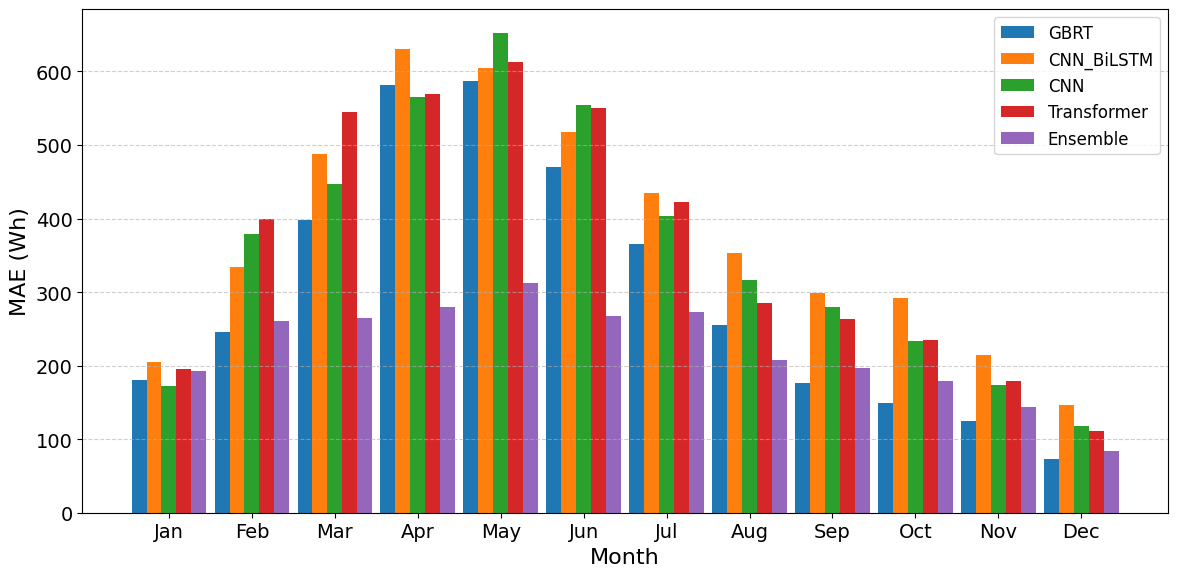

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import calendar

labels = [calendar.month_abbr[i + 1] for i in range(12)]
x = np.arange(len(labels))
width = 0.18
models = list(monthly_mae.keys())

# Set global font sizes
plt.rcParams.update({'font.size': 14})

# Create single plot for MAE
fig, ax = plt.subplots(figsize=(12, 6))

# --- Plot MAE ---
for i, model in enumerate(models):
    ax.bar(x + i * width, monthly_mae[model], width, label=model)

ax.set_ylabel('MAE (Wh)', fontsize=16)
ax.set_xlabel('Month', fontsize=16)
ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels(labels, fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.grid(True, axis='y', linestyle='--', alpha=0.6)

# --- Legend inside the plot (top-right corner) ---
ax.legend(loc='upper right', fontsize=12, frameon=True)

# Adjust layout and save
plt.tight_layout()
plt.savefig('compar_ex3_ensemble.pdf')
plt.show()


In [32]:
# Make sure predictions are all shaped: (365, 24, 2)
def ensure_3d(pred):
    if pred.ndim == 2 and pred.shape[1] == 48:
        return pred.reshape((-1, 24, 2))
    return pred

# Reshape if needed
pred_gbrt = ensure_3d(pred_gbrt)
pred_lstm = ensure_3d(pred_cnn_bilstm)
pred_cnn = ensure_3d(pred_cnn)
pred_transformer = ensure_3d(pred_transformer)

# Store model predictions
models = {
    "GBRT": pred_gbrt,
    "CNN": pred_cnn,
    "CNN_BiLSTM": pred_cnn_bilstm,
    "Transformer": pred_transformer,
    "Ensemble": ensemble_flat
    
}

# Initialize results
hourly_mae_combined = {name: [] for name in models}

# Compute combined MAE for each hour
for hour in range(24):
    y_h = y_test[:, hour, :]  # (365, 2)
    for name, pred in models.items():
        p_h = pred[:, hour, :]  # (365, 2)
        error = np.abs(y_h - p_h)
        mae = np.mean(error)  # average over 365 * 2
        hourly_mae_combined[name].append(mae)
import matplotlib.pyplot as plt
import numpy as np

labels = [str(h) for h in range(24)]  # Hours 0 to 23
x = np.arange(len(labels))
width = 0.18
model_names = list(hourly_mae_combined.keys())

fig, ax = plt.subplots(figsize=(16, 6))

# Plot each model's bars
for i, model in enumerate(model_names):
    ax.bar(x + i * width, hourly_mae_combined[model], width, label=model)

# Formatting
ax.set_ylabel('MAE (Wh)')
ax.set_xlabel('Time of the day')

ax.set_xticks(x + width * (len(model_names) - 1) / 2)
ax.set_xticklabels(labels)
ax.grid(True, axis='y', linestyle='--', alpha=0.6)
ax.legend(loc='upper right', frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('hourly_compar3.pdf')


NameError: name 'ensemble_flat' is not defined

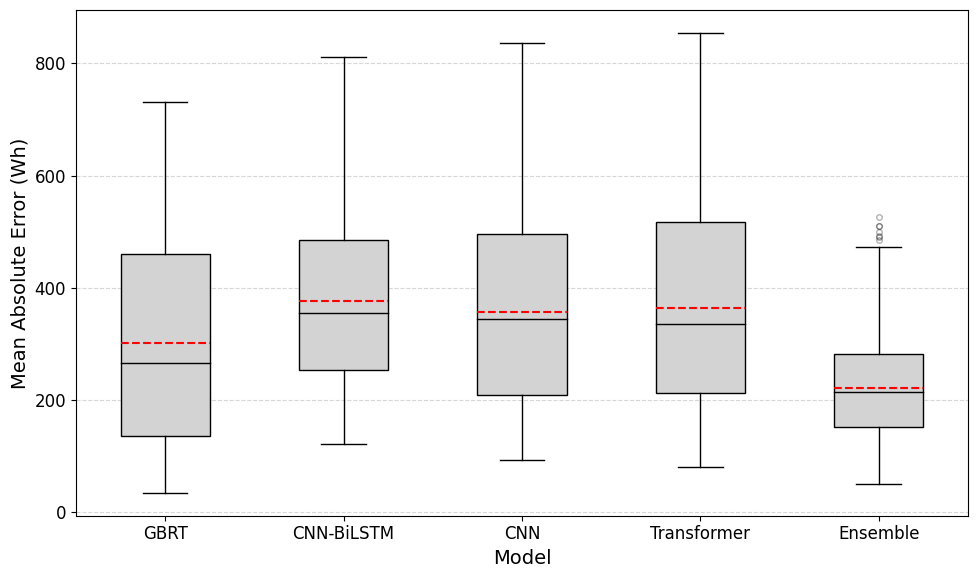

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# --- Function to compute daily MAE across all hours and targets ---
def compute_daily_mae(y_true, y_pred):
    absolute_errors = np.abs(y_true - y_pred)  # shape: (365, 24, 2)
    daily_mae = absolute_errors.mean(axis=(1, 2))  # mean over time and targets
    return daily_mae

# --- Collect daily MAEs for each model ---
daily_mae_per_model = {
    "GBRT": compute_daily_mae(y_test, pred_gbrt),
    "CNN-BiLSTM": compute_daily_mae(y_test, pred_cnn_bilstm),
    "CNN": compute_daily_mae(y_test, pred_cnn),
    "Transformer": compute_daily_mae(y_test, pred_transformer),
    "Ensemble" : compute_daily_mae(y_test, ensemble_flat)
}

# --- Prepare data for boxplot ---
box_data = [daily_mae_per_model[model] for model in daily_mae_per_model]
model_labels = list(daily_mae_per_model.keys())

# --- Plot configuration ---
plt.figure(figsize=(10, 6))
box = plt.boxplot(
    box_data,
    labels=model_labels,
    patch_artist=True,
    showmeans=True,
    meanline=True,
    boxprops=dict(facecolor='lightgray', color='black'),
    medianprops=dict(color='black'),
    meanprops=dict(color='red', linestyle='--', linewidth=1.5),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(marker='o', markersize=4, alpha=0.3)
)

# --- Axis labels and font sizes ---
plt.ylabel('Mean Absolute Error (Wh)', fontsize=14)
plt.xlabel('Model', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# --- Grid and layout ---
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('boxplot_daily_mae_ensemble.pdf', bbox_inches='tight')



In [101]:
import numpy as np

# Absolute error for each output per sample
abs_errors = np.abs(pred_transformer[:,:,0].flatten() - y_test[:,:,0].flatten())  # shape (N, 2)

# Mean absolute error per sample (average over PV and Grid)
mae_transformer = abs_errors.mean()  # shape (N,)


In [102]:
mae_transformer

271.73066482446467

In [112]:

import numpy as np
from scipy.stats import ttest_rel

# Step 1: Compute absolute errors
abs_error_ensemble = np.abs(pred_transformer- y_test)       # shape: (365, 24, 2)
abs_error_transformer = np.abs(pred_cnn - y_test) # shape: (365, 24, 2)

# Step 2: Flatten each output channel (PV = channel 0, Grid = channel 1)
mae_ensemble_pv = abs_error_ensemble[:, :, 0].flatten()       # PV channel
mae_ensemble_grid = abs_error_ensemble[:, :, 1].flatten()     # Grid channel

mae_transformer_pv = abs_error_transformer[:, :, 0].flatten()
mae_transformer_grid = abs_error_transformer[:, :, 1].flatten()

# Step 3: Run paired t-tests
t_pv, p_pv = ttest_rel(mae_ensemble_pv, mae_transformer_pv)
t_grid, p_grid = ttest_rel(mae_ensemble_grid, mae_transformer_grid)

# Step 4: Print results
print("Paired t-test results:")
print(f"PV Channel    (Ensemble vs. Transformer): p = {p_pv:.2e}")
print(f"Grid Channel  (Ensemble vs. Transformer): p = {p_grid:.2e}")

# Optional interpretation
alpha = 0.05
print("\nInterpretation:")
print("✅" if p_pv < alpha else "❌", "PV channel difference is", "statistically significant" if p_pv < alpha else "not significant")
print("✅" if p_grid < alpha else "❌", "Grid channel difference is", "statistically significant" if p_grid < alpha else "not significant")





Paired t-test results:
PV Channel    (Ensemble vs. Transformer): p = 2.58e-19
Grid Channel  (Ensemble vs. Transformer): p = 8.68e-74

Interpretation:
✅ PV channel difference is statistically significant
✅ Grid channel difference is statistically significant


In [116]:
import numpy as np

# Step 1: Absolute errors for each model
abs_error_ensemble = np.abs(ensemble_flat.reshape(365,24,2) - y_test)       # shape: (365, 24, 2)
abs_error_transformer = np.abs(pred_transformer - y_test) # shape: (365, 24, 2)

# Step 2: Flatten errors for PV (channel 0) and Grid (channel 1)
mae_ensemble_pv = abs_error_ensemble[:, :, 0].flatten()
mae_transformer_pv = abs_error_transformer[:, :, 0].flatten()

mae_ensemble_grid = abs_error_ensemble[:, :, 1].flatten()
mae_transformer_grid = abs_error_transformer[:, :, 1].flatten()

# Step 3: Define Cohen’s d function
def cohens_d(x, y):
    diff = x - y
    return diff.mean() / diff.std(ddof=1)

# Step 4: Compute Cohen’s d for each channel
d_pv = cohens_d(mae_ensemble_pv, mae_transformer_pv)
d_grid = cohens_d(mae_ensemble_grid, mae_transformer_grid)

# Step 5: Print the results
print("Cohen's d Effect Sizes:")
print(f"PV Channel    (Ensemble vs. Transformer): d = {d_pv:.3f}")
print(f"Grid Channel  (Ensemble vs. Transformer): d = {d_grid:.3f}")


Cohen's d Effect Sizes:
PV Channel    (Ensemble vs. Transformer): d = -0.534
Grid Channel  (Ensemble vs. Transformer): d = -0.086


In [117]:
import numpy as np

# Step 1: Absolute errors for each model
abs_error_ensemble = np.abs(ensemble_flat.reshape(365,24,2) - y_test)       # shape: (365, 24, 2)
abs_error_transformer = np.abs(pred_gbrt.reshape(365,24,2)- y_test) # shape: (365, 24, 2)

# Step 2: Flatten errors for PV (channel 0) and Grid (channel 1)
mae_ensemble_pv = abs_error_ensemble[:, :, 0].flatten()
mae_transformer_pv = abs_error_transformer[:, :, 0].flatten()

mae_ensemble_grid = abs_error_ensemble[:, :, 1].flatten()
mae_transformer_grid = abs_error_transformer[:, :, 1].flatten()

# Step 3: Define Cohen’s d function
def cohens_d(x, y):
    diff = x - y
    return diff.mean() / diff.std(ddof=1)

# Step 4: Compute Cohen’s d for each channel
d_pv = cohens_d(mae_ensemble_pv, mae_transformer_pv)
d_grid = cohens_d(mae_ensemble_grid, mae_transformer_grid)

# Step 5: Print the results
print("Cohen's d Effect Sizes:")
print(f"PV Channel    (Ensemble vs. Transformer): d = {d_pv:.3f}")
print(f"Grid Channel  (Ensemble vs. Transformer): d = {d_grid:.3f}")


Cohen's d Effect Sizes:
PV Channel    (Ensemble vs. Transformer): d = -0.070
Grid Channel  (Ensemble vs. Transformer): d = -0.161


In [118]:
import numpy as np

# Step 1: Absolute errors for each model
abs_error_ensemble = np.abs(ensemble_flat.reshape(365,24,2) - y_test)       # shape: (365, 24, 2)
abs_error_transformer = np.abs(pred_cnn_bilstm - y_test) # shape: (365, 24, 2)

# Step 2: Flatten errors for PV (channel 0) and Grid (channel 1)
mae_ensemble_pv = abs_error_ensemble[:, :, 0].flatten()
mae_transformer_pv = abs_error_transformer[:, :, 0].flatten()

mae_ensemble_grid = abs_error_ensemble[:, :, 1].flatten()
mae_transformer_grid = abs_error_transformer[:, :, 1].flatten()

# Step 3: Define Cohen’s d function
def cohens_d(x, y):
    diff = x - y
    return diff.mean() / diff.std(ddof=1)

# Step 4: Compute Cohen’s d for each channel
d_pv = cohens_d(mae_ensemble_pv, mae_transformer_pv)
d_grid = cohens_d(mae_ensemble_grid, mae_transformer_grid)

# Step 5: Print the results
print("Cohen's d Effect Sizes:")
print(f"PV Channel    (Ensemble vs. Transformer): d = {d_pv:.3f}")
print(f"Grid Channel  (Ensemble vs. Transformer): d = {d_grid:.3f}")


Cohen's d Effect Sizes:
PV Channel    (Ensemble vs. Transformer): d = -0.375
Grid Channel  (Ensemble vs. Transformer): d = -0.124


In [119]:
import numpy as np

# Step 1: Absolute errors for each model
abs_error_ensemble = np.abs(ensemble_flat.reshape(365,24,2) - y_test)       # shape: (365, 24, 2)
abs_error_transformer = np.abs(pred_cnn - y_test) # shape: (365, 24, 2)

# Step 2: Flatten errors for PV (channel 0) and Grid (channel 1)
mae_ensemble_pv = abs_error_ensemble[:, :, 0].flatten()
mae_transformer_pv = abs_error_transformer[:, :, 0].flatten()

mae_ensemble_grid = abs_error_ensemble[:, :, 1].flatten()
mae_transformer_grid = abs_error_transformer[:, :, 1].flatten()

# Step 3: Define Cohen’s d function
def cohens_d(x, y):
    diff = x - y
    return diff.mean() / diff.std(ddof=1)

# Step 4: Compute Cohen’s d for each channel
d_pv = cohens_d(mae_ensemble_pv, mae_transformer_pv)
d_grid = cohens_d(mae_ensemble_grid, mae_transformer_grid)

# Step 5: Print the results
print("Cohen's d Effect Sizes:")
print(f"PV Channel    (Ensemble vs. Transformer): d = {d_pv:.3f}")
print(f"Grid Channel  (Ensemble vs. Transformer): d = {d_grid:.3f}")


Cohen's d Effect Sizes:
PV Channel    (Ensemble vs. Transformer): d = -0.690
Grid Channel  (Ensemble vs. Transformer): d = -0.170


In [124]:
import numpy as np
from scipy.stats import ttest_rel, wilcoxon

# Define a function to compute Cohen’s d
def cohens_d(x, y):
    diff = x - y
    return diff.mean() / diff.std(ddof=1)

# Function to compute all three tests per model and per channel
def compare_models(reference, comparison, y_test, name):
    # Absolute errors
    ref_err = np.abs(reference - y_test)      # (365, 24, 2)
    comp_err = np.abs(comparison -y_test)    # (365, 24, 2)

    # Flatten each channel
    ref_pv = ref_err[:, :, 0].flatten()
    comp_pv = comp_err[:, :, 0].flatten()

    ref_grid = ref_err[:, :, 1].flatten()
    comp_grid = comp_err[:, :, 1].flatten()

    # Paired t-tests
    _, p_t_pv = ttest_rel(ref_pv, comp_pv)
    _, p_t_grid = ttest_rel(ref_grid, comp_grid)

    # Wilcoxon tests
    _, p_w_pv = wilcoxon(ref_pv, comp_pv)
    _, p_w_grid = wilcoxon(ref_grid, comp_grid)

    # Cohen's d
    d_pv = cohens_d(ref_pv, comp_pv)
    d_grid = cohens_d(ref_grid, comp_grid)

    # Print results
    print(f"\n=== {name} vs. Ensemble ===")
    print(f"PV Channel:")
    print(f"  t-test p = {p_t_pv:.2e} | Wilcoxon p = {p_w_pv:.2e} | Cohen's d = {d_pv:.3f}")
    print(f"Grid Channel:")
    print(f"  t-test p = {p_t_grid:.2e} | Wilcoxon p = {p_w_grid:.2e} | Cohen's d = {d_grid:.3f}")

# 🔧 Call the function for each comparison
compare_models(ensemble_flat.reshape(365,24,2), pred_gbrt.reshape(365,24,2),         y_test, "GBRT")
compare_models(ensemble_flat.reshape(365,24,2), pred_cnn_bilstm,   y_test, "CNN-BiLSTM")
compare_models(ensemble_flat.reshape(365,24,2), pred_cnn,          y_test, "CNN")
compare_models(ensemble_flat.reshape(365,24,2), pred_transformer,  y_test, "Transformer")



=== GBRT vs. Ensemble ===
PV Channel:
  t-test p = 5.45e-11 | Wilcoxon p = 3.33e-22 | Cohen's d = -0.070
Grid Channel:
  t-test p = 6.11e-51 | Wilcoxon p = 2.06e-31 | Cohen's d = -0.161

=== CNN-BiLSTM vs. Ensemble ===
PV Channel:
  t-test p = 3.87e-253 | Wilcoxon p = 0.00e+00 | Cohen's d = -0.375
Grid Channel:
  t-test p = 1.05e-30 | Wilcoxon p = 2.27e-305 | Cohen's d = -0.124

=== CNN vs. Ensemble ===
PV Channel:
  t-test p = 0.00e+00 | Wilcoxon p = 0.00e+00 | Cohen's d = -0.690
Grid Channel:
  t-test p = 4.67e-56 | Wilcoxon p = 0.00e+00 | Cohen's d = -0.170

=== Transformer vs. Ensemble ===
PV Channel:
  t-test p = 0.00e+00 | Wilcoxon p = 0.00e+00 | Cohen's d = -0.534
Grid Channel:
  t-test p = 8.49e-16 | Wilcoxon p = 0.00e+00 | Cohen's d = -0.086


In [103]:
import numpy as np

# Absolute error for each output per sample
abs_errors = np.abs(en[:,:,0].flatten() - y_test[:,:,0].flatten())  # shape (N, 2)

# Mean absolute error per sample (average over PV and Grid)
mae_ensemble = abs_errors.mean()  # shape (N,)

In [66]:
import numpy as np

# Absolute error for each output per sample
abs_errors = np.abs(pred_gbrt - y_test)  # shape (N, 2)

# Mean absolute error per sample (average over PV and Grid)
mae_gbrt = abs_errors.mean(axis=1)  # shape (N,)

In [35]:
pred_transformer[1,:,0]


array([  111.76269 ,  3185.3123  ,  3145.9514  ,  3144.473   ,
        3140.338   ,  3263.5264  ,  3274.3352  ,  4848.862   ,
       12796.535   ,  6013.088   ,   139.513   ,   104.970345,
          15.42583 ,   106.258415,   103.3337  ,    67.1723  ,
          67.92208 ,  1257.9865  ,  5062.597   ,  3753.8506  ,
         112.82892 ,    74.3979  ,    65.69165 ,    93.451035],
      dtype=float32)

In [36]:
ensemble_flat[1,:,0]

array([   77.82348272,  3187.82348272,  3187.82348272,  3187.82348272,
        3187.46570969,  3187.47418483,  3187.39135263,  4782.53317262,
       12750.29473812,  6013.08789062,   139.51300049,    50.93058777,
          77.82348272,    77.82348272,    77.82348272,    77.82348272,
          77.82348272,  1257.9864502 ,  5062.59716797,  3760.36157227,
         237.152771  ,    77.82348272,    77.82348272,    77.82348272])

In [78]:
import numpy as np
from scipy.stats import t

# Sample data
before = pred_transformer[0:30,:,0].flatten()

after =ensemble_flat[0:30,:,0].flatten()

# Step 1: Differences
d = before - after

# Step 2: Mean of differences
mean_d = np.mean(d)

# Step 3: Standard deviation of differences
std_d = np.sqrt(np.sum((d - mean_d)**2) / (len(d) - 1))

# Step 4: Sample size
n = len(d)

# Step 5: t-statistic
t_stat = mean_d / (std_d / np.sqrt(n))

# Step 6: Degrees of freedom
df = n - 1

# Step 7: Two-tailed p-value from t-distribution
p_value = 2 * (1 - t.cdf(abs(t_stat), df))

# Output
print("t-statistic:", t_stat)
print("p-value:", p_value)


t-statistic: 2.4139449273904288
p-value: 0.016029709975641016


In [105]:
import numpy as np
from scipy.stats import t

# Define a function to compute t-statistic and p-value
def paired_t_test(model_output, ensemble_output):
    before = model_output[65:70, :, 0].flatten()
    after = ensemble_output[65:70, :, 0].flatten()
    d = before - after
    mean_d = np.mean(d)
    std_d = np.sqrt(np.sum((d - mean_d)**2) / (len(d) - 1))
    n = len(d)
    t_stat = mean_d / (std_d / np.sqrt(n))
    df = n - 1
    p_value = 2 * (1 - t.cdf(abs(t_stat), df))
    return t_stat, p_value

# Run the t-tests for each model
results = {
    "GBRT": paired_t_test(pred_gbrt.reshape(365,24,2), ensemble_flat),
    "CNN": paired_t_test(pred_cnn, ensemble_flat),
    "CNN_BiLSTM": paired_t_test(pred_cnn_bilstm, ensemble_flat),
    "Transformer": paired_t_test(pred_transformer, ensemble_flat)
}

# Print results
for model, (t_stat, p_val) in results.items():
    print(f"{model}: t-statistic = {t_stat:.4f}, p-value = {p_val:.4e}")


GBRT: t-statistic = -3.0623, p-value = 2.7164e-03
CNN: t-statistic = 3.9593, p-value = 1.2843e-04
CNN_BiLSTM: t-statistic = -4.7198, p-value = 6.4978e-06
Transformer: t-statistic = 4.6526, p-value = 8.5706e-06


In [108]:
import numpy as np

# Function to compute Cohen's d
def cohens_d(model_output, ensemble_output):
    before = model_output[65:70, :, 0].flatten()
    after = ensemble_output[65:70, :, 0].flatten()
    d = before - after
    mean_d = np.mean(d)
    std_d = np.std(d, ddof=1)
    return mean_d / std_d

# Compute for each model
cohens_results = {
    "GBRT": cohens_d(pred_gbrt.reshape(365,24,2), ensemble_flat),
    "CNN": cohens_d(pred_cnn, ensemble_flat),
    "CNN_BiLSTM": cohens_d(pred_cnn_bilstm, ensemble_flat),
    "Transformer": cohens_d(pred_transformer, ensemble_flat)
}

# Print formatted results
for model, d in cohens_results.items():
    print(f"{model}: Cohen's d = {d:.4f}")


GBRT: Cohen's d = -0.2795
CNN: Cohen's d = 0.3614
CNN_BiLSTM: Cohen's d = -0.4309
Transformer: Cohen's d = 0.4247


In [132]:
np.mean(pred_transformer[:,:,0] - y_test[:,:,0])

12.324074733916621

In [124]:
np.mean((abs(pred_transformer[:,:,0].flatten()) - abs(y_test[:,:,0].flatten())))

60.6877895810928

In [125]:
np.mean((abs(ensemble_flat[:,:,0].flatten()) -abs(y_test[:,:,0].flatten())))

-35.8234971698402

In [133]:
import numpy as np
from scipy.stats import wilcoxon

def run_wilcoxon(model_output, ensemble_output, name="Model"):
    """
    Performs a Wilcoxon signed-rank test between a model and ensemble outputs.
    
    Parameters:
        model_output (np.ndarray): Array shaped (30, N, 1) from the model
        ensemble_output (np.ndarray): Array shaped (30, N, 1) from the ensemble
        name (str): Name of the model (for display)

    Returns:
        (float, float): test statistic, p-value
    """
    # Flatten the outputs
    before = model_output[0:30, :, 0].flatten()
    after = ensemble_output[0:30, :, 0].flatten()
    
    # Perform Wilcoxon signed-rank test
    stat, p = wilcoxon(before, after)
    
    print(f"{name}: Wilcoxon test statistic = {stat:.4f}, p-value = {p:.4e}")
    return stat, p



In [140]:
run_wilcoxon(pred_cnn_bilstm, ensemble_flat, "GBRT")

GBRT: Wilcoxon test statistic = 61142.0000, p-value = 1.3762e-22


(61142.0, 1.3761848251522193e-22)

In [34]:
gbrt_error = pred_gbrt.reshape(365,24,2)

In [33]:
ensemble_flat.shape

(365, 24, 2)

**P_values**

In [35]:
import numpy as np
from scipy.stats import wilcoxon, norm

# --- Replace with your paired arrays (length n = 24*365 = 8760) ---
mae_ens  = gbrt_error   # Ensemble MAE
mae_gbrt = ensemble_flat

# Paired Wilcoxon (two-sided)
res = wilcoxon(mae_ens, mae_gbrt, alternative='two-sided', zero_method='pratt', mode='auto')

# Effect size r = |Z| / sqrt(n)  (Z from two-sided p-value)
n = len(mae_ens)
z = abs(norm.isf(res.pvalue / 2.0))   # inverse survival for half p (two-sided)
r = z / np.sqrt(n)

print(f"Wilcoxon W = {res.statistic:.1f}")
print(f"p-value (two-sided) = {res.pvalue:.6g}")
print(f"Effect size r = {r:.3f}")

# Optional: direction & magnitude summary
diff = mae_ens - mae_gbrt
median_diff = np.median(diff)          # negative => Ensemble lower MAE
pct_better = (diff < 0).mean() * 100   # % of hours Ensemble lower

print(f"Median(Ensemble - GBRT) = {median_diff:.4f}")
print(f"% hours Ensemble < GBRT = {pct_better:.1f}%")


/usr/local/lib/python3.10/dist-packages/scipy/stats/_wilcoxon.py:182: RuntimeWarning: invalid value encountered in divide
  z = (r_plus - mn) / se
/usr/local/lib/python3.10/dist-packages/scipy/stats/_distn_infrastructure.py:2157: RuntimeWarning: invalid value encountered in less_equal
  cond2 = cond0 & (x <= _a)
/usr/local/lib/python3.10/dist-packages/scipy/stats/_distn_infrastructure.py:2285: RuntimeWarning: invalid value encountered in greater
  cond1 = (0 < q) & (q < 1)
/usr/local/lib/python3.10/dist-packages/scipy/stats/_distn_infrastructure.py:2285: RuntimeWarning: invalid value encountered in less
  cond1 = (0 < q) & (q < 1)


TypeError: unsupported format string passed to numpy.ndarray.__format__

In [40]:
import numpy as np
from scipy.stats import wilcoxon, norm
from statsmodels.stats.multitest import multipletests

# gbrt and ens arrays shape: (365, 24, 2)
# axis 2: channel 0 = PV, channel 1 = Consumption (rename if different)
mae_ens  = pred_transformer  # Ensemble MAE
mae_gbrt = ensemble_flat

# Flatten day x hour into one vector per channel (8760 obs each)
gbrt_pv  = pred_transformer [:, :, 0].ravel()
ens_pv   =ensemble_flat[:, :, 0].ravel()
gbrt_con = pred_transformer [:, :, 1].ravel()
ens_con  = ensemble_flat[:, :, 1].ravel()

def wilcoxon_two_sided(a, b):
    res = wilcoxon(a, b, alternative='two-sided', zero_method='pratt', mode='auto')
    W = float(res.statistic)
    p = float(res.pvalue)
    n = len(a)
    # effect size r = |Z| / sqrt(n), derive Z from two-sided p
    z = abs(norm.isf(p/2.0))
    r = z / np.sqrt(n)
    # directionality summaries
    d = a - b
    median_diff = np.median(d)        # negative => a < b (e.g., ens < gbrt if a=ens)
    pct_better = (d < 0).mean() * 100
    return W, p, r, median_diff, pct_better

# Compare Ensemble vs GBRT per channel
results = {}
results['PV'] = wilcoxon_two_sided(ens_pv, gbrt_pv)
results['Consumption'] = wilcoxon_two_sided(ens_con, gbrt_con)

# Holm correction across the two tests
pvals = [results['PV'][1], results['Consumption'][1]]
rej, pvals_holm, _, _ = multipletests(pvals, alpha=0.05, method='holm')

# Print
for (name, (W, p, r, med, pct)), ph, sig in zip(results.items(), pvals_holm, rej):
    print(f"{name:12s} | W={W:.1f} | p(two-sided)={p:.3g} | p_Holm={ph:.3g} | r={r:.3f} "
          f"| median(Ens-GBRT)={med:.4f} | %hours Ens<GBRT={pct:.1f}% | sig={sig}")


PV           | W=14518914.5 | p(two-sided)=3.59e-76 | p_Holm=7.19e-76 | r=0.197 | median(Ens-GBRT)=-4.5030 | %hours Ens<GBRT=51.5% | sig=True
Consumption  | W=16076958.0 | p(two-sided)=1.48e-32 | p_Holm=1.48e-32 | r=0.127 | median(Ens-GBRT)=0.0000 | %hours Ens<GBRT=39.0% | sig=True


In [46]:
np.mean(abs((ensemble_flat[:,:,0] - pred_transformer[:,:,0]).flatten()))

231.70157001321954

In [51]:
import numpy as np
from scipy.stats import wilcoxon, norm

# err_ens, err_trf: abs error arrays, shape (365, 24, 2)
ens_vec = err_ens[:, :, 0].ravel().astype(float)
trf_vec = err_trf[:, :, 0].ravel().astype(float)

# mask non-finite or NaN diffs to avoid warnings
d = ens_vec - trf_vec
mask = np.isfinite(ens_vec) & np.isfinite(trf_vec) & np.isfinite(d)
ens_vec, trf_vec, d = ens_vec[mask], trf_vec[mask], d[mask]

# two-sided Wilcoxon (drop exact ties)
res = wilcoxon(ens_vec, trf_vec, alternative='two-sided', zero_method='wilcox', mode='auto')
W = float(res.statistic); p = float(res.pvalue)
z = abs(norm.isf(p/2.0))
r = z / np.sqrt(len(ens_vec))

median_diff = float(np.median(d))          # negative => Ensemble lower error
pct_better  = float((d < 0).mean() * 100)  # % samples Ensemble < Transformer

print(f"W={W:.1f} | p(two-sided)={p:.3g} | r={r:.3f} | median(Ens-Trf)={median_diff:.6f} | %Ens<Trf={pct_better:.1f}%")


W=11067474.5 | p(two-sided)=5.17e-78 | r=0.200 | median(Ens-Trf)=-4.503021 | %Ens<Trf=51.5%


In [55]:
import numpy as np
from scipy.stats import wilcoxon, norm
from statsmodels.stats.multitest import multipletests

# -------------------------------------------------------
# Inputs (absolute error arrays), shape: (365, 24, 2)
# err_ens: Ensemble; err_gbrt, err_cnn, err_cnn_bilstm, err_trf: base models
# Channel 0 (index 0) will be tested.
# -------------------------------------------------------

# Helper to flatten channel 0 and mask non-finite values
def flatten_ch0(arr):
    v = np.asarray(arr)[:, :, 0].ravel().astype(float)
    return v

ens_vec_raw = flatten_ch0(err_ens)

models = {
    "GBRT":        flatten_ch0(pred_gbrt.reshape(365,24,2)),
    "CNN":         flatten_ch0(pred_cnn),
    "CNN_BiLSTM":  flatten_ch0(pred_cnn_bilstm),
    "Transformer": flatten_ch0(pred_transformer),
}

# Run paired Wilcoxon (two-sided) vs Ensemble for each model
names, W_list, p_list, r_list, med_list, pct_list = [], [], [], [], [], []

for name, base_vec_raw in models.items():
    # mask non-finite values and compute differences
    d_raw = ens_vec_raw - base_vec_raw
    mask = np.isfinite(ens_vec_raw) & np.isfinite(base_vec_raw) & np.isfinite(d_raw)
    a = ens_vec_raw[mask]
    b = base_vec_raw[mask]
    d = d_raw[mask]  # negative => Ensemble lower error

    # Two-sided Wilcoxon; drop exact ties to avoid warnings
    res = wilcoxon(a, b, alternative='two-sided', zero_method='wilcox', mode='auto')
    W = float(res.statistic)
    p = float(res.pvalue)

    # Effect size r = |Z| / sqrt(n), Z from two-sided p
    n = len(a)
    z = abs(norm.isf(p / 2.0))
    r = z / np.sqrt(n)

    # Practical summaries
    med = float(np.median(d))          # negative => Ensemble lower
    pct = float((d < 0).mean() * 100)  # % samples Ensemble < model

    names.append(name)
    W_list.append(W); p_list.append(p); r_list.append(r)
    med_list.append(med); pct_list.append(pct)

# Holm correction across all four comparisons
rej, p_holm, _, _ = multipletests(p_list, alpha=0.05, method='holm')

# Pretty print
for name, W, p, ph, r, med, pct, sig in zip(names, W_list, p_list, p_holm, r_list, med_list, pct_list, rej):
    print(f"{name:12s} | W={W:.1f} | p(two-sided)={p:.3g} | p_Holm={ph:.3g} | r={r:.3f} "
          f"| median(Ens-{name})={med:.6f} | %Ens<{name}={pct:.1f}% | sig={sig}")


GBRT         | W=841546.0 | p(two-sided)=7.2e-100 | p_Holm=2.88e-99 | r=0.227 | median(Ens-GBRT)=0.000000 | %Ens<GBRT=9.5% | sig=True
CNN          | W=14280153.0 | p(two-sided)=0.0344 | p_Holm=0.0344 | r=0.023 | median(Ens-CNN)=0.000000 | %Ens<CNN=43.0% | sig=True
CNN_BiLSTM   | W=15038629.0 | p(two-sided)=2.92e-31 | p_Holm=5.84e-31 | r=0.124 | median(Ens-CNN_BiLSTM)=-3.915787 | %Ens<CNN_BiLSTM=52.6% | sig=True
Transformer  | W=11067474.5 | p(two-sided)=5.17e-78 | p_Holm=1.55e-77 | r=0.200 | median(Ens-Transformer)=-4.503021 | %Ens<Transformer=51.5% | sig=True


**Daily p vaalue**

In [82]:
import numpy as np
from scipy.stats import wilcoxon, norm
from statsmodels.stats.multitest import multipletests

# ---- Helper: get per-day means for channel 0 (PV) from various shapes ----
def per_day_means_ch0(arr):
    a = np.asarray(arr)
    if a.ndim == 3:
        # (365, 24, 2) -> take channel 0 then mean over hours
        assert a.shape[0] == 365 and a.shape[1] == 24, "Expected shape (365,24,2)"
        return np.nanmean(a[:, :, 0], axis=1)  # (365,)
    elif a.ndim == 2:import numpy as np
from scipy.stats import wilcoxon, norm
from statsmodels.stats.multitest import multipletests

# ---- inputs: absolute error arrays (365, 24, 2) ----
# err_ens, err_gbrt, err_cnn, err_cnn_bilstm, err_trf

# Aggregate to per-day means for channel 0 (PV)
def per_day_ch0(arr):
    a = np.asarray(arr, dtype=float)
    day_means = np.nanmean(a[:, :, 0], axis=1)  # (365,)
    return day_means[np.isfinite(day_means)]

ens_day = per_day_ch0(ensemble_flat.reshape(365,24,2))

models = {
    "GBRT":        per_day_ch0(pred_gbrt.reshape(365,24,2)-y_test.reshape(365,24,2)),
    "CNN":         per_day_ch0(pred_cnn-y_test.reshape(365,24,2)),
    "CNN_BiLSTM":  per_day_ch0(pred_cnn_bilstm-y_test.reshape(365,24,2)),
    "Transformer": per_day_ch0(pred_transformer-y_test.reshape(365,24,2)),
}

names, W_list, p_list, r_list, med_list, pct_list = [], [], [], [], [], []

for name, base_day in models.items():
    # ensure paired finite entries (should both be length 365, but mask just in case)
    mask = np.isfinite(ens_day) & np.isfinite(base_day)
    a = ens_day[mask]
    b = base_day[mask]
    d = a - b  # negative => Ensemble lower daily error

    # Two-sided Wilcoxon on per-day means; drop exact ties
    res = wilcoxon(a, b, alternative='two-sided', zero_method='wilcox', mode='auto')
    W = float(res.statistic)
    p = float(res.pvalue)

    n = len(a)
    z = abs(norm.isf(p / 2.0))  # derive |Z| from two-sided p
    r = z / np.sqrt(n)          # effect size

    med = float(np.median(d))           # daily median diff (neg => Ensemble better)
    pct = float((d < 0).mean() * 100)   # % of days Ensemble < model

    names.append(name)
    W_list.append(W); p_list.append(p); r_list.append(r)
    med_list.append(med); pct_list.append(pct)

# Holm correction across the four pairwise tests
rej, p_holm, _, _ = multipletests(p_list, alpha=0.05, method='holm')

# Pretty print results
for name, W, p, ph, r, med, pct, sig in zip(names, W_list, p_list, p_holm, r_list, med_list, pct_list, rej):
    print(f"{name:12s} | W={W:.1f} | p(two-sided)={p:.3g} | p_Holm={ph:.3g} | r={r:.3f} "
          f"| median(Ens-{name})={med:.6f} | %days Ens<{name}={pct:.1f}% | sig={sig}")


GBRT         | W=0.0 | p(two-sided)=1.43e-61 | p_Holm=5.73e-61 | r=0.867 | median(Ens-GBRT)=3319.117627 | %days Ens<GBRT=0.0% | sig=True
CNN          | W=0.0 | p(two-sided)=1.43e-61 | p_Holm=5.73e-61 | r=0.867 | median(Ens-CNN)=3287.314710 | %days Ens<CNN=0.0% | sig=True
CNN_BiLSTM   | W=0.0 | p(two-sided)=1.43e-61 | p_Holm=5.73e-61 | r=0.867 | median(Ens-CNN_BiLSTM)=3431.424431 | %days Ens<CNN_BiLSTM=0.0% | sig=True
Transformer  | W=0.0 | p(two-sided)=1.43e-61 | p_Holm=5.73e-61 | r=0.867 | median(Ens-Transformer)=3242.291223 | %days Ens<Transformer=0.0% | sig=True


In [35]:
import numpy as np
from scipy.stats import wilcoxon, norm
from statsmodels.stats.multitest import multipletests

# ---- Helper: get per-day means for channel 0 (PV) from various shapes ----
def per_day_means_ch0(arr):
    a = np.asarray(arr)
    if a.ndim == 3:
        # (365, 24, 2) -> take channel 0 then mean over hours
        assert a.shape[0] == 365 and a.shape[1] == 24, "Expected shape (365,24,2)"
        return np.nanmean(a[:, :, 0], axis=1)  # (365,)
    elif a.ndim == 2:import numpy as np
from scipy.stats import wilcoxon, norm
from statsmodels.stats.multitest import multipletests

# ---- inputs: absolute error arrays (365, 24, 2) ----
# err_ens, err_gbrt, err_cnn, err_cnn_bilstm, err_trf

# Aggregate to per-day means for channel 0 (PV)
def per_day_ch0(arr):
    a = np.asarray(arr, dtype=float)
    day_means = np.nanmean(a[:, :, 1], axis=1)  # (365,)
    return day_means[np.isfinite(day_means)]

ens_day = per_day_ch0(ensemble_flat.reshape(365,24,2))

models = {
    "GBRT":        per_day_ch0(pred_gbrt.reshape(365,24,2)),
    "CNN":         per_day_ch0(pred_cnn),
    "CNN_BiLSTM":  per_day_ch0(pred_cnn_bilstm),
    "Transformer": per_day_ch0(pred_transformer),
}

names, W_list, p_list, r_list, med_list, pct_list = [], [], [], [], [], []

for name, base_day in models.items():
    # ensure paired finite entries (should both be length 365, but mask just in case)
    mask = np.isfinite(ens_day) & np.isfinite(base_day)
    a = ens_day[mask]
    b = base_day[mask]
    d = a - b  # negative => Ensemble lower daily error

    # Two-sided Wilcoxon on per-day means; drop exact ties
    res = wilcoxon(a, b, alternative='two-sided', zero_method='wilcox', mode='auto')
    W = float(res.statistic)
    p = float(res.pvalue)

    n = len(a)
    z = abs(norm.isf(p / 2.0))  # derive |Z| from two-sided p
    r = z / np.sqrt(n)          # effect size

    med = float(np.median(d))           # daily median diff (neg => Ensemble better)
    pct = float((d < 0).mean() * 100)   # % of days Ensemble < model

    names.append(name)
    W_list.append(W); p_list.append(p); r_list.append(r)
    med_list.append(med); pct_list.append(pct)

# Holm correction across the four pairwise tests
rej, p_holm, _, _ = multipletests(p_list, alpha=0.05, method='holm')

# Pretty print results
for name, W, p, ph, r, med, pct, sig in zip(names, W_list, p_list, p_holm, r_list, med_list, pct_list, rej):
    print(f"{name:12s} | W={W:.1f} | p(two-sided)={p:.3g} | p_Holm={ph:.3g} | r={r:.3f} "
          f"| median(Ens-{name})={med:.6f} | %days Ens<{name}={pct:.1f}% | sig={sig}")


GBRT         | W=13151.0 | p(two-sided)=1.05e-23 | p_Holm=3.14e-23 | r=0.525 | median(Ens-GBRT)=125.682616 | %days Ens<GBRT=36.2% | sig=True
CNN          | W=28885.0 | p(two-sided)=0.0253 | p_Holm=0.0253 | r=0.117 | median(Ens-CNN)=-17.944945 | %days Ens<CNN=52.9% | sig=True
CNN_BiLSTM   | W=2504.0 | p(two-sided)=6.04e-53 | p_Holm=2.42e-52 | r=0.802 | median(Ens-CNN_BiLSTM)=201.572806 | %days Ens<CNN_BiLSTM=9.0% | sig=True
Transformer  | W=22513.0 | p(two-sided)=6.82e-08 | p_Holm=1.36e-07 | r=0.282 | median(Ens-Transformer)=-50.261387 | %days Ens<Transformer=64.4% | sig=True


In [37]:
import numpy as np
from scipy.stats import wilcoxon, norm
from statsmodels.stats.multitest import multipletests

# ---------- helpers ----------
MONTH_LENGTHS = np.array([31,28,31,30,31,30,31,31,30,31,30,31])
MONTH_EDGES = np.concatenate(([0], np.cumsum(MONTH_LENGTHS)))  # 13 edges: 0..365

def to_365x24_ch0(arr):
    """
    Accept shapes: (365,24,2), (365,24), or (8760,) and return (365,24) for channel 0.
    """
    a = np.asarray(arr)
    if a.ndim == 3:
        assert a.shape[0] == 365 and a.shape[1] == 24 and a.shape[2] == 2, "Expected (365,24,2)"
        a = a[:, :, 0]
    elif a.ndim == 2:
        assert a.shape == (365, 24), "2D arrays must be (365,24)"
        # already day x hour
    elif a.ndim == 1:
        assert a.size == 365*24, "1D arrays must have length 8760"
        a = a.reshape(365, 24)
    else:
        raise ValueError("Unsupported array shape.")
    return a.astype(float)

def per_month_means_ch0(arr):
    """
    Compute 12 monthly means (PV channel) from (365,24,2)/(365,24)/(8760,)
    """
    a = to_365x24_ch0(arr)             # (365,24)
    day_means = np.nanmean(a, axis=1)  # (365,)
    months = []
    for m in range(12):
        start, end = MONTH_EDGES[m], MONTH_EDGES[m+1]
        months.append(np.nanmean(day_means[start:end]))
    return np.array(months, dtype=float)  # (12,)

# ---------- inputs ----------
# Use your variables as-is. These should be ABSOLUTE-ERROR arrays (not raw predictions):
#   ensemble_flat        -> can be (8760,) or (365,24,2)
#   pred_gbrt, pred_cnn, pred_cnn_bilstm, pred_transformer -> same idea
# If any are raw predictions, compute abs errors first before using this cell.

ens_month = per_month_means_ch0(ensemble_flat.reshape(365,24,2))
gbrt_month = per_month_means_ch0(pred_gbrt.reshape(365,24,2) )
cnn_month  = per_month_means_ch0(pred_cnn)
cbl_month  = per_month_means_ch0(pred_cnn_bilstm)
trf_month  = per_month_means_ch0(pred_transformer)

models = {
    "GBRT":        gbrt_month,
    "CNN":         cnn_month,
    "CNN_BiLSTM":  cbl_month,
    "Transformer": trf_month,
}

# ---------- Wilcoxon (two-sided), Holm correction, effect sizes ----------
names, W_list, p_list, r_list, med_list, pct_list = [], [], [], [], [], []
a0 = ens_month.astype(float)  # (12,)

for name, b0 in models.items():
    b0 = np.asarray(b0, dtype=float)
    mask = np.isfinite(a0) & np.isfinite(b0)     # should all be True for 12 months
    a, b = a0[mask], b0[mask]
    d = a - b                                    # negative => Ensemble lower monthly error

    # Two-sided Wilcoxon on 12 months; drop exact ties
    res = wilcoxon(a, b, alternative='two-sided', zero_method='wilcox', mode='auto')
    W = float(res.statistic)
    p = float(res.pvalue)
    n = len(a)                                   # expected 12
    z = abs(norm.isf(p / 2.0))                   # derive |Z| from two-sided p
    r = z / np.sqrt(n)                           # effect size

    med = float(np.median(d))                    # median monthly diff
    pct = float((d < 0).mean() * 100)            # % months Ensemble < model

    names.append(name); W_list.append(W); p_list.append(p); r_list.append(r)
    med_list.append(med); pct_list.append(pct)

# Holm correction across four comparisons
rej, p_holm, _, _ = multipletests(p_list, alpha=0.05, method='holm')

# ---------- print ----------
for name, W, p, ph, r, med, pct, sig in zip(names, W_list, p_list, p_holm, r_list, med_list, pct_list, rej):
    print(f"{name:12s} | W={W:.1f} | p(two-sided)={p:.3g} | p_Holm={ph:.3g} | r={r:.3f} "
          f"| median(Ens-{name})={med:.6f} | %months Ens<{name}={pct:.1f}% | sig={sig}")


GBRT         | W=28.0 | p(two-sided)=0.424 | p_Holm=0.424 | r=0.231 | median(Ens-GBRT)=-4.386095 | %months Ens<GBRT=58.3% | sig=False
CNN          | W=4.0 | p(two-sided)=0.00342 | p_Holm=0.0103 | r=0.845 | median(Ens-CNN)=-28.605642 | %months Ens<CNN=91.7% | sig=True
CNN_BiLSTM   | W=1.0 | p(two-sided)=0.000977 | p_Holm=0.00391 | r=0.952 | median(Ens-CNN_BiLSTM)=110.807837 | %months Ens<CNN_BiLSTM=8.3% | sig=True
Transformer  | W=6.0 | p(two-sided)=0.00684 | p_Holm=0.0137 | r=0.781 | median(Ens-Transformer)=-81.205844 | %months Ens<Transformer=83.3% | sig=True


In [39]:
pred_gbrt[0]

array([ 7.61252576e+01,  0.00000000e+00,  3.18612526e+03,  0.00000000e+00,
        3.18612526e+03,  0.00000000e+00,  3.18612526e+03,  0.00000000e+00,
        3.18636550e+03,  0.00000000e+00,  3.18640448e+03,  1.44067587e-01,
        3.18633801e+03,  1.53645163e+00,  4.72199739e+03,  3.94414380e+00,
        1.26144252e+04,  4.27988755e+01,  5.74858981e+03,  3.07949048e+02,
        1.06075934e+02,  9.90348274e+01,  7.59893495e+01,  7.68292131e+01,
        7.61252576e+01,  7.73394567e+01,  7.61252576e+01,  7.61348512e+01,
        7.61252576e+01,  7.62799514e+01,  7.61252576e+01,  7.56605678e+01,
        7.61252576e+01,  6.84773538e+01,  1.22842175e+03,  9.95769368e+02,
        5.06486909e+03,  1.15072682e+03,  3.67409954e+03,  1.56659558e+03,
        1.04541468e+02, -9.17520391e-04,  7.61252576e+01,  0.00000000e+00,
        7.61252576e+01,  0.00000000e+00,  7.61252576e+01,  0.00000000e+00])

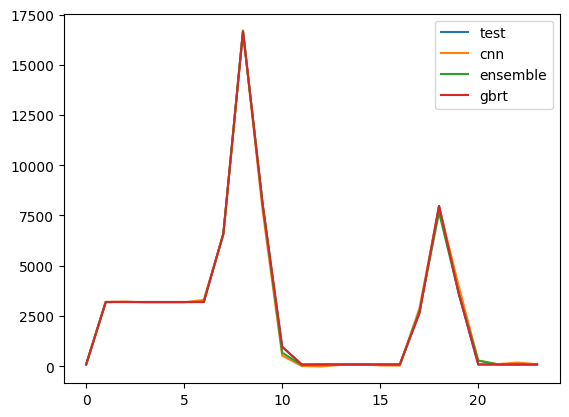

In [60]:
import matplotlib.pyplot as plt
g = 308
ch = 0
plt.plot(y_test[g,:,ch])
plt.plot(pred_cnn[g,:,ch])
plt.plot(ensemble_flat.reshape(365,24,2)[g,:,ch])
plt.plot(pred_gbrt.reshape(365,24,2)[g,:,ch])
plt.legend(['test','cnn','ensemble','gbrt'])

In [74]:
gbrt_mean = (np.mean((pred_gbrt.reshape(365,24,2)-y_test).flatten()))

In [79]:
ensemble_mean = (np.mean((ensemble_flat.reshape(365,24,2)-y_test).flatten()))

gbrt_mean

In [35]:
import numpy as np
from scipy.stats import friedmanchisquare, wilcoxon, norm
from statsmodels.stats.multitest import multipletests

# ------------------------------------------------------------------
# INPUTS (absolute errors on TEST), each shape: (365, 24, 2)
# Channels: 0 = PV, 1 = Consumption
# Provide these arrays before running:
#   abs_err_ens, abs_err_gbrt, abs_err_cnn, abs_err_cbl, abs_err_trf
# If you only have predictions, compute abs errors first:
#   abs_err_* = np.abs(pred_* - y_test)
# ------------------------------------------------------------------

CH = 1  # channel to analyze (0 = PV, 1 = Consumption)

def per_day_mae(err, ch=0):
    """Per-day MAE for a given channel from (365,24,2) absolute-errors array."""
    a = np.asarray(err, dtype=float)
    return np.nanmean(a[:, :, ch], axis=1)  # (365,)

# Per-day MAE vectors (length 365 each)
ens_day  = per_day_mae(np.abs(ensemble_flat.reshape(365,24,2) - y_test.reshape(365,24,2)), ch=CH)
gbrt_day = per_day_mae(np.abs(pred_gbrt.reshape(365,24,2) - y_test.reshape(365,24,2)), ch=CH)
cnn_day  = per_day_mae(np.abs(pred_cnn - y_test.reshape(365,24,2)), ch=CH)
cbl_day  = per_day_mae(np.abs(pred_cnn_bilstm - y_test.reshape(365,24,2)), ch=CH)   # CNN-BiLSTM
trf_day  = per_day_mae(np.abs(pred_transformer - y_test.reshape(365,24,2)), ch=CH)


# ---------------- Omnibus: Friedman test (k = 5 models) ----------------
k = 5
n = len(ens_day)  # expected 365
chi2, p_fried = friedmanchisquare(ens_day, gbrt_day, cnn_day, cbl_day, trf_day)

# Kendall's W effect size for Friedman
W_kendall = chi2 / (n * k * (k - 1))  # W in [0,1]; higher => stronger differences

print(f"Friedman: chi2={chi2:.3f}, df={k-1}, p={p_fried:.3g}, Kendall W={W_kendall:.3f}  (n={n}, k={k})")

# ---------------- Post-hoc: Ensemble vs each baseline (Wilcoxon) ---------------
baselines = {
    "GBRT": gbrt_day,
    "CNN": cnn_day,
    "CNN_BiLSTM": cbl_day,
    "Transformer": trf_day,
}

names, W_list, p_list, r_list, med_list, pct_list = [], [], [], [], [], []

for name, base in baselines.items():
    a = ens_day.astype(float)
    b = np.asarray(base, dtype=float)
    # paired finite mask (should be all True)
    mask = np.isfinite(a) & np.isfinite(b)
    a, b = a[mask], b[mask]
    d = a - b  # negative => Ensemble lower daily MAE

    # Two-sided Wilcoxon; drop exact ties to avoid warnings
    res = wilcoxon(a, b, alternative='two-sided', zero_method='wilcox', mode='auto')
    W = float(res.statistic)
    p = float(res.pvalue)

    # effect size r = |Z| / sqrt(n)
    z = abs(norm.isf(p / 2.0))
    r = z / np.sqrt(len(a))

    names.append(name)
    W_list.append(W)
    p_list.append(p)
    r_list.append(r)
    med_list.append(float(np.median(d)))
    pct_list.append(float((d < 0).mean() * 100))  # % days Ensemble < baseline

# Holm correction across the 4 pairwise comparisons
rej, p_holm, _, _ = multipletests(p_list, alpha=0.05, method='holm')

print("\nPost-hoc (Ensemble vs baseline) — Wilcoxon two-sided with Holm correction:")
for name, W, p, ph, r, med, pct, sig in zip(names, W_list, p_list, p_holm, r_list, med_list, pct_list, rej):
    print(f"{name:12s} | W={W:.1f} | p={p:.3g} | p_Holm={ph:.3g} | r={r:.3f} "
          f"| median(Ens-{name})={med:.3f} | %days Ens<{name}={pct:.1f}% | sig={sig}")


Friedman: chi2=140.300, df=4, p=2.43e-29, Kendall W=0.019  (n=365, k=5)

Post-hoc (Ensemble vs baseline) — Wilcoxon two-sided with Holm correction:
GBRT         | W=15221.0 | p=2.04e-19 | p_Holm=8.17e-19 | r=0.472 | median(Ens-GBRT)=-61.572 | %days Ens<GBRT=66.6% | sig=True
CNN          | W=15599.0 | p=1.11e-18 | p_Holm=3.33e-18 | r=0.462 | median(Ens-CNN)=-53.826 | %days Ens<CNN=76.2% | sig=True
CNN_BiLSTM   | W=18748.0 | p=3.8e-13 | p_Holm=3.8e-13 | r=0.380 | median(Ens-CNN_BiLSTM)=-54.079 | %days Ens<CNN_BiLSTM=66.0% | sig=True
Transformer  | W=17070.0 | p=5.76e-16 | p_Holm=1.15e-15 | r=0.424 | median(Ens-Transformer)=-39.328 | %days Ens<Transformer=75.1% | sig=True


In [94]:
import numpy as np

def monthly_mae(y_true, y_pred, ch=0):
    """
    Compute monthly MAE for one channel.
    
    Parameters
    ----------
    y_true : array-like, shape (365, 24, 2)
        Ground truth values.
    y_pred : array-like, shape (365, 24, 2)
        Model predictions.
    ch : int (0=PV, 1=Consumption)
        Which channel to compute MAE for.
    
    Returns
    -------
    mae_monthly : np.ndarray, shape (12,)
        Monthly MAE values.
    """
    # absolute error, averaged over hours -> per-day MAE
    day_mae = np.mean(np.abs(y_true[:,:,ch] - y_pred[:,:,ch]), axis=1)  # (365,)

    # days per month (non-leap year)
    month_days = [31,28,31,30,31,30,31,31,30,31,30,31]

    mae_monthly = []
    idx = 0
    for d in month_days:
        mae_monthly.append(np.mean(day_mae[idx:idx+d]))
        idx += d

    return np.array(mae_monthly)

# Example:
# ens_m = monthly_mae(y_test, ensemble_flat.reshape(365,24,2), ch=0)
# print(ens_m.shape)  # (12,)


In [114]:
 cnn1 =monthly_mae(y_test.reshape(365,24,2),pred_cnn)

In [107]:
cn1.shape

(12,)

In [111]:
ens1 =  monthly_mae(y_test.reshape(365,24,2),ensemble_flat.reshape(365,24,2))

In [112]:
trans1 = monthly_mae(y_test.reshape(365,24,2),pred_transformer)

In [117]:
gbrt1 = monthly_mae(y_test.reshape(365,24,2),pred_gbrt.reshape(365,24,2))

In [119]:
cnn_bilstm1 = monthly_mae(y_test.reshape(365,24,2),pred_cnn_bilstm)

In [120]:
print('cnn', cnn1)
print('ens', ens1)
print('transformer', trans1)
print('gbrt',gbrt1)
print('cnn_bilstm',cnn_bilstm1)

cnn [ 88.0024854  193.86002935 379.18891605 588.77087047 616.11707301
 463.84282001 240.24454259 142.65655436 106.76014696 121.1614197
  79.69400768  47.65309465]
ens [ 38.64330641 113.86120318 177.18575058 164.91270155 157.31903334
 120.78006986  94.53164742  55.86809805  38.56680982  57.69242608
  33.21693356  15.05339373]
transformer [112.05784294 231.81364009 388.22231269 566.50293811 664.07369326
 529.73591244 277.72735709 193.47495803 146.92258874 136.29844113
 102.83440293  53.12210775]
gbrt [  2.33881701  57.19969031 288.41264157 400.19300572 379.21872822
 266.77566347 108.7254206   30.60505117   1.85318807  22.47087324
   3.54342022   1.0425646 ]
cnn_bilstm [116.09519533 267.79304189 356.7599467  407.48698996 377.2828268
 323.79937665 282.59847975 200.43734066 164.85285553 200.3138035
 140.56596995  73.93155183]


In [123]:
import numpy as np
import pandas as pd

# --- helper: reshape model predictions into tidy DataFrame ---
def preds_to_df(arr, name):
    arr = arr.reshape(365*24, 2)  # flatten (day,hour,ch) → (8760, 2)
    days = np.repeat(np.arange(1, 366), 24)   # 1–365 repeated for 24h
    hours = np.tile(np.arange(24), 365)       # 0–23 repeated for each day
    return pd.DataFrame({
        "day": days,
        "hour": hours,
        "model": name,
        "pv": arr[:, 0],             # channel 0
        "consumption": arr[:, 1]     # channel 1
    })

# --- build DataFrames for each model ---
df_list = []
df_list.append(preds_to_df(pred_gbrt.reshape(365,24,2), "GBRT"))
df_list.append(preds_to_df(pred_cnn_bilstm, "CNN_BiLSTM"))
df_list.append(preds_to_df(pred_transformer, "Transformer"))
df_list.append(preds_to_df(pred_cnn, "CNN"))
df_list.append(preds_to_df(ensemble_flat.reshape(365,24,2), "Ensemble"))
df_list.append(preds_to_df(y_test.reshape(365,24,2), "GroundTruth"))

# --- concatenate everything ---
final_data = pd.concat(df_list, ignore_index=True)

print(final_data.head(15))


    day  hour model            pv  consumption
0     1     0  GBRT     76.125258     0.000000
1     1     1  GBRT   3186.125258     0.000000
2     1     2  GBRT   3186.125258     0.000000
3     1     3  GBRT   3186.125258     0.000000
4     1     4  GBRT   3186.365496     0.000000
5     1     5  GBRT   3186.404476     0.144068
6     1     6  GBRT   3186.338011     1.536452
7     1     7  GBRT   4721.997389     3.944144
8     1     8  GBRT  12614.425244    42.798875
9     1     9  GBRT   5748.589806   307.949048
10    1    10  GBRT    106.075934    99.034827
11    1    11  GBRT     75.989349    76.829213
12    1    12  GBRT     76.125258    77.339457
13    1    13  GBRT     76.125258    76.134851
14    1    14  GBRT     76.125258    76.279951


In [125]:
final_data.to_csv('final_data.csv')